In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from astropy.io import fits

In [ ]:
with fits.open("/content/drive/MyDrive/Colab Notebooks/gll_psc_v35.fit") as hdul:
    data = hdul[1].data
    df = pd.DataFrame(data.tolist(), columns=data.names)

In [ ]:
df.shape

(7195, 79)

The dataset contains 7195 data points with 79 features

In [ ]:
df.head()

,Source_Name,DataRelease,RAJ2000,DEJ2000,GLON,GLAT,Conf_68_SemiMajor,Conf_68_SemiMinor,Conf_68_PosAng,Conf_95_SemiMajor,...,CLASS1,CLASS2,ASSOC1,ASSOC2,ASSOC_PROB_BAY,ASSOC_PROB_LR,RA_Counterpart,DEC_Counterpart,Unc_Counterpart,Flags
0,4FGL J0000.3-7355,1,0.0983,-73.921997,307.708984,-42.729538,0.032378,0.031453,-62.700001,0.0525,...,,,,,0.000000,0.000000,NaN,NaN,NaN,0
1,4FGL J0000.5+0743,2,0.1375,7.727300,101.656479,-53.029457,0.094544,0.069999,-10.220000,0.1533,...,,,,,0.000000,0.000000,NaN,NaN,NaN,0
2,4FGL J0000.7+2530,3,0.1878,25.515301,108.775070,-35.959175,0.051373,0.041012,82.400002,0.0833,...,,,,,0.000000,0.000000,NaN,NaN,NaN,0
3,4FGL J0001.2+4741,1,0.3126,47.685902,114.250198,-14.338059,0.036880,0.033180,-45.900002,0.0598,...,bcu,,B3 2358+474,,0.996097,0.938563,0.329341,47.700201,8.400000e-07,0
4,4FGL J0001.2-0747,1,0.3151,-7.797100,89.032722,-67.305008,0.018440,0.017577,64.099998,0.0299,...,bll,,PMN J0001-0746,,0.997014,0.932932,0.325104,-7.774145,1.800000e-07,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7195 entries, 0 to 7194
Data columns (total 79 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Source_Name            7195 non-null   object 
 1   DataRelease            7195 non-null   int64  
 2   RAJ2000                7195 non-null   float64
 3   DEJ2000                7195 non-null   float64
 4   GLON                   7195 non-null   float64
 5   GLAT                   7195 non-null   float64
 6   Conf_68_SemiMajor      7105 non-null   float64
 7   Conf_68_SemiMinor      7105 non-null   float64
 8   Conf_68_PosAng         7105 non-null   float64
 9   Conf_95_SemiMajor      7105 non-null   float64
 10  Conf_95_SemiMinor      7105 non-null   float64
 11  Conf_95_PosAng         7105 non-null   float64
 12  ROI_num                7195 non-null   int64  
 13  Extended_Source_Name   7195 non-null   object 
 14  Signif_Avg             7194 non-null   float64
 15  Pivo

In [ ]:
df.describe()

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


,DataRelease,RAJ2000,DEJ2000,GLON,GLAT,Conf_68_SemiMajor,Conf_68_SemiMinor,Conf_68_PosAng,Conf_95_SemiMajor,Conf_95_SemiMinor,...,Flux_Peak,Unc_Flux_Peak,Time_Peak,Peak_Interval,ASSOC_PROB_BAY,ASSOC_PROB_LR,RA_Counterpart,DEC_Counterpart,Unc_Counterpart,Flags
count,7195.000000,7195.000000,7195.000000,7195.000000,7195.000000,7105.000000,7105.000000,7105.000000,7105.000000,7105.000000,...,7.195000e+03,7.195000e+03,7195.0,7195.0,6917.000000,7112.000000,4772.000000,4772.000000,4.772000e+03,7195.000000
mean,1.587630,190.484137,-3.893341,183.132602,0.743768,0.057264,0.044649,-0.477381,0.092851,0.072397,...,-inf,-inf,-inf,-inf,0.615279,0.408717,183.027277,0.340740,2.640697e-02,857.983322
std,0.982718,99.610532,40.437303,112.117602,35.936948,0.046511,0.030814,52.815115,0.075415,0.049963,...,NaN,NaN,NaN,NaN,0.464631,0.462471,101.890602,40.360793,1.843002e-01,2410.100723
min,1.000000,0.098300,-87.866203,0.042404,-87.969360,0.004502,0.004440,-90.000000,0.007300,0.007200,...,-inf,-inf,-inf,-inf,0.000000,0.000000,0.035059,-87.921082,4.500000e-09,0.000000
25%,1.000000,107.285950,-36.906500,82.476997,-21.873463,0.028184,0.025039,-47.299999,0.045700,0.040600,...,NaN,NaN,NaN,NaN,0.000000,0.000000,96.302221,-31.214339,1.600000e-07,0.000000
50%,1.000000,202.945007,-6.779300,182.273224,-0.004612,0.044651,0.037189,-0.840000,0.072400,0.060300,...,NaN,NaN,NaN,NaN,0.972489,0.000000,186.567719,-0.274426,6.900000e-07,0.000000
75%,2.000000,272.087204,28.478150,287.337677,24.734880,0.072280,0.055382,45.930000,0.117200,0.089800,...,2.038295e-09,4.553143e-10,255223712.0,31332582.0,0.997932,0.929340,268.388741,33.007841,4.500000e-04,4.000000
max,4.000000,359.990814,88.737602,359.992157,88.682228,0.533161,0.380027,118.059998,0.864500,0.616200,...,5.058845e-06,3.490365e-08,665390016.0,31560000.0,1.000000,1.000000,359.980408,88.737587,2.500000e+00,12592.000000


In [ ]:
df.isnull().sum()

,0
Source_Name,0
DataRelease,0
RAJ2000,0
DEJ2000,0
GLON,0
...,...
ASSOC_PROB_LR,83
RA_Counterpart,2423
DEC_Counterpart,2423
Unc_Counterpart,2423


From here, I can see that there are more than 2000 missing values present in some features

In [ ]:
df['CLASS1'].value_counts()

,count
CLASS1,
,2423
bcu,1622
bll,1468
fsrq,776
MSP,139
unk,137
PSR,137
spp,126
rdg,47


In [ ]:
df['CLASS2'].value_counts()

,count
CLASS2,
,7104
unk,43
agn,35
psr,8
msp,2
sey,1
nlsy1,1
bin,1


In [ ]:
df['Npred'].value_counts()

,count
Npred,
317.272614,1
411.909851,1
384.919708,1
95.184700,1
271.438385,1
...,...
3753.389648,1
538.879028,1
69.358040,1


In [ ]:
df['CLASS1'] = df['CLASS1'].str.strip()
df['CLASS1'].value_counts()

,count
CLASS1,
,2423
bcu,1622
bll,1468
fsrq,776
MSP,139
unk,137
PSR,137
spp,126
rdg,47


So, in class1, there are 2423 unknown class in the dataset. After the model is ready, I'll predict for this classes.

To make this a binary classfication problem, I'll only keep AGN classes & pulsar classes & drop all other classes present in the dataset. The data which are not associated with any class, I'll keep them as 'UNASSOC' data for predictions.

In [ ]:
agn_classes = {
    'bcu','BCU','bll','BLL','fsrq','FSRQ','rdg','RDG',
    'nlsy1','NLSY1','agn','AGN','ssrq','sey','css'
}

pulsar_classes = {'PSR','psr','MSP','msp'}

In [ ]:
def assign_class(cls):
    if cls in agn_classes:
        return 'AGN'
    elif cls in pulsar_classes:
        return 'Pulsar'
    elif cls == '':
        return 'UNASSOC'
    else:
        return 'OTHER'

In [ ]:
df['Class'] = df['CLASS1'].apply(assign_class)

In [ ]:
df['Class'].value_counts()

,count
Class,
AGN,4014
UNASSOC,2423
OTHER,438
Pulsar,320


In [ ]:
df = df[df['Class'] != 'OTHER'].reset_index(drop=True)

In [ ]:
df['Class'].value_counts()

,count
Class,
AGN,4014
UNASSOC,2423
Pulsar,320


Since the pulsar population is mostly concentrated in the low galactic latitude region, we have not considered the positional information as an input feature for the classification of a source as this is not a physical parameter to decide the nature of source and may lead to a bias in the predictions.

In [ ]:
positional_cols = [
    'RAJ2000','DEJ2000', 'Conf_68_SemiMajor','Conf_68_SemiMinor','Conf_68_PosAng', 'Conf_95_SemiMajor','Conf_95_SemiMinor',
    'Conf_95_PosAng', 'RA_Counterpart','DEC_Counterpart','Unc_Counterpart'
]

In [ ]:
df.drop(columns=positional_cols, inplace=True)

In [ ]:
df['Flux_Band'][0]

[2.0565643410463963e-08,
 1.2425028454027265e-12,
 3.883121879599827e-10,
 1.318907622005483e-10,
 3.5006289533789925e-11,
 5.3925648668684545e-12,
 3.560758162458812e-16,
 5.161348280235286e-17]

The Flux_Band column is storing energy-band flux values in a non-scalar format (array-like objects). The function parse_band_array converts these entries into NumPy arrays of floats. It handles different internal representations (lists, NumPy arrays, or FITS table objects) and assigns None when conversion is not possible. The parsed arrays are stored in a new column Flux_Band_Array.

This step helps to clean the flux band column & make the data uniform.

In [ ]:
def parse_band_array(x):
    if isinstance(x, (list, np.ndarray)):
        return np.array(x, dtype=float)
    try:
        return np.array(x.tolist(), dtype=float)
    except:
        return None

In [ ]:
df['Flux_Band_Array'] = df['Flux_Band'].apply(parse_band_array)

In [ ]:
df[df['Flux_Band_Array'] == None]

,Source_Name,DataRelease,GLON,GLAT,ROI_num,Extended_Source_Name,Signif_Avg,Pivot_Energy,Flux1000,Unc_Flux1000,...,ASSOC_TEV,CLASS1,CLASS2,ASSOC1,ASSOC2,ASSOC_PROB_BAY,ASSOC_PROB_LR,Flags,Class,Flux_Band_Array


Computing hardness ratios from energy-band fluxes

The catalog provides photon fluxes measured in multiple discrete energy bands. To characterize the spectral shape of a source without assuming a specific spectral model, we compute hardness ratios between selected energy bands.

Here, the following hardness ratios are used:
- HR13: comparing the 0.1–0.3 GeV and 1–3 GeV energy bands
- HR45: comparing the 3–10 GeV and 10–30 GeV energy bands

The lowest (30–100 MeV) and highest (>30 GeV) energy bands are excluded due to poor angular resolution and limited photon statistics.

The printed minimum and maximum values confirm that the computed hardness ratios lie within the expected physical limits of −1 to +1.

In [ ]:
def hardness_ratio(f, i, j):
    if f is None or len(f) <= max(i, j):
        return np.nan
    denom = f[j] + f[i]
    return np.nan if denom == 0 else (f[j] - f[i]) / denom

In [ ]:
# HR13: (0.1–0.3 GeV) vs (1–3 GeV)
df['HR13'] = df['Flux_Band_Array'].apply(lambda f: hardness_ratio(f, 1, 3))
# HR45: (3–10 GeV) vs (10–30 GeV)
df['HR45'] = df['Flux_Band_Array'].apply(lambda f: hardness_ratio(f, 4, 5))

In [ ]:
df['HR13'].head()

,HR13
0,0.981334
1,-0.665284
2,0.995529
3,-0.741358
4,-0.876262


In [ ]:
print(f'min: {df['HR13'].min():.2f}, max: {df['HR13'].max():.2f}')

min: -1.00, max: 1.00


In [ ]:
df['HR45'].head()

,HR45
0,-0.733034
1,-0.999999
2,-0.572643
3,-0.679296
4,-0.709073


In [ ]:
print(f'min: {df['HR45'].min():.2f}, max: {df['HR45'].max():.2f}')

min: -1.00, max: 1.00


In [ ]:
df['Pivot_Energy']

,Pivot_Energy
0,1917.715454
1,1379.882935
2,5989.263184
3,3218.100098
4,2065.146729
...,...
6752,2930.842285
6753,581.708130
6754,717.048584
6755,1490.850708


In [ ]:
df['PLEC_Exp_Index'].head()

,PLEC_Exp_Index
0,0.666667
1,0.666667
2,0.666667
3,0.666667
4,0.666667


In [ ]:
df['PLEC_ExpfactorS'].head()

,PLEC_ExpfactorS
0,0.182318
1,0.065669
2,0.688003
3,0.042267
4,0.040948


- E0: the pivot energy,
- b: exponential index,
- d: curvature (exponential factor) of the PLEC model.

In [ ]:
def plec_cutoff(row):
    try:
        E0 = row['Pivot_Energy']
        b = row['PLEC_Exp_Index']
        d = row['PLEC_ExpfactorS']
        if E0 > 0 and b > 0 and d > 0:
            return E0 * (b / (2*d))**(1/b)
    except:
        pass
    return np.nan

In [ ]:
df['Ecut_PLEC'] = df.apply(plec_cutoff, axis=1)

In [ ]:
df['Ecut_PLEC'].isna().sum()

np.int64(417)

<Axes: >

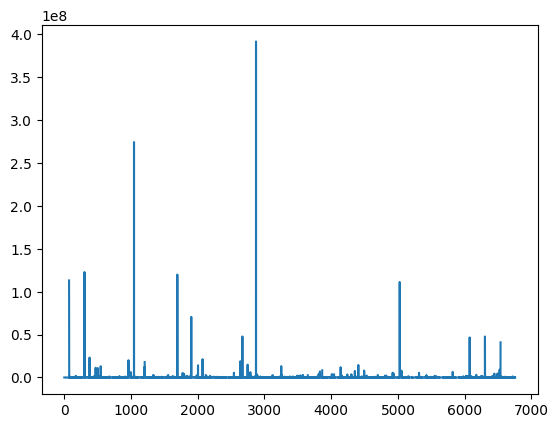

In [ ]:
df['Ecut_PLEC'].plot()

In [ ]:
df[df['Ecut_PLEC'].isna()]

,Source_Name,DataRelease,GLON,GLAT,ROI_num,Extended_Source_Name,Signif_Avg,Pivot_Energy,Flux1000,Unc_Flux1000,...,ASSOC1,ASSOC2,ASSOC_PROB_BAY,ASSOC_PROB_LR,Flags,Class,Flux_Band_Array,HR13,HR45,Ecut_PLEC
70,4FGL J0013.4+0950,2,107.641838,-51.902443,106,,9.273533,4803.589844,2.106924e-10,3.832970e-11,...,1RXS J001328.4+094942,,0.997932,0.959544,0,AGN,"[2.1703737765332853e-11, 5.982182527120017e-10...",-0.593032,-0.704701,NaN
71,4FGL J0013.6+4051,1,115.257797,-21.451033,193,,7.020162,2021.934937,1.540156e-10,2.569247e-11,...,4C +40.01,,0.997100,0.988840,0,AGN,"[1.7050483691605223e-08, 2.289747502715045e-09...",-0.904721,-0.822441,NaN
76,4FGL J0014.2+0854,1,107.618553,-52.851952,106,,5.967213,1091.191772,1.807009e-10,3.372280e-11,...,MS 0011.7+0837,,0.998308,0.937009,16,AGN,"[3.412109039757638e-09, 4.011400989156755e-09,...",-0.940933,-0.999983,NaN
105,4FGL J0022.0+0006,1,107.207039,-61.858170,1506,,9.646608,8737.983398,1.318701e-10,2.800564e-11,...,RX J0022.0+0006,,0.998933,0.940074,0,AGN,"[4.7761741664518326e-14, 1.3613811683868549e-1...",0.973187,-0.411120,NaN
111,4FGL J0023.6-4209,1,321.849915,-73.933472,1363,,4.416572,2685.096436,8.541899e-11,2.095155e-11,...,,,0.720000,0.000000,0,UNASSOC,"[9.975067646883495e-13, 1.9492305547430533e-09...",-0.929950,-1.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6619,4FGL J2326.2+0113,1,83.654495,-55.021851,1744,,14.219699,1428.022827,3.354667e-10,3.364710e-11,...,SDSS J232625.63+011208.6,,0.978909,0.885861,0,AGN,"[9.483776430840862e-09, 3.920564317638764e-09,...",-0.855132,-0.738775,NaN
6620,4FGL J2326.9-0201,1,80.476326,-57.753719,1177,,9.719932,1014.322876,2.402710e-10,3.285745e-11,...,PKS 2324-02,,0.993934,0.992374,0,AGN,"[8.767298692591297e-11, 9.270837431074597e-09,...",-0.957285,-0.265817,NaN
6639,4FGL J2330.3-2948,1,19.600815,-71.997093,67,,8.627215,2238.477783,1.739303e-10,2.578591e-11,...,LEDA 3230048,,NaN,0.000000,0,AGN,"[1.059204048255158e-12, 4.277748988368302e-10,...",-0.592179,-0.495613,NaN
6643,4FGL J2330.6-3726,1,356.661835,-70.119202,1509,,15.202954,1089.930908,2.893586e-10,2.881026e-11,...,PKS 2327-376,,0.998681,0.966392,0,AGN,"[4.2649451678644645e-12, 6.56104726104445e-09,...",-0.939276,-0.616171,NaN


In [ ]:
feature_cols = ['LP_beta', 'LP_SigCurv', 'Frac_Variability', 'Flux1000', 'Unc_Flux1000', 'Variability_Index', 'Ecut_PLEC', 'Signif_Avg',
                'HR13', 'HR45']

Several spectral and temporal features are in multiple orders of magnitude and exhibit highly skewed distributions. To improve numerical stability & enhance the effectiveness of tree based machine learning models, logarithmic transformation is applied to a few selected features.

In [ ]:
log_cols = ['Flux1000', 'Unc_Flux1000', 'Variability_Index', 'Signif_Avg', 'Ecut_PLEC']

for col in log_cols:
    df[f'log10_{col}'] = np.log10(df[col].where(df[col] > 0))

In [ ]:
df['log10_Ecut_PLEC']

,log10_Ecut_PLEC
0,3.675860
1,4.198125
2,3.305306
3,4.852914
4,4.680916
...,...
6752,5.327154
6753,2.550106
6754,2.180881
6755,3.497796


In [ ]:
final_features = ['Source_Name', 'GLAT', 'GLON' , 'LP_beta', 'LP_SigCurv', 'Frac_Variability', 'log10_Flux1000', 'log10_Unc_Flux1000', 'log10_Variability_Index',
                  'log10_Signif_Avg', 'log10_Ecut_PLEC', 'HR13', 'HR45']

After all the feature engineering, the above features are chosen to be used for training the model.

In [ ]:
df_final = df[final_features + ['Class']].copy()

In [ ]:
df_final.head()

,Source_Name,GLAT,GLON,LP_beta,LP_SigCurv,Frac_Variability,log10_Flux1000,log10_Unc_Flux1000,log10_Variability_Index,log10_Signif_Avg,log10_Ecut_PLEC,HR13,HR45,Class
0,4FGL J0000.3-7355,-42.729538,307.708984,0.109999,1.117561,0.000000,-9.829854,-10.662135,1.108396,0.929043,3.675860,0.981334,-0.733034,UNASSOC
1,4FGL J0000.5+0743,-53.029457,101.656479,0.109660,1.194232,0.561723,-9.808520,-10.517509,1.407714,0.754432,4.198125,-0.665284,-0.999999,UNASSOC
2,4FGL J0000.7+2530,-35.959175,108.775070,0.251122,1.689082,0.000000,-10.168825,-10.642345,1.118902,0.622967,3.305306,0.995529,-0.572643,UNASSOC
3,4FGL J0001.2+4741,-14.338059,114.250198,0.049796,0.394362,0.663905,-9.915235,-10.571502,1.461132,0.742244,4.852914,-0.741358,-0.679296,AGN
4,4FGL J0001.2-0747,-67.305008,89.032722,0.037899,1.283201,0.429135,-9.153387,-10.332222,1.713846,1.389117,4.680916,-0.876262,-0.709073,AGN


In [ ]:
df_final['Class'].value_counts()

,count
Class,
AGN,4014
UNASSOC,2423
Pulsar,320


Pulsar: 0

I've mapped
- Pulsar: 1
- AGN: 0
- unassociated data: NaN

It's done for the training purposes.

In [ ]:
df_final['label'] = df_final['Class'].map({
    'AGN': 0,
    'Pulsar': 1,
    'UNASSOC': np.nan
})

In [ ]:
df_final.head()

,Source_Name,GLAT,GLON,LP_beta,LP_SigCurv,Frac_Variability,log10_Flux1000,log10_Unc_Flux1000,log10_Variability_Index,log10_Signif_Avg,log10_Ecut_PLEC,HR13,HR45,Class,label
0,4FGL J0000.3-7355,-42.729538,307.708984,0.109999,1.117561,0.000000,-9.829854,-10.662135,1.108396,0.929043,3.675860,0.981334,-0.733034,UNASSOC,NaN
1,4FGL J0000.5+0743,-53.029457,101.656479,0.109660,1.194232,0.561723,-9.808520,-10.517509,1.407714,0.754432,4.198125,-0.665284,-0.999999,UNASSOC,NaN
2,4FGL J0000.7+2530,-35.959175,108.775070,0.251122,1.689082,0.000000,-10.168825,-10.642345,1.118902,0.622967,3.305306,0.995529,-0.572643,UNASSOC,NaN
3,4FGL J0001.2+4741,-14.338059,114.250198,0.049796,0.394362,0.663905,-9.915235,-10.571502,1.461132,0.742244,4.852914,-0.741358,-0.679296,AGN,0.0
4,4FGL J0001.2-0747,-67.305008,89.032722,0.037899,1.283201,0.429135,-9.153387,-10.332222,1.713846,1.389117,4.680916,-0.876262,-0.709073,AGN,0.0


In [ ]:
df_final[df_final['Class'] == 'Pulsar']

,Source_Name,GLAT,GLON,LP_beta,LP_SigCurv,Frac_Variability,log10_Flux1000,log10_Unc_Flux1000,log10_Variability_Index,log10_Signif_Avg,log10_Ecut_PLEC,HR13,HR45,Class,label
13,4FGL J0002.8+6217,-0.051036,117.320412,0.385295,11.985063,0.040472,-8.594605,-10.014705,1.186970,1.553799,2.715868,-0.768104,-0.960761,Pulsar,1.0
37,4FGL J0007.0+7303,10.461680,119.662628,0.279506,82.887825,0.000000,-7.178112,-9.419105,0.915514,2.603907,2.924014,-0.536048,-0.830925,Pulsar,1.0
110,4FGL J0023.4+0920,-52.896538,111.420189,0.414662,9.551835,0.000000,-8.891685,-10.172951,1.029740,1.494139,2.622422,-0.517393,-0.906250,Pulsar,1.0
139,4FGL J0030.4+0451,-57.612598,113.134041,0.428569,37.115952,0.008049,-7.991647,-9.810484,1.125829,2.146699,2.386460,-0.496363,-0.960277,Pulsar,1.0
155,4FGL J0034.3-0534,-68.073448,111.503700,0.252533,13.308967,0.000000,-8.571970,-10.085713,0.973618,1.822262,2.898701,-0.744987,-0.928917,Pulsar,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6531,4FGL J2302.7+4443,-13.992452,103.397820,0.412627,29.270611,0.000000,-8.164694,-9.908936,0.778881,2.039603,3.120544,-0.373483,-0.924723,Pulsar,1.0
6550,4FGL J2310.0-0555,-57.900059,69.693352,0.529815,9.835068,0.086722,-8.977837,-10.215825,1.135315,1.459482,2.533451,-0.022279,-0.936858,Pulsar,1.0
6570,4FGL J2317.3+1433,-42.463829,91.353004,0.549921,2.950717,0.288305,-9.784999,-10.456313,1.260788,0.683939,2.247490,0.994781,-0.158257,Pulsar,1.0
6651,4FGL J2333.1-5527,-58.323433,324.135620,0.272427,5.725081,0.000000,-9.221370,-10.403797,0.786865,1.401349,2.981845,-0.608411,-0.851468,Pulsar,1.0


In [ ]:
df_final['label'].value_counts()

,count
label,
0.0,4014
1.0,320


In [ ]:
df_final['label'].dtype

dtype('float64')

In [ ]:
df_final.isnull().sum().sort_values(ascending=False)

,0
label,2423
log10_Ecut_PLEC,417
LP_beta,1
GLON,0
LP_SigCurv,0
GLAT,0
Source_Name,0
log10_Flux1000,0
Frac_Variability,0
log10_Variability_Index,0


In [ ]:
df_final.isnull().mean().sort_values(ascending=False)

,0
label,0.358591
log10_Ecut_PLEC,0.061714
LP_beta,0.000148
GLON,0.000000
LP_SigCurv,0.000000
GLAT,0.000000
Source_Name,0.000000
log10_Flux1000,0.000000
Frac_Variability,0.000000
log10_Variability_Index,0.000000


Here, I am splitting the data based on labelled & unlabelled data.

In [ ]:
df_train = df_final[df_final['label'].notna()].copy()
df_unassoc = df_final[df_final['label'].isna()].copy()

Since the problem is binary classification, but the label is stored as float value, I need to convert it to the int type.

In [ ]:
df_train.drop(columns= ['Source_Name', 'GLAT', 'GLON'], axis= 1, inplace= True)

In [ ]:
df_train.head()

,LP_beta,LP_SigCurv,Frac_Variability,log10_Flux1000,log10_Unc_Flux1000,log10_Variability_Index,log10_Signif_Avg,log10_Ecut_PLEC,HR13,HR45,Class,label
3,0.049796,0.394362,0.663905,-9.915235,-10.571502,1.461132,0.742244,4.852914,-0.741358,-0.679296,AGN,0.0
4,0.037899,1.283201,0.429135,-9.153387,-10.332222,1.713846,1.389117,4.680916,-0.876262,-0.709073,AGN,0.0
5,-0.010222,0.000000,0.000000,-9.929117,-10.566055,0.971934,0.720296,4.968191,-0.938177,-0.284222,AGN,0.0
6,0.148902,7.548741,1.088172,-8.926106,-10.263975,3.269887,1.666760,2.917832,-0.948058,-0.999594,AGN,0.0
8,0.120901,2.630329,0.368921,-9.504904,-10.500049,1.408400,1.254850,4.232201,-0.529169,-0.503655,AGN,0.0


In [ ]:
df_train['label'] = df_train['label'].astype('int64')

In [ ]:
df_train['label'].dtype

dtype('int64')

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4334 entries, 3 to 6756
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   LP_beta                  4333 non-null   float64
 1   LP_SigCurv               4334 non-null   float64
 2   Frac_Variability         4334 non-null   float64
 3   log10_Flux1000           4334 non-null   float64
 4   log10_Unc_Flux1000       4334 non-null   float64
 5   log10_Variability_Index  4334 non-null   float64
 6   log10_Signif_Avg         4334 non-null   float64
 7   log10_Ecut_PLEC          4086 non-null   float64
 8   HR13                     4334 non-null   float64
 9   HR45                     4334 non-null   float64
 10  Class                    4334 non-null   object 
 11  label                    4334 non-null   int64  
dtypes: float64(10), int64(1), object(1)
memory usage: 440.2+ KB


In [ ]:
X = df_train.drop(['Class', 'label'], axis= 1).copy()
y = df_train['label'].copy()

In [ ]:
y.value_counts()

,count
label,
0,4014
1,320


In [ ]:
X.isna().sum()

,0
LP_beta,1
LP_SigCurv,0
Frac_Variability,0
log10_Flux1000,0
log10_Unc_Flux1000,0
log10_Variability_Index,0
log10_Signif_Avg,0
log10_Ecut_PLEC,248
HR13,0
HR45,0


The dataset has very less missing value compared to more than 5k data points. So, i used median method to compute the missing values.

In [ ]:
X = X.fillna(X.median())

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.25, stratify= y, random_state= 42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score, f1_score

I divided datased into training and testing subsets using a 75%–25% split. I applied Stratified sampling to preserve the original class imbalance between AGN and Pulsars in both subsets.

In [ ]:
rf_base = RandomForestClassifier(n_estimators= 200, max_depth= 7, random_state=42, n_jobs=-1)

In [ ]:
list(X.columns)

['LP_beta',
 'LP_SigCurv',
 'Frac_Variability',
 'log10_Flux1000',
 'log10_Unc_Flux1000',
 'log10_Variability_Index',
 'log10_Signif_Avg',
 'log10_Ecut_PLEC',
 'HR13',
 'HR45']

In [ ]:
rfe_results = []
current_features = list(X.columns)

Recursive Feature Elimination using Random Forest

Recursive Feature Elimination (RFE) is implemented using a backward selection strategy to identify the most informative subset of input features. Starting with the full feature set, a Random Forest classifier is trained and evaluated, and the least important feature is removed at each iteration.

At every step:
- I am training the Random Forest model on the current feature subset.
- Predictions are made on the held-out test set.
- I am computing balanced accuracy and F1-score to assess classification performance, which are appropriate metrics for imbalanced datasets.
- Feature importance scores provided by the Random Forest are used to identify the least contributing feature.

In [ ]:
while len(current_features) >= 1:
    # Training RF
    rf = rf_base
    rf.fit(X_train[current_features], y_train)
    # Predicting on test set
    y_pred = rf.predict(X_test[current_features])

    # Metrics used in the paper
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    rfe_results.append({
        'n_features': len(current_features),
        'features': current_features.copy(),
        'balanced_accuracy': bal_acc,
        'f1_score': f1
    })

    # Identifing least important feature
    importances = rf.feature_importances_
    least_idx = np.argmin(importances)
    least_feature = current_features[least_idx]

    # Remove it
    current_features.remove(least_feature)

In [ ]:
rfe_df = pd.DataFrame(rfe_results)
rfe_df = rfe_df.sort_values('n_features', ascending=False).reset_index(drop=True)

In [ ]:
rfe_df

,n_features,features,balanced_accuracy,f1_score
0,10,"[LP_beta, LP_SigCurv, Frac_Variability, log10_...",0.903262,0.860927
1,9,"[LP_beta, LP_SigCurv, Frac_Variability, log10_...",0.902764,0.855263
2,8,"[LP_beta, LP_SigCurv, Frac_Variability, log10_...",0.897012,0.853333
3,7,"[LP_beta, LP_SigCurv, log10_Flux1000, log10_Un...",0.897012,0.853333
4,6,"[LP_beta, LP_SigCurv, log10_Flux1000, log10_Un...",0.909512,0.868421
5,5,"[LP_beta, LP_SigCurv, log10_Flux1000, log10_Un...",0.891260,0.851351
6,4,"[LP_beta, LP_SigCurv, log10_Unc_Flux1000, log1...",0.884512,0.837838
7,3,"[LP_beta, LP_SigCurv, log10_Unc_Flux1000]",0.863272,0.786667
8,2,"[LP_beta, LP_SigCurv]",0.853262,0.797203
9,1,[LP_SigCurv],0.685284,0.484375


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

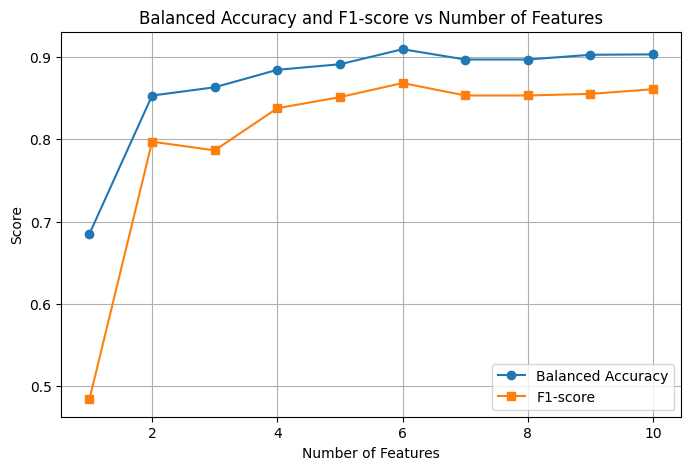

In [ ]:
plot_df = rfe_df.sort_values('n_features')

plt.figure(figsize=(8, 5))

plt.plot(
    plot_df['n_features'],
    plot_df['balanced_accuracy'],
    marker='o',
    label='Balanced Accuracy'
)

plt.plot(
    plot_df['n_features'],
    plot_df['f1_score'],
    marker='s',
    label='F1-score'
)

plt.xlabel('Number of Features')
plt.ylabel('Score')
plt.title('Balanced Accuracy and F1-score vs Number of Features')
plt.legend()
plt.grid(True)

plt.show()


The figure above shows the variation of balanced accuracy and F1-score as a function of the number of input features retained during recursive feature elimination.

Both metrics are increasing rapidly when moving from a very small number of features to a moderate feature set, indicating that multiple spectral and temporal properties are required to effectively distinguish pulsars from AGN. When number of feature is 6, both balanced accuracy & f1 score is maximum. After that, it got saturated. In the paper, the best no. of feature is found to 8, but i found 6.

In [ ]:
rfe_df.loc[rfe_df['n_features'] == 8]

,n_features,features,balanced_accuracy,f1_score
2,8,"[LP_beta, LP_SigCurv, Frac_Variability, log10_...",0.897012,0.853333


In [ ]:
best_8_features = rfe_df.loc[rfe_df['n_features'] == 8, 'features'].values[0]

best_8_features

['LP_beta',
 'LP_SigCurv',
 'Frac_Variability',
 'log10_Flux1000',
 'log10_Unc_Flux1000',
 'log10_Variability_Index',
 'log10_Signif_Avg',
 'log10_Ecut_PLEC']

So, I'm going with best 8 features, since there is not that much of difference between balanced accuracy & F1 score of best 6 & 8 features. Also, these scores has saturated after 6.

In [ ]:
X_final = X[best_8_features].copy()

In [ ]:
df_final['Class'].value_counts()

,count
Class,
AGN,4014
UNASSOC,2423
Pulsar,320


In [ ]:
df_plot = df_final.copy()
df_psr = df_plot[df_plot['Class'] == 'Pulsar']
df_agn = df_plot[df_plot['Class'] == 'AGN']
df_un  = df_plot[df_plot['Class'] == 'UNASSOC']

To understand the discriminative power of the selected features, I am looking at the distribution of each of the eight best features for three source populations:
- Pulsars
- Active Galactic Nuclei (AGN)
- Unassociated sources

For this purpose, I am using KS test. Higher KS value indicates stronger discriminative power of that feature.

In [ ]:
from scipy.stats import ks_2samp

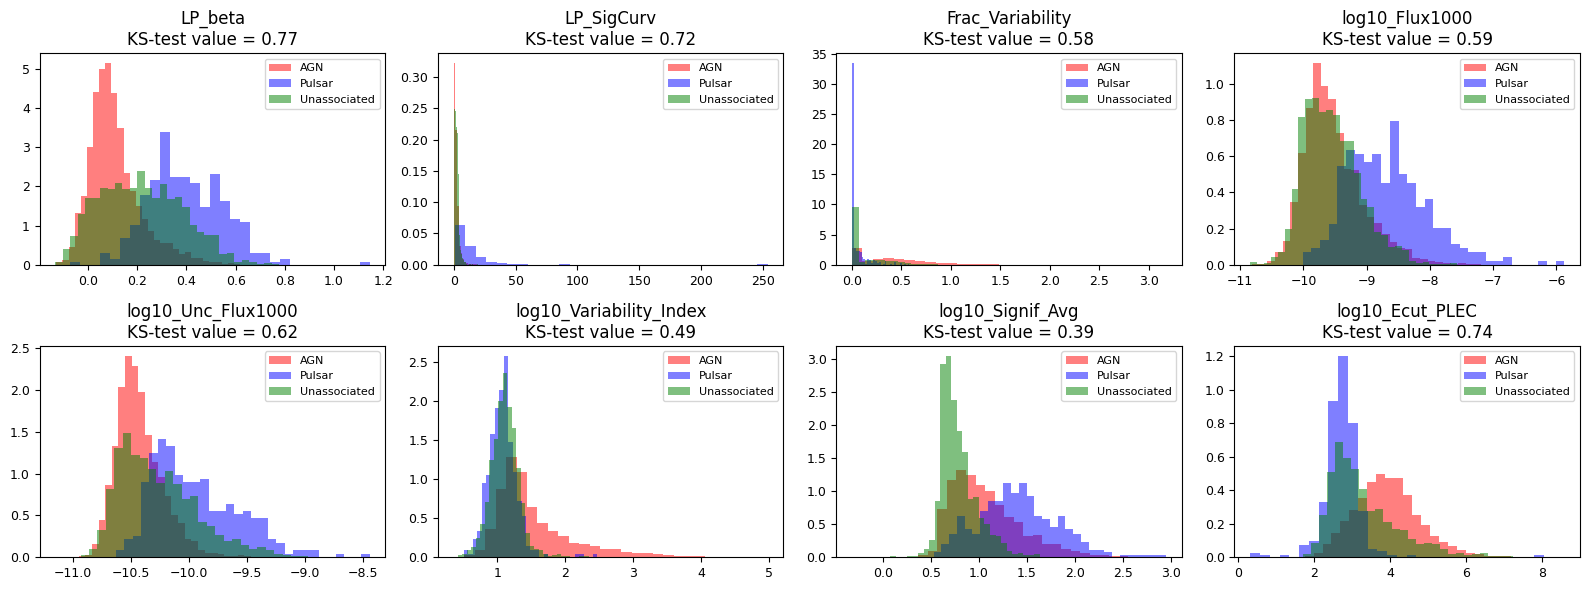

In [ ]:
n_feat = len(best_8_features)
ncols = 4
nrows = int(np.ceil(n_feat / ncols))

plt.figure(figsize=(4*ncols, 3*nrows))

for i, feat in enumerate(best_8_features, 1):
    plt.subplot(nrows, ncols, i)
    psr_vals = df_psr[feat].dropna()
    agn_vals = df_agn[feat].dropna()
    # KS test (Pulsar vs AGN)
    ks_stat, ks_p = ks_2samp(psr_vals, agn_vals)

    plt.hist(agn_vals, bins=30, density=True, alpha=0.5, color='red', label='AGN')
    plt.hist(psr_vals, bins=30, density=True, alpha=0.5, color='blue', label='Pulsar')
    plt.hist(df_un[feat].dropna(), bins=30, density=True, alpha=0.5, color='green', label='Unassociated')

    plt.title(f"{feat}\nKS-test value = {ks_stat:.2f}")
    plt.tick_params(axis='both', labelsize=9)
    plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

From the above plot, I can see the KS values:
- LP_beta ( around 0.77) and log10_Ecut_PLEC (around 0.74) show strong separation between Pulsars and AGN.
- LP_SigCurv (around 0.72) also shows strong discriminative capability.
- Variability-related features (e.g., Frac_Variability, log10_Variability_Index) show moderate separation.
- log10_Signif_Avg shows relatively weaker separation.

It confirms that Spectral curvature and cutoff parameters are the most powerful discriminators.

In [ ]:
best_8_features

['LP_beta',
 'LP_SigCurv',
 'Frac_Variability',
 'log10_Flux1000',
 'log10_Unc_Flux1000',
 'log10_Variability_Index',
 'log10_Signif_Avg',
 'log10_Ecut_PLEC']

After selecting the best 8 features using Recursive Feature Elimination (RFE), now I will train Random Forest & XGBoost model using these best features.


I will use the name dataset A for the original dataset, which is very imbalanced. Here, AGNs are heavily dominating in comparison to Pulsars.

In [ ]:
# Dataset A
X_A = X[best_8_features].copy()
y_A = y.copy()

In [ ]:
y_A.value_counts()

,count
label,
0,4014
1,320


In [ ]:
y_A

,label
3,0
4,0
5,0
6,0
8,0
...,...
6750,0
6752,0
6754,0
6755,0


I am using stratify here to maintain class proportions during splitting.

In [ ]:
X_A_train, X_A_test, y_A_train, y_A_test = train_test_split(X_A, y_A, test_size= 0.25, stratify= y_A, random_state= 42)

In [ ]:
from imblearn.over_sampling import SMOTE

Since Pulsars are a minority class, if I train the model on the dataset A, there is high chance of bias towards AGNs.

To handle this, Synthetic Minority Over-sampling Technique (SMOTE) is applied only to the training set.
Here the important point is SMOTE is applied after train-test split, making the test dataset untouched.

In [ ]:
smote = SMOTE(random_state=42)
X_B_train, y_B_train = smote.fit_resample(X_A_train.to_numpy(), y_A_train.to_numpy())

In [ ]:
y_B_train

array([0, 0, 0, ..., 1, 1, 1])

In [ ]:
len(y_B_train)

6020

In [ ]:
pd.Series(y_B_train).value_counts()

,count
0,3010
1,3010


The above table shows that the class has been balanced.

I will refer to this balanced dataset as dataset B.

How SMOTE Works:

Instead of simply duplicating minority samples, SMOTE generates synthetic new samples.

For each minority class point:
- Identify its k nearest minority neighbors.
- Randomly select one neighbor.
- Create a synthetic sample along the line segment joining the two points.

It creates new samples within the feature space of the minority class, improving class balance without exact duplication

Here, the important point is test dataset is same for both imbalanced & balanced dataset (dataset- A & B).

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

Now, I will use random forest & XGBoost to train on dataset A & B separately. I will use 5-fold cross-validation for hyperparameter tuning.


Random forest training on dataset A

In [ ]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

rf_param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [6, 7, 8],
    'min_samples_split': [2, 5]
}

rf_grid_A = GridSearchCV(
    rf,
    rf_param_grid,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1
)

rf_grid_A.fit(X_A_train, y_A_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [6, 7, 8], 'min_samples_split': [2, 5],
                         'n_estimators': [200, 300]},
             scoring='balanced_accuracy')

In [ ]:
rf_grid_A.best_params_

{'max_depth': 8, 'min_samples_split': 2, 'n_estimators': 200}

Random forest training on dataset B

In [ ]:
rf_grid_B = GridSearchCV(
    rf,
    rf_param_grid,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1
)

rf_grid_B.fit(X_B_train, y_B_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [6, 7, 8], 'min_samples_split': [2, 5],
                         'n_estimators': [200, 300]},
             scoring='balanced_accuracy')

In [ ]:
rf_grid_B.best_params_

{'max_depth': 8, 'min_samples_split': 2, 'n_estimators': 200}

In [ ]:
from xgboost import XGBClassifier

In [ ]:
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

xgb_param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [3, 4],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

XGBoost on Dataset A

In [ ]:
xgb_grid_A = GridSearchCV(
    xgb,
    xgb_param_grid,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1
)

xgb_grid_A.fit(X_A_train, y_A_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:25:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [3, 4],
                         'n_estimators': [200, 300], 'subsample': [0.8, 1.0]},
             scoring='balanced_accuracy')

In [ ]:
xgb_grid_A.best_params_

{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1.0}

XGBoost on dataset B

In [ ]:
xgb_grid_B = GridSearchCV(
    xgb,
    xgb_param_grid,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1
)

xgb_grid_B.fit(X_B_train, y_B_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:26:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [3, 4],
                         'n_estimators': [200, 300], 'subsample': [0.8, 1.0]},
             scoring='balanced_accuracy')

In [ ]:
xgb_grid_B.best_params_

{'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}

In [ ]:
from sklearn.metrics import balanced_accuracy_score, precision_score, recall_score, f1_score

In [ ]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    return {
        'Balanced Accuracy': balanced_accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred)
    }

After hyperparameter tuning using GridSearchCV, the best estimators for each classifier and dataset were extracted:
RF (Dataset A), RF (Dataset B), XGB (Dataset A), XGB (Dataset B).

All models are evaluated on the same test set to ensure a fair comparison betwwen imbalanced (dataset A) & balanced dataset (dataset B).

In [ ]:
rf_A_best  = rf_grid_A.best_estimator_
rf_B_best  = rf_grid_B.best_estimator_

xgb_A_best = xgb_grid_A.best_estimator_
xgb_B_best = xgb_grid_B.best_estimator_

In [ ]:
results = []

In [ ]:
results.append({
    'Model': 'RF (Dataset A)',
    **evaluate_model(rf_A_best, X_A_test, y_A_test)
})

In [ ]:
results.append({
    'Model': 'RF (Dataset B)',
    **evaluate_model(rf_B_best, X_A_test, y_A_test)
})

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [ ]:
results.append({
    'Model': 'XGB (Dataset A)',
    **evaluate_model(xgb_A_best, X_A_test, y_A_test)
})

In [ ]:
results.append({
    'Model': 'XGB (Dataset B)',
    **evaluate_model(xgb_B_best, X_A_test, y_A_test)
})

In [ ]:
results_df = pd.DataFrame(results)

In [ ]:
results_df

,Model,Balanced Accuracy,Precision,Recall,F1-score
0,RF (Dataset A),0.902764,0.902778,0.8125,0.855263
1,RF (Dataset B),0.953810,0.714286,0.9375,0.810811
2,XGB (Dataset A),0.902764,0.902778,0.8125,0.855263
3,XGB (Dataset B),0.949054,0.732673,0.9250,0.817680


 Here I can see that training with SMOTE significantly increases:
- Recall (Pulsar recovery)
- Balanced Accuracy

It confirms that balancing the dataset method is improving sensitivity to the minority class, i.e., Pulsar class.

Precision–Recall Trade-off:

Balanced training leads to:
- Higher recall
- Lower precision

---
- On Dataset A: RF and XGB perform nearly identically.
- On Dataset B: both improve recall, but XGB maintains slightly better balance between precision and recall.

ROC Curve analysis

To evaluate the discriminative performance of the trained classifiers across all possible probability thresholds, ROC curves were computed for Random forest (dataset A & B) & XGBoost (dataset A & B).

ROC curve plots True Positive Rate against False Positive rate. for varying thresholds.

The Area Under the ROC Curve (AUC) measures overall separability:
- AUC = 1: perfect classification
- AUC = 0.5: random guessing

Higher AUC indicates better class discrimination independent of threshold choice.



In [ ]:
from sklearn.metrics import roc_curve, auc

In [ ]:
rf_A_prob  = rf_A_best.predict_proba(X_A_test)[:, 1]
rf_B_prob  = rf_B_best.predict_proba(X_A_test)[:, 1]

xgb_A_prob = xgb_A_best.predict_proba(X_A_test)[:, 1]
xgb_B_prob = xgb_B_best.predict_proba(X_A_test)[:, 1]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [ ]:
fpr_rf_A, tpr_rf_A, _ = roc_curve(y_A_test, rf_A_prob)
fpr_rf_B, tpr_rf_B, _ = roc_curve(y_A_test, rf_B_prob)

fpr_xgb_A, tpr_xgb_A, _ = roc_curve(y_A_test, xgb_A_prob)
fpr_xgb_B, tpr_xgb_B, _ = roc_curve(y_A_test, xgb_B_prob)

auc_rf_A  = auc(fpr_rf_A,  tpr_rf_A)
auc_rf_B  = auc(fpr_rf_B,  tpr_rf_B)
auc_xgb_A = auc(fpr_xgb_A, tpr_xgb_A)
auc_xgb_B = auc(fpr_xgb_B, tpr_xgb_B)

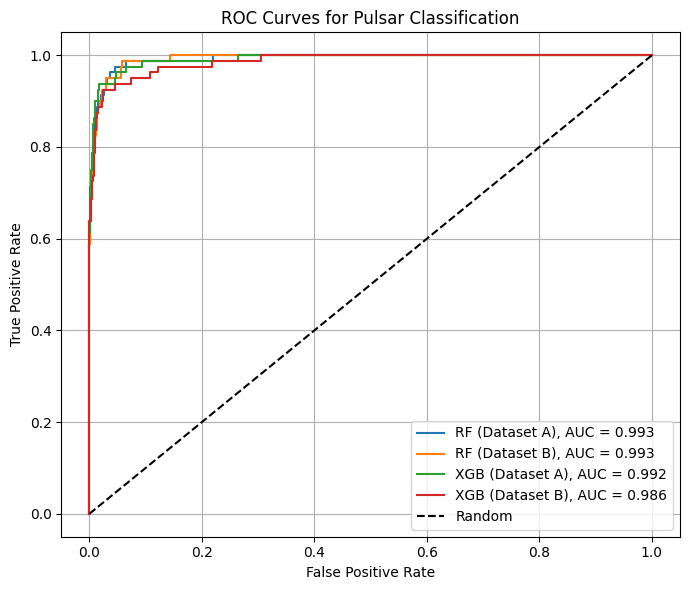

In [ ]:
plt.figure(figsize=(7, 6))

plt.plot(fpr_rf_A,  tpr_rf_A,  label=f'RF (Dataset A), AUC = {auc_rf_A:.3f}')
plt.plot(fpr_rf_B,  tpr_rf_B,  label=f'RF (Dataset B), AUC = {auc_rf_B:.3f}')
plt.plot(fpr_xgb_A, tpr_xgb_A, label=f'XGB (Dataset A), AUC = {auc_xgb_A:.3f}')
plt.plot(fpr_xgb_B, tpr_xgb_B, label=f'XGB (Dataset B), AUC = {auc_xgb_B:.3f}')

# Random classifier reference
plt.plot([0, 1], [0, 1], 'k--', label='Random')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Pulsar Classification')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In all models, AUC > 0.98: It means that pulsars and AGN are strongly separable in the selected feature space.

Feature Importance

In [ ]:
# RF Dataset A feature importance
rf_A_importance = pd.DataFrame({
    'Feature': X_A_train.columns,
    'Importance': rf_A_best.feature_importances_
}).sort_values('Importance', ascending=False)

rf_A_importance['Relative Importance'] = (
    rf_A_importance['Importance'] / rf_A_importance['Importance'].sum()
)

rf_A_importance

,Feature,Importance,Relative Importance
1,LP_SigCurv,0.205823,0.205823
0,LP_beta,0.195067,0.195067
4,log10_Unc_Flux1000,0.136581,0.136581
3,log10_Flux1000,0.110097,0.110097
7,log10_Ecut_PLEC,0.106473,0.106473
6,log10_Signif_Avg,0.084727,0.084727
2,Frac_Variability,0.083821,0.083821
5,log10_Variability_Index,0.077412,0.077412


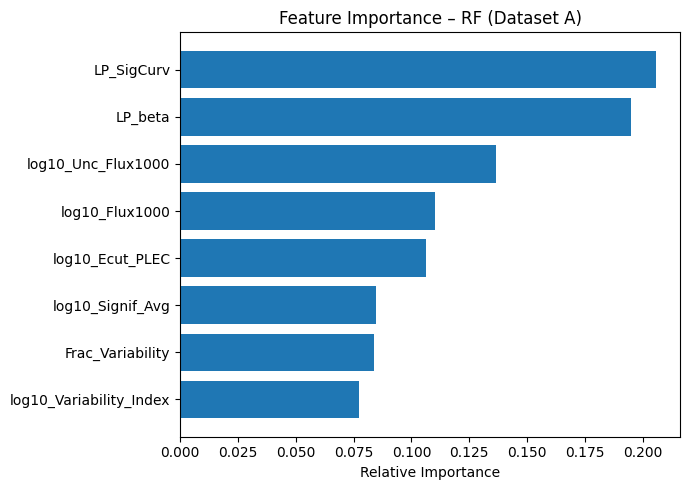

In [ ]:
plt.figure(figsize=(7, 5))

plt.barh(rf_A_importance['Feature'],
         rf_A_importance['Relative Importance'])

plt.gca().invert_yaxis()
plt.xlabel('Relative Importance')
plt.title('Feature Importance – RF (Dataset A)')
plt.tight_layout()
plt.show()

In [ ]:
booster_A = xgb_A_best.get_booster()
importance_dict_A = booster_A.get_score(importance_type='gain')

feature_names = X_A_train.columns.tolist()

xgb_A_importance = (
    pd.DataFrame([
        {
            'Feature': key,
            'Gain': val
        }
        for key, val in importance_dict_A.items()
    ])
    .sort_values('Gain', ascending=False)
    .reset_index(drop=True)
)

xgb_A_importance['Relative Importance'] = (
    xgb_A_importance['Gain'] / xgb_A_importance['Gain'].sum()
)

xgb_A_importance

,Feature,Gain,Relative Importance
0,LP_beta,29.822481,0.384719
1,log10_Flux1000,13.327336,0.171927
2,LP_SigCurv,8.410343,0.108496
3,log10_Ecut_PLEC,7.496133,0.096702
4,log10_Unc_Flux1000,6.559631,0.084621
5,Frac_Variability,5.839899,0.075337
6,log10_Signif_Avg,3.666320,0.047297
7,log10_Variability_Index,2.395331,0.030901


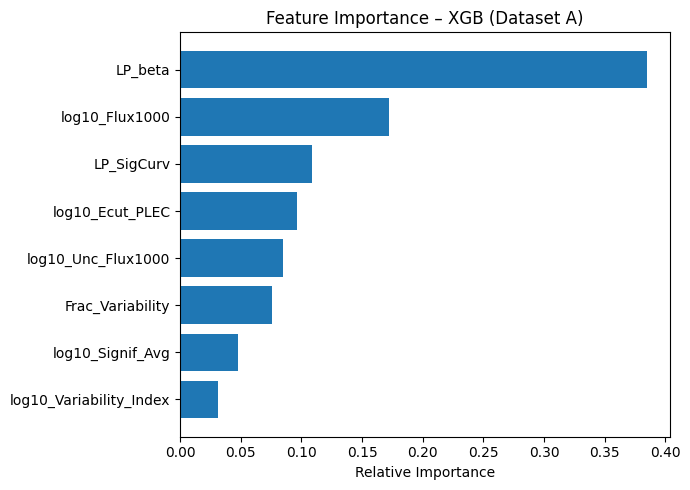

In [ ]:
plt.figure(figsize=(7, 5))

plt.barh(xgb_A_importance['Feature'],
         xgb_A_importance['Relative Importance'])

plt.gca().invert_yaxis()
plt.xlabel('Relative Importance')
plt.title('Feature Importance – XGB (Dataset A)')
plt.tight_layout()
plt.show()

In [ ]:
rf_B_importance = pd.DataFrame({
    'Feature': X_A_train.columns,
    'Importance': rf_B_best.feature_importances_
}).sort_values('Importance', ascending=False)

rf_B_importance['Relative Importance'] = (
    rf_B_importance['Importance'] / rf_B_importance['Importance'].sum()
)

rf_B_importance

,Feature,Importance,Relative Importance
0,LP_beta,0.231843,0.231843
7,log10_Ecut_PLEC,0.209286,0.209286
1,LP_SigCurv,0.156426,0.156426
4,log10_Unc_Flux1000,0.119594,0.119594
2,Frac_Variability,0.096714,0.096714
3,log10_Flux1000,0.089259,0.089259
5,log10_Variability_Index,0.069580,0.069580
6,log10_Signif_Avg,0.027298,0.027298


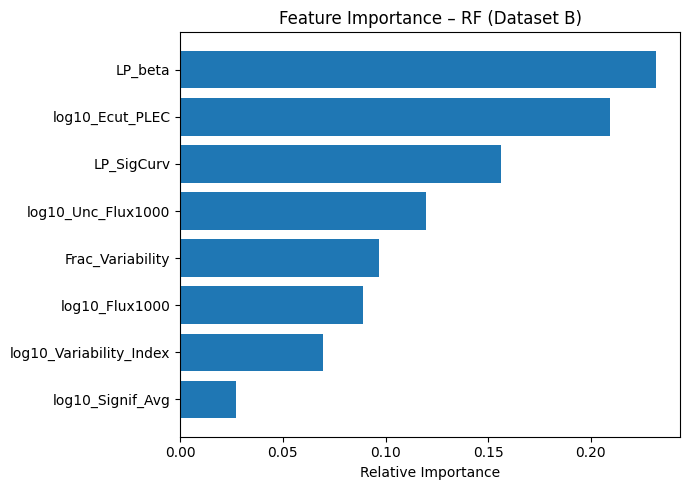

In [ ]:
plt.figure(figsize=(7, 5))

plt.barh(rf_B_importance['Feature'],
         rf_B_importance['Relative Importance'])

plt.gca().invert_yaxis()
plt.xlabel('Relative Importance')
plt.title('Feature Importance – RF (Dataset B)')
plt.tight_layout()
plt.show()

In [ ]:
booster_B = xgb_B_best.get_booster()
importance_dict_B = booster_B.get_score(importance_type='gain')

xgb_B_importance = (
    pd.DataFrame([
        {
            'Feature': feature_names[int(k[1:])],
            'Gain': v
        }
        for k, v in importance_dict_B.items()
    ])
    .sort_values('Gain', ascending=False)
    .reset_index(drop=True)
)

xgb_B_importance['Relative Importance'] = (
    xgb_B_importance['Gain'] / xgb_B_importance['Gain'].sum()
)

xgb_B_importance

,Feature,Gain,Relative Importance
0,LP_beta,51.903469,0.522587
1,log10_Flux1000,13.230083,0.133206
2,log10_Ecut_PLEC,8.183107,0.082391
3,log10_Unc_Flux1000,7.774921,0.078281
4,Frac_Variability,7.090002,0.071385
5,log10_Variability_Index,4.902418,0.049360
6,LP_SigCurv,3.832630,0.038589
7,log10_Signif_Avg,2.403686,0.024201


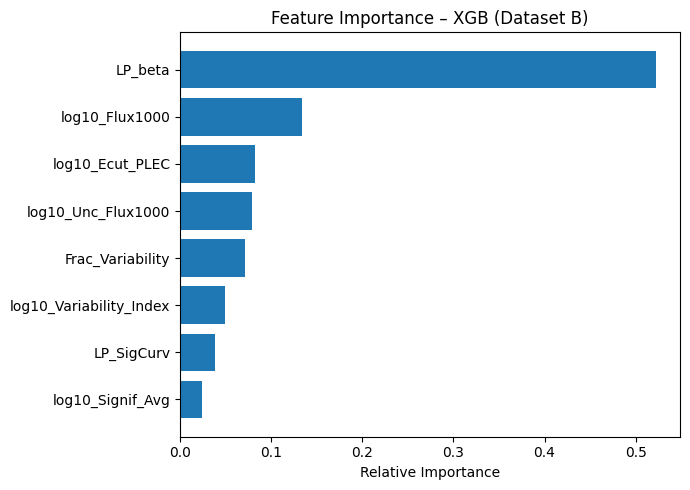

In [ ]:
plt.figure(figsize=(7, 5))

plt.barh(xgb_B_importance['Feature'],
         xgb_B_importance['Relative Importance'])

plt.gca().invert_yaxis()
plt.xlabel('Relative Importance')
plt.title('Feature Importance – XGB (Dataset B)')
plt.tight_layout()
plt.show()

Identification of Pulsars from unknown sources

In [ ]:
df_unassoc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2423 entries, 0 to 6753
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Source_Name              2423 non-null   object 
 1   GLAT                     2423 non-null   float64
 2   GLON                     2423 non-null   float64
 3   LP_beta                  2423 non-null   float64
 4   LP_SigCurv               2423 non-null   float64
 5   Frac_Variability         2423 non-null   float64
 6   log10_Flux1000           2423 non-null   float64
 7   log10_Unc_Flux1000       2423 non-null   float64
 8   log10_Variability_Index  2423 non-null   float64
 9   log10_Signif_Avg         2423 non-null   float64
 10  log10_Ecut_PLEC          2254 non-null   float64
 11  HR13                     2423 non-null   float64
 12  HR45                     2423 non-null   float64
 13  Class                    2423 non-null   object 
 14  label                    0 no

In [ ]:
best_8_features

['LP_beta',
 'LP_SigCurv',
 'Frac_Variability',
 'log10_Flux1000',
 'log10_Unc_Flux1000',
 'log10_Variability_Index',
 'log10_Signif_Avg',
 'log10_Ecut_PLEC']

In [ ]:
selected_features = best_8_features

Among the selected features, log10_Ecut_PLEC has missing values in unassociated sources.

During training, missing values were handled using median imputation computed from the training data.

To maintain consistency and avoid data leakage, the training medians are reused

It ensures that the unassociated sources undergo the same preprocessing as the training data

In [ ]:
train_medians = X_A_train.median()

In [ ]:
X_unassoc = df_unassoc[selected_features].copy()

In [ ]:
X_unassoc = X_unassoc.fillna(train_medians)

In [ ]:
X_unassoc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2423 entries, 0 to 6753
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   LP_beta                  2423 non-null   float64
 1   LP_SigCurv               2423 non-null   float64
 2   Frac_Variability         2423 non-null   float64
 3   log10_Flux1000           2423 non-null   float64
 4   log10_Unc_Flux1000       2423 non-null   float64
 5   log10_Variability_Index  2423 non-null   float64
 6   log10_Signif_Avg         2423 non-null   float64
 7   log10_Ecut_PLEC          2423 non-null   float64
dtypes: float64(8)
memory usage: 170.4 KB


After training and validating the RF and XGB classifiers on known data, the models are applied to the 2423 unassociated sources from the catalog.

For each model, the predicted probability of belonging to the Pulsar class (class 1) is computed below.

In [ ]:
rf_A_prob  = rf_A_best.predict_proba(X_unassoc)[:, 1]
xgb_A_prob = xgb_A_best.predict_proba(X_unassoc)[:, 1]

rf_B_prob  = rf_B_best.predict_proba(X_unassoc)[:, 1]
xgb_B_prob = xgb_B_best.predict_proba(X_unassoc)[:, 1]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Classification threshold
---
- Pulsar Candidates
    - Highly Likely Pulsar: P (Probability) > 0.95
    - Likely Pulsar: P > 0.75
- AGN Candidates
    - Highly Likely AGN: P < 0.05
    - Likely AGN: P < 0.25
- Ambiguous Sources
    - 0.25 ≤ P ≤ 0.75

In [ ]:
def classify_probabilities(prob_array):
    return {
        'Highly Likely Pulsar (>95%)': (prob_array > 0.95).sum(),
        'Likely Pulsar (>75%)': (prob_array > 0.75).sum(),
        'Highly Likely AGN (<5%)': (prob_array < 0.05).sum(),
        'Likely AGN (<25%)': (prob_array < 0.25).sum(),
        'Ambiguous (25%–75%)': ((prob_array >= 0.25) & (prob_array <= 0.75)).sum()
    }

In [ ]:
results_unassoc = []

models_probs = {
    'RF (Dataset A)': rf_A_prob,
    'XGB (Dataset A)': xgb_A_prob,
    'RF (Dataset B)': rf_B_prob,
    'XGB (Dataset B)': xgb_B_prob
}

for model_name, probs in models_probs.items():

    counts = classify_probabilities(probs)

    results_unassoc.append({
        'Model': model_name,
        **counts
    })

In [ ]:
results_unassoc_df = pd.DataFrame(results_unassoc)
results_unassoc_df

,Model,Highly Likely Pulsar (>95%),Likely Pulsar (>75%),Highly Likely AGN (<5%),Likely AGN (<25%),Ambiguous (25%–75%)
0,RF (Dataset A),33,111,1170,1722,590
1,XGB (Dataset A),56,178,1352,1785,460
2,RF (Dataset B),104,546,851,1225,652
3,XGB (Dataset B),335,603,1266,1474,346


Training with SMOTE has significantly increased Pulsar detection:
- RF: 111 --> 546 likely pulsars
- XGB: 178 --> 603 likely pulsars
- Highly likely pulsars increase dramatically, especially for XGB.

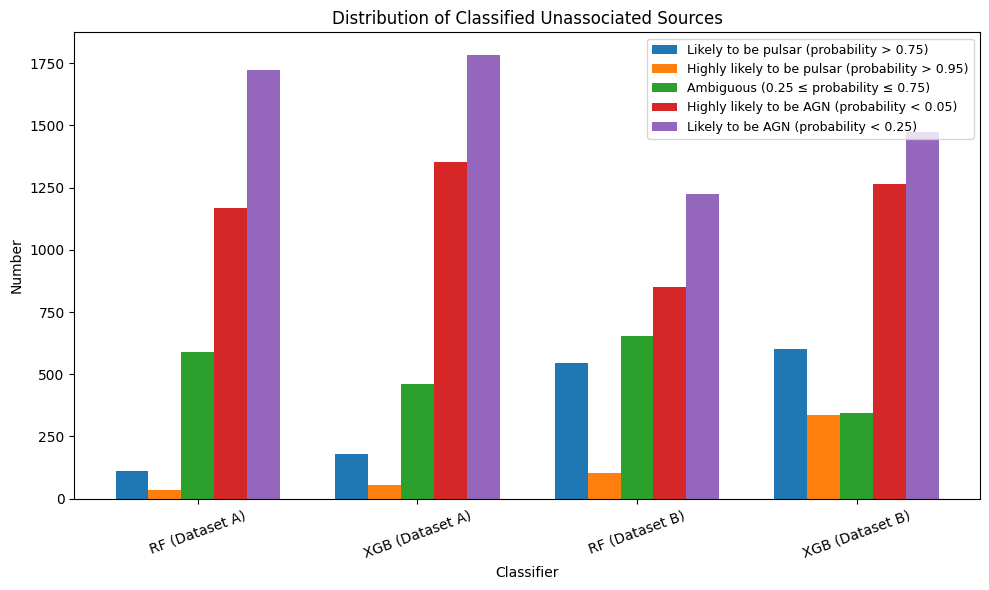

In [ ]:
models = results_unassoc_df['Model']

likely_p = results_unassoc_df['Likely Pulsar (>75%)']
high_p = results_unassoc_df['Highly Likely Pulsar (>95%)']
ambiguous = results_unassoc_df['Ambiguous (25%–75%)']
high_agn = results_unassoc_df['Highly Likely AGN (<5%)']
likely_agn = results_unassoc_df['Likely AGN (<25%)']

x = np.arange(len(models))
width = 0.15

plt.figure(figsize=(10, 6))

plt.bar(x - 2*width, likely_p, width,
        label='Likely to be pulsar (probability > 0.75)')

plt.bar(x - width, high_p, width,
        label='Highly likely to be pulsar (probability > 0.95)')

plt.bar(x, ambiguous, width,
        label='Ambiguous (0.25 ≤ probability ≤ 0.75)')

plt.bar(x + width, high_agn, width,
        label='Highly likely to be AGN (probability < 0.05)')

plt.bar(x + 2*width, likely_agn, width,
        label='Likely to be AGN (probability < 0.25)')

plt.xticks(x, models, rotation=20)
plt.ylabel('Number')
plt.xlabel('Classifier')
plt.title('Distribution of Classified Unassociated Sources')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


- XGB identifies more highly likely Pulsar candidates.
- RF (SMOTE) (i.e., dataset - B) increases ambiguous population.
- XGB (SMOTE) (i.e., dataset B) reduces ambiguous sources compared to RF.

Preparing Data for Comparison with the Author's Result

In [ ]:
df_author = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/1-s2.0-S0927650525001082-mmc1.csv', skiprows= 5)
df_author.head()

,'Unassociated Source_Name','GLAT (deg)','GLON (deg)','RF','XGB','RF-SMOTE','XGB-SMOTE'
0,'4FGL J0000.3-7355 ',-42.729538,307.70898,0.0030,0.0024,0.0410,0.0001
1,'4FGL J0000.5+0743 ',-53.029457,101.65648,0.0009,0.0003,0.0043,0.0000
2,'4FGL J0000.7+2530 ',-35.959175,108.77507,0.0184,0.0083,0.0150,0.0001
3,'4FGL J0001.6+3503 ',-26.710260,111.53812,0.0763,0.0373,0.2632,0.5293
4,'4FGL J0003.3+2511 ',-36.411484,109.38164,0.0132,0.0055,0.0640,0.0059


In [ ]:
df_author.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2257 entries, 0 to 2256
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   'Unassociated Source_Name'  2257 non-null   object 
 1   'GLAT (deg)'                2257 non-null   float64
 2   'GLON (deg)'                2257 non-null   float64
 3   'RF'                        2257 non-null   float64
 4   'XGB'                       2257 non-null   float64
 5   'RF-SMOTE'                  2257 non-null   float64
 6   'XGB-SMOTE'                 2257 non-null   float64
dtypes: float64(6), object(1)
memory usage: 123.6+ KB


In [ ]:
df.head()

,Source_Name,DataRelease,GLON,GLAT,ROI_num,Extended_Source_Name,Signif_Avg,Pivot_Energy,Flux1000,Unc_Flux1000,...,Class,Flux_Band_Array,HR13,HR45,Ecut_PLEC,log10_Flux1000,log10_Unc_Flux1000,log10_Variability_Index,log10_Signif_Avg,log10_Ecut_PLEC
0,4FGL J0000.3-7355,1,307.708984,-42.729538,1726,,8.492646,1917.715454,1.479606e-10,2.177031e-11,...,UNASSOC,"[2.0565643410463963e-08, 1.2425028454027265e-1...",0.981334,-0.733034,4740.886540,-9.829854,-10.662135,1.108396,0.929043,3.675860
1,4FGL J0000.5+0743,2,101.656479,-53.029457,106,,5.681097,1379.882935,1.554103e-10,3.037324e-11,...,UNASSOC,"[3.750181155198762e-12, 7.291002801501634e-10,...",-0.665284,-0.999999,15780.643018,-9.808520,-10.517509,1.407714,0.754432,4.198125
2,4FGL J0000.7+2530,3,108.775070,-35.959175,1344,,4.197268,5989.263184,6.779151e-11,2.278533e-11,...,UNASSOC,"[5.15939897684399e-14, 1.322687890204649e-13, ...",0.995529,-0.572643,2019.788946,-10.168825,-10.642345,1.118902,0.622967,3.305306
3,4FGL J0001.2+4741,1,114.250198,-14.338059,668,,5.523873,3218.100098,1.215529e-10,2.682239e-11,...,AGN,"[1.964253065755983e-11, 7.727430362258758e-10,...",-0.741358,-0.679296,71271.166826,-9.915235,-10.571502,1.461132,0.742244,4.852914
4,4FGL J0001.2-0747,1,89.032722,-67.305008,671,,24.497219,2065.146729,7.024454e-10,4.653480e-11,...,AGN,"[1.6641469018779942e-12, 7.1345489516261296e-0...",-0.876262,-0.709073,47964.112788,-9.153387,-10.332222,1.713846,1.389117,4.680916


In [ ]:
df_source_name = df[df['Class'] == 'UNASSOC'][['Source_Name', 'GLAT', 'GLON', 'Class']]

In [ ]:
df_source_name.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2423 entries, 0 to 6753
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Source_Name  2423 non-null   object 
 1   GLAT         2423 non-null   float64
 2   GLON         2423 non-null   float64
 3   Class        2423 non-null   object 
dtypes: float64(2), object(2)
memory usage: 94.6+ KB


In [ ]:
df_source_name.head()

,Source_Name,GLAT,GLON,Class
0,4FGL J0000.3-7355,-42.729538,307.708984,UNASSOC
1,4FGL J0000.5+0743,-53.029457,101.656479,UNASSOC
2,4FGL J0000.7+2530,-35.959175,108.775070,UNASSOC
7,4FGL J0001.6+3503,-26.710260,111.538116,UNASSOC
18,4FGL J0003.3+2511,-36.411484,109.381638,UNASSOC


In [ ]:
df_source_name.drop('Class',axis= 1, inplace= True)

In [ ]:
df_source_name.head()

,Source_Name,GLAT,GLON
0,4FGL J0000.3-7355,-42.729538,307.708984
1,4FGL J0000.5+0743,-53.029457,101.656479
2,4FGL J0000.7+2530,-35.959175,108.775070
7,4FGL J0001.6+3503,-26.710260,111.538116
18,4FGL J0003.3+2511,-36.411484,109.381638


In [ ]:
df_pred = pd.DataFrame({
    'Source_Name': df_unassoc['Source_Name'].values,
    'RF': rf_A_prob,
    'XGB': xgb_A_prob,
    'RF_SMOTE': rf_B_prob,
    'XGB_SMOTE': xgb_B_prob
})
df_pred.head()

,Source_Name,RF,XGB,RF_SMOTE,XGB_SMOTE
0,4FGL J0000.3-7355,0.001072,0.001007,0.020443,0.000233
1,4FGL J0000.5+0743,0.002244,0.001603,0.019410,0.000606
2,4FGL J0000.7+2530,0.019128,0.000782,0.015336,0.000211
3,4FGL J0001.6+3503,0.046731,0.017177,0.301472,0.570655
4,4FGL J0003.3+2511,0.003602,0.008735,0.018116,0.000187


In [ ]:
df_pred.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2423 entries, 0 to 2422
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Source_Name  2423 non-null   object 
 1   RF           2423 non-null   float64
 2   XGB          2423 non-null   float32
 3   RF_SMOTE     2423 non-null   float64
 4   XGB_SMOTE    2423 non-null   float32
dtypes: float32(2), float64(2), object(1)
memory usage: 75.8+ KB


In [ ]:
df_pred = pd.merge(
    df_source_name,
    df_pred,
    on='Source_Name',
    how='inner'
)
df_pred.head()

,Source_Name,GLAT,GLON,RF,XGB,RF_SMOTE,XGB_SMOTE
0,4FGL J0000.3-7355,-42.729538,307.708984,0.001072,0.001007,0.020443,0.000233
1,4FGL J0000.5+0743,-53.029457,101.656479,0.002244,0.001603,0.019410,0.000606
2,4FGL J0000.7+2530,-35.959175,108.775070,0.019128,0.000782,0.015336,0.000211
3,4FGL J0001.6+3503,-26.710260,111.538116,0.046731,0.017177,0.301472,0.570655
4,4FGL J0003.3+2511,-36.411484,109.381638,0.003602,0.008735,0.018116,0.000187


In [ ]:
df_author.head()

,'Unassociated Source_Name','GLAT (deg)','GLON (deg)','RF','XGB','RF-SMOTE','XGB-SMOTE'
0,'4FGL J0000.3-7355 ',-42.729538,307.70898,0.0030,0.0024,0.0410,0.0001
1,'4FGL J0000.5+0743 ',-53.029457,101.65648,0.0009,0.0003,0.0043,0.0000
2,'4FGL J0000.7+2530 ',-35.959175,108.77507,0.0184,0.0083,0.0150,0.0001
3,'4FGL J0001.6+3503 ',-26.710260,111.53812,0.0763,0.0373,0.2632,0.5293
4,'4FGL J0003.3+2511 ',-36.411484,109.38164,0.0132,0.0055,0.0640,0.0059


In [ ]:
df_author.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2257 entries, 0 to 2256
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   'Unassociated Source_Name'  2257 non-null   object 
 1   'GLAT (deg)'                2257 non-null   float64
 2   'GLON (deg)'                2257 non-null   float64
 3   'RF'                        2257 non-null   float64
 4   'XGB'                       2257 non-null   float64
 5   'RF-SMOTE'                  2257 non-null   float64
 6   'XGB-SMOTE'                 2257 non-null   float64
dtypes: float64(6), object(1)
memory usage: 123.6+ KB


In [ ]:
type(df_pred["GLAT"].iloc[0])

numpy.float64

In [ ]:
type(df_author["'Unassociated Source_Name'"].iloc[0])

str

In [ ]:
df_author.columns.to_list()

["'Unassociated Source_Name'",
 "'GLAT (deg)'",
 "'GLON (deg)'",
 "'RF'",
 "'XGB'",
 "'RF-SMOTE'",
 "'XGB-SMOTE'"]

In [ ]:
df_author.columns = df_author.columns.str.strip().str.replace("'", "")

In [ ]:
df_author.columns

Index(['Unassociated Source_Name', 'GLAT (deg)', 'GLON (deg)', 'RF', 'XGB',
       'RF-SMOTE', 'XGB-SMOTE'],
      dtype='object')

In [ ]:
df_author.head()

,Unassociated Source_Name,GLAT (deg),GLON (deg),RF,XGB,RF-SMOTE,XGB-SMOTE
0,'4FGL J0000.3-7355 ',-42.729538,307.70898,0.0030,0.0024,0.0410,0.0001
1,'4FGL J0000.5+0743 ',-53.029457,101.65648,0.0009,0.0003,0.0043,0.0000
2,'4FGL J0000.7+2530 ',-35.959175,108.77507,0.0184,0.0083,0.0150,0.0001
3,'4FGL J0001.6+3503 ',-26.710260,111.53812,0.0763,0.0373,0.2632,0.5293
4,'4FGL J0003.3+2511 ',-36.411484,109.38164,0.0132,0.0055,0.0640,0.0059


In [ ]:
df_author = df_author.rename(columns={
    'Unassociated Source_Name': 'Source_Name',
    'RF-SMOTE': 'RF_SMOTE',
    'XGB-SMOTE': 'XGB_SMOTE',
    'GLAT (deg)': 'GLAT',
    'GLON (deg)': 'GLON'
})

In [ ]:
df_author.head()

,Source_Name,GLAT,GLON,RF,XGB,RF_SMOTE,XGB_SMOTE
0,'4FGL J0000.3-7355 ',-42.729538,307.70898,0.0030,0.0024,0.0410,0.0001
1,'4FGL J0000.5+0743 ',-53.029457,101.65648,0.0009,0.0003,0.0043,0.0000
2,'4FGL J0000.7+2530 ',-35.959175,108.77507,0.0184,0.0083,0.0150,0.0001
3,'4FGL J0001.6+3503 ',-26.710260,111.53812,0.0763,0.0373,0.2632,0.5293
4,'4FGL J0003.3+2511 ',-36.411484,109.38164,0.0132,0.0055,0.0640,0.0059


In [ ]:
df_author['Source_Name'] = (
    df_author['Source_Name']
    .str.strip()
    .str.replace("'", "")
    .str.strip()
)
df_author.head()

,Source_Name,GLAT,GLON,RF,XGB,RF_SMOTE,XGB_SMOTE
0,4FGL J0000.3-7355,-42.729538,307.70898,0.0030,0.0024,0.0410,0.0001
1,4FGL J0000.5+0743,-53.029457,101.65648,0.0009,0.0003,0.0043,0.0000
2,4FGL J0000.7+2530,-35.959175,108.77507,0.0184,0.0083,0.0150,0.0001
3,4FGL J0001.6+3503,-26.710260,111.53812,0.0763,0.0373,0.2632,0.5293
4,4FGL J0003.3+2511,-36.411484,109.38164,0.0132,0.0055,0.0640,0.0059


In [ ]:
df_pred['Source_Name'] = df_pred['Source_Name'].str.strip()

In [ ]:
df_pred.head()

,Source_Name,GLAT,GLON,RF,XGB,RF_SMOTE,XGB_SMOTE
0,4FGL J0000.3-7355,-42.729538,307.708984,0.001072,0.001007,0.020443,0.000233
1,4FGL J0000.5+0743,-53.029457,101.656479,0.002244,0.001603,0.019410,0.000606
2,4FGL J0000.7+2530,-35.959175,108.775070,0.019128,0.000782,0.015336,0.000211
3,4FGL J0001.6+3503,-26.710260,111.538116,0.046731,0.017177,0.301472,0.570655
4,4FGL J0003.3+2511,-36.411484,109.381638,0.003602,0.008735,0.018116,0.000187


In [ ]:
df_pred['Source_Name'].iloc[0] == df_author['Source_Name'].iloc[0]

True

In [ ]:
cnt = 0
for i in range(len(df_pred)):
    for j in range(len(df_author)):
        if df_pred['Source_Name'].iloc[i] == df_author['Source_Name'].iloc[j]:
            cnt += 1
            break
print(cnt)

2251


In [ ]:
df_author.head()

,Source_Name,GLAT,GLON,RF,XGB,RF_SMOTE,XGB_SMOTE
0,4FGL J0000.3-7355,-42.729538,307.70898,0.0030,0.0024,0.0410,0.0001
1,4FGL J0000.5+0743,-53.029457,101.65648,0.0009,0.0003,0.0043,0.0000
2,4FGL J0000.7+2530,-35.959175,108.77507,0.0184,0.0083,0.0150,0.0001
3,4FGL J0001.6+3503,-26.710260,111.53812,0.0763,0.0373,0.2632,0.5293
4,4FGL J0003.3+2511,-36.411484,109.38164,0.0132,0.0055,0.0640,0.0059


In [ ]:
df_pred.head()

,Source_Name,GLAT,GLON,RF,XGB,RF_SMOTE,XGB_SMOTE
0,4FGL J0000.3-7355,-42.729538,307.708984,0.001072,0.001007,0.020443,0.000233
1,4FGL J0000.5+0743,-53.029457,101.656479,0.002244,0.001603,0.019410,0.000606
2,4FGL J0000.7+2530,-35.959175,108.775070,0.019128,0.000782,0.015336,0.000211
3,4FGL J0001.6+3503,-26.710260,111.538116,0.046731,0.017177,0.301472,0.570655
4,4FGL J0003.3+2511,-36.411484,109.381638,0.003602,0.008735,0.018116,0.000187


In [ ]:
def classify_prob(p):
    if p > 0.95:
        return 'Highly Likely Pulsar'
    elif p > 0.75:
        return 'Likely Pulsar'
    elif p < 0.05:
        return 'Highly Likely AGN'
    elif p < 0.25:
        return 'Likely AGN'
    else:
        return 'Ambiguous'

I & author have the probability for each data point to belong to either a specific class(Pulsar/AGN) or to being ambiguous. Instead of comparing the probability, I plan to compare the class & check how many are matching & how many are not.

In [ ]:
models = ['RF', 'XGB', 'RF_SMOTE', 'XGB_SMOTE']

for model in models:
    df_pred[f'{model}_class'] = df_pred[model].apply(classify_prob)

In [ ]:
df_pred.head()

,Source_Name,GLAT,GLON,RF,XGB,RF_SMOTE,XGB_SMOTE,RF_class,XGB_class,RF_SMOTE_class,XGB_SMOTE_class
0,4FGL J0000.3-7355,-42.729538,307.708984,0.001072,0.001007,0.020443,0.000233,Highly Likely AGN,Highly Likely AGN,Highly Likely AGN,Highly Likely AGN
1,4FGL J0000.5+0743,-53.029457,101.656479,0.002244,0.001603,0.019410,0.000606,Highly Likely AGN,Highly Likely AGN,Highly Likely AGN,Highly Likely AGN
2,4FGL J0000.7+2530,-35.959175,108.775070,0.019128,0.000782,0.015336,0.000211,Highly Likely AGN,Highly Likely AGN,Highly Likely AGN,Highly Likely AGN
3,4FGL J0001.6+3503,-26.710260,111.538116,0.046731,0.017177,0.301472,0.570655,Highly Likely AGN,Highly Likely AGN,Ambiguous,Ambiguous
4,4FGL J0003.3+2511,-36.411484,109.381638,0.003602,0.008735,0.018116,0.000187,Highly Likely AGN,Highly Likely AGN,Highly Likely AGN,Highly Likely AGN


In [ ]:
for model in models:
    df_author[f'{model}_class'] = df_author[model].apply(classify_prob)

In [ ]:
df_author.head()

,Source_Name,GLAT,GLON,RF,XGB,RF_SMOTE,XGB_SMOTE,RF_class,XGB_class,RF_SMOTE_class,XGB_SMOTE_class
0,4FGL J0000.3-7355,-42.729538,307.70898,0.0030,0.0024,0.0410,0.0001,Highly Likely AGN,Highly Likely AGN,Highly Likely AGN,Highly Likely AGN
1,4FGL J0000.5+0743,-53.029457,101.65648,0.0009,0.0003,0.0043,0.0000,Highly Likely AGN,Highly Likely AGN,Highly Likely AGN,Highly Likely AGN
2,4FGL J0000.7+2530,-35.959175,108.77507,0.0184,0.0083,0.0150,0.0001,Highly Likely AGN,Highly Likely AGN,Highly Likely AGN,Highly Likely AGN
3,4FGL J0001.6+3503,-26.710260,111.53812,0.0763,0.0373,0.2632,0.5293,Likely AGN,Highly Likely AGN,Ambiguous,Ambiguous
4,4FGL J0003.3+2511,-36.411484,109.38164,0.0132,0.0055,0.0640,0.0059,Highly Likely AGN,Highly Likely AGN,Likely AGN,Highly Likely AGN


RF Comparison

In [ ]:
rf_compare = pd.merge(
    df_pred[['Source_Name', 'RF_class', 'RF']],
    df_author[['Source_Name', 'RF_class', 'RF']],
    on='Source_Name',
    suffixes=('_mine', '_author')
)
rf_compare.head()

,Source_Name,RF_class_mine,RF_mine,RF_class_author,RF_author
0,4FGL J0000.3-7355,Highly Likely AGN,0.001072,Highly Likely AGN,0.0030
1,4FGL J0000.5+0743,Highly Likely AGN,0.002244,Highly Likely AGN,0.0009
2,4FGL J0000.7+2530,Highly Likely AGN,0.019128,Highly Likely AGN,0.0184
3,4FGL J0001.6+3503,Highly Likely AGN,0.046731,Likely AGN,0.0763
4,4FGL J0003.3+2511,Highly Likely AGN,0.003602,Highly Likely AGN,0.0132


Here, I have compared each data point with my result & author's result.

In [ ]:
rf_compare['Match'] = (
    rf_compare['RF_class_mine'] == rf_compare['RF_class_author']
    )
rf_compare.head()

,Source_Name,RF_class_mine,RF_mine,RF_class_author,RF_author,Match
0,4FGL J0000.3-7355,Highly Likely AGN,0.001072,Highly Likely AGN,0.0030,True
1,4FGL J0000.5+0743,Highly Likely AGN,0.002244,Highly Likely AGN,0.0009,True
2,4FGL J0000.7+2530,Highly Likely AGN,0.019128,Highly Likely AGN,0.0184,True
3,4FGL J0001.6+3503,Highly Likely AGN,0.046731,Likely AGN,0.0763,False
4,4FGL J0003.3+2511,Highly Likely AGN,0.003602,Highly Likely AGN,0.0132,True


In [ ]:
print(f'Exact match: {rf_compare['Match'].sum()}')
print(f'Total: {len(rf_compare)}')
print(f'% of match: {rf_compare['Match'].sum() / len(rf_compare) * 100:.2f}%')

Exact match: 1902
Total: 2251
% of match: 84.50%


Here I can see there is around 85% of match between my results & author's result for RF model.

In [ ]:
cross_tab_rf = pd.crosstab(
    rf_compare['RF_class_mine'],
    rf_compare['RF_class_author']
)
cross_tab_rf

RF_class_author,Ambiguous,Highly Likely AGN,Highly Likely Pulsar,Likely AGN,Likely Pulsar
RF_class_mine,,,,,
Ambiguous,400,0,2,86,92
Highly Likely AGN,0,998,0,30,0
Highly Likely Pulsar,0,0,24,0,9
Likely AGN,13,88,0,431,0
Likely Pulsar,21,0,8,0,49


<Axes: xlabel='RF_class_author', ylabel='RF_class_mine'>

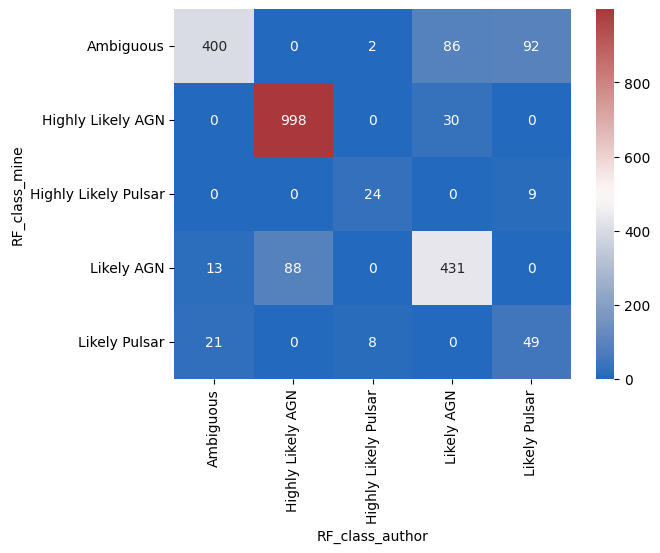

In [ ]:
sns.heatmap(cross_tab_rf, cmap= 'vlag', annot= True, fmt= 'd')

Conclusions from heatmap:
- The diagonal elements shows the alignments between mine & author's model.
- The off-diagonal elements shows the misalignment between mine & author's model.

Since almost 85% of the data, I'll focus on the misaligned data.
- Case-I: My model's ambiguous vs author's pulsar:
    - 94 sources were classified as Pulsar(likely+Highly likely) candidates by author which are identified as ambiguous by model.
- Case-II: My model's Pulsar vs Author's ambiguous:
    - 21 sources were classified as Pulsar candidates, which author's model has classified as ambiguous.
- Case-III: Class Mismatch: My model's Pulsar/AGN identified as other by author's model:
    - From the heatmap, I can see that there is no class mismatch or class mislabeled between my model & author's.

<Axes: xlabel='RF_mine', ylabel='RF_author'>

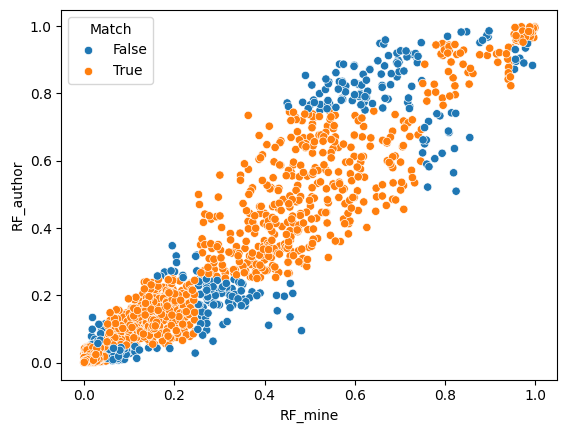

In [ ]:
sns.scatterplot(data= rf_compare, x= 'RF_mine', y= 'RF_author', hue= 'Match')

- From the above figure, I can say that both the models are strongly positively correlated & learning & predicting in similar way.
- The mismatched data might be because of probability decision boundaries (probability threshold) that has been set.

In [ ]:
false_points = rf_compare[rf_compare['Match'] == False]
false_points

,Source_Name,RF_class_mine,RF_mine,RF_class_author,RF_author,Match
3,4FGL J0001.6+3503,Highly Likely AGN,0.046731,Likely AGN,0.0763,False
8,4FGL J0005.5+6634,Ambiguous,0.280727,Likely AGN,0.1789,False
12,4FGL J0007.4-0322,Highly Likely AGN,0.040598,Likely AGN,0.1033,False
39,4FGL J0031.5-4025,Highly Likely AGN,0.016761,Likely AGN,0.0789,False
59,4FGL J0058.1+6915,Likely AGN,0.052153,Highly Likely AGN,0.0200,False
...,...,...,...,...,...,...
2180,4FGL J2241.4-8327,Ambiguous,0.315263,Likely AGN,0.2361,False
2186,4FGL J2250.5+3305,Highly Likely Pulsar,0.974312,Likely Pulsar,0.8903,False
2208,4FGL J2321.4+6145c,Likely AGN,0.065558,Highly Likely AGN,0.0432,False
2229,4FGL J2342.4-4739,Ambiguous,0.666957,Likely Pulsar,0.7855,False


<Axes: xlabel='RF_mine', ylabel='RF_author'>

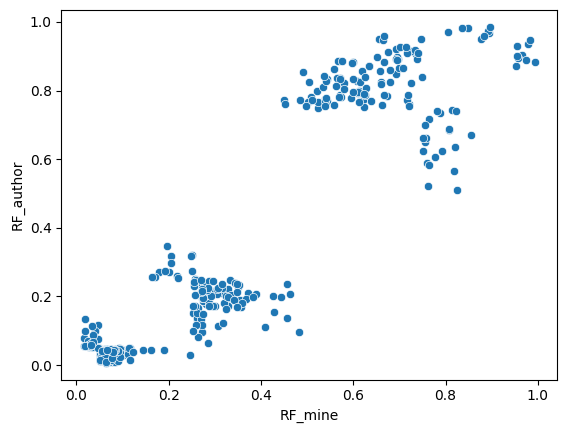

In [ ]:
sns.scatterplot(data= false_points, x= 'RF_mine', y= 'RF_author')

In [ ]:
abs(false_points['RF_mine'] - false_points['RF_author']).max()

0.38625662270368294

In [ ]:
abs(false_points['RF_mine'] - false_points['RF_author']).min()

0.0017080156657829915

In [ ]:
true_disagreement = false_points[abs(false_points['RF_mine'] - false_points['RF_author']) > 0.3]
true_disagreement

,Source_Name,RF_class_mine,RF_mine,RF_class_author,RF_author,Match
550,4FGL J0840.6-3130,Ambiguous,0.481857,Likely AGN,0.0956,False
881,4FGL J1312.6-6231c,Ambiguous,0.566109,Likely Pulsar,0.8870,False
892,4FGL J1321.1-6239,Ambiguous,0.504803,Likely Pulsar,0.8248,False
1045,4FGL J1505.3-5852,Ambiguous,0.558122,Likely Pulsar,0.8616,False
1065,4FGL J1516.4-2640,Ambiguous,0.456542,Likely AGN,0.1366,False
1183,4FGL J1619.3-5047,Ambiguous,0.574948,Likely Pulsar,0.8868,False
1468,4FGL J1738.8-3241,Ambiguous,0.450177,Likely Pulsar,0.7717,False
1699,4FGL J1820.7-3217,Ambiguous,0.452957,Likely Pulsar,0.7614,False
1728,4FGL J1830.1-0212c,Ambiguous,0.535971,Likely Pulsar,0.8428,False
1896,4FGL J1912.0+0927,Ambiguous,0.490697,Likely Pulsar,0.8534,False


- From the heatmap as well as from the above table, I can see that there is no sources which has been misclassified as compared with author's result.
- It looks like author's model is more decisive in nature, whereas my model is comparatively less decisive in nature, but still with impressive predictions.

XGB Comparisom

In [ ]:
xgb_compare = pd.merge(
    df_pred[['Source_Name', 'XGB_class', 'XGB']],
    df_author[['Source_Name', 'XGB_class', 'XGB']],
    on='Source_Name',
    suffixes=('_mine', '_author')
)
xgb_compare.head()

,Source_Name,XGB_class_mine,XGB_mine,XGB_class_author,XGB_author
0,4FGL J0000.3-7355,Highly Likely AGN,0.001007,Highly Likely AGN,0.0024
1,4FGL J0000.5+0743,Highly Likely AGN,0.001603,Highly Likely AGN,0.0003
2,4FGL J0000.7+2530,Highly Likely AGN,0.000782,Highly Likely AGN,0.0083
3,4FGL J0001.6+3503,Highly Likely AGN,0.017177,Highly Likely AGN,0.0373
4,4FGL J0003.3+2511,Highly Likely AGN,0.008735,Highly Likely AGN,0.0055


In [ ]:
xgb_compare['Match'] = (
    xgb_compare['XGB_class_mine'] == xgb_compare['XGB_class_author']
    )
xgb_compare.head()

,Source_Name,XGB_class_mine,XGB_mine,XGB_class_author,XGB_author,Match
0,4FGL J0000.3-7355,Highly Likely AGN,0.001007,Highly Likely AGN,0.0024,True
1,4FGL J0000.5+0743,Highly Likely AGN,0.001603,Highly Likely AGN,0.0003,True
2,4FGL J0000.7+2530,Highly Likely AGN,0.000782,Highly Likely AGN,0.0083,True
3,4FGL J0001.6+3503,Highly Likely AGN,0.017177,Highly Likely AGN,0.0373,True
4,4FGL J0003.3+2511,Highly Likely AGN,0.008735,Highly Likely AGN,0.0055,True


In [ ]:
print(f'Exact match: {xgb_compare['Match'].sum()}')
print(f'Total: {len(xgb_compare)}')
print(f'% of match: {xgb_compare['Match'].sum() / len(xgb_compare) * 100:.2f}%')

Exact match: 1662
Total: 2251
% of match: 73.83%


In [ ]:
cross_tab_xgb = pd.crosstab(
    xgb_compare['XGB_class_mine'],
    xgb_compare['XGB_class_author']
)
cross_tab_xgb

XGB_class_author,Ambiguous,Highly Likely AGN,Highly Likely Pulsar,Likely AGN,Likely Pulsar
XGB_class_mine,,,,,
Ambiguous,232,15,7,104,97
Highly Likely AGN,2,1126,0,64,0
Highly Likely Pulsar,1,0,28,0,27
Likely AGN,71,131,0,221,6
Likely Pulsar,32,0,32,0,55


<Axes: xlabel='XGB_class_author', ylabel='XGB_class_mine'>

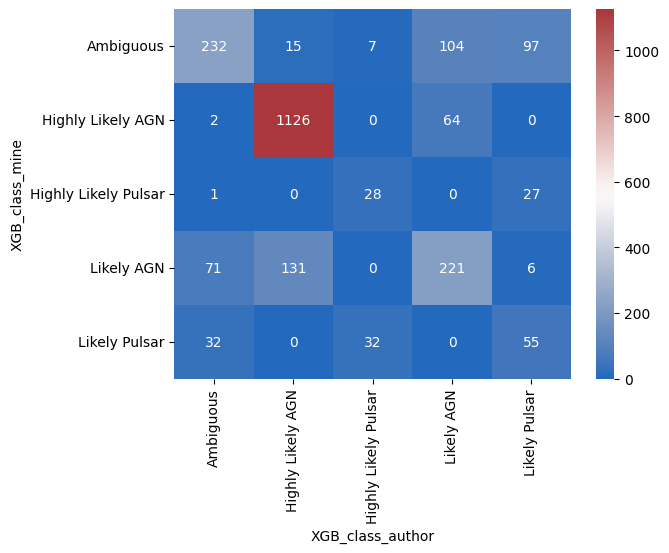

In [ ]:
sns.heatmap(cross_tab_xgb, cmap= 'vlag', annot= True, fmt= 'd')

Conclusions from heatmap:
- The diagonal elements shows the alignments between mine & author's model.
- The off-diagonal elements shows the misalignment between mine & author's model.

Around 74% of the data is misaligned with the author's result.
- Case-I: My model's ambiguous vs author's pulsar:
    - 104 sources were classified as Pulsar(likely+Highly likely) candidates by author which are identified as ambiguous by model.
- Case-II: My model's Pulsar vs Author's ambiguous:
    - 33 sources were classified as Pulsar candidates, which author's model has classified as ambiguous.
- Case-III: Class Mismatch: My model's Pulsar/AGN identified as other by author's model:
    - From the heatmap, I can see that there is only 6 sources which have class mismatch or class mislabeled between my model & author's(Author's likely Pulsar is classified as likely AGN by my model.

<Axes: xlabel='XGB_mine', ylabel='XGB_author'>

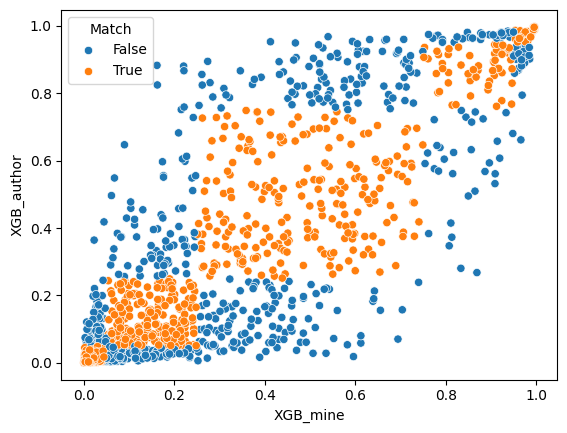

In [ ]:
sns.scatterplot(data= xgb_compare, x= 'XGB_mine', y= 'XGB_author', hue= 'Match')

- From the figure, I see that there is positive correlation between mine & author's model, though it's widely spread across the middle region.
- From the figure, I see that bottom region(AGN region) is highly dense. It means that in the AGN region, my model & author's model are mostly aligned.
- Same goes for the upper right region(Pulsar region) as well.
- The false points that are showing in the bottom left & upper right is because of the threshold probability separating (likely & highly likely) AGNs and (likely & highly likely) pulsars.
- The middle region (ambiguous region) has comparatively less false/mismatched points that true/matched points. All these mismatched points in this region are either in the upper part or in lower part. It means these points are the sources where my model predicted ambiguous, but author's model predicted Pulsar(upper middle region) or where my model predicted ambiguous, but author's model predicted AGN.

In [ ]:
false_points_xgb = xgb_compare[xgb_compare['Match'] == False]
false_points_xgb

,Source_Name,XGB_class_mine,XGB_mine,XGB_class_author,XGB_author,Match
8,4FGL J0005.5+6634,Ambiguous,0.301322,Highly Likely AGN,0.0334,False
42,4FGL J0034.6+6438,Likely AGN,0.054888,Highly Likely AGN,0.0283,False
45,4FGL J0039.1+6257,Likely Pulsar,0.933733,Highly Likely Pulsar,0.9766,False
53,4FGL J0048.6-6347,Likely Pulsar,0.914006,Ambiguous,0.6576,False
54,4FGL J0050.8+3330,Likely AGN,0.057304,Highly Likely AGN,0.0276,False
...,...,...,...,...,...,...
2204,4FGL J2318.6-3827,Ambiguous,0.319334,Likely AGN,0.1112,False
2206,4FGL J2319.0+5102c,Likely AGN,0.079814,Highly Likely AGN,0.0182,False
2229,4FGL J2342.4-4739,Ambiguous,0.722237,Likely Pulsar,0.9112,False
2239,4FGL J2350.7+6738c,Highly Likely AGN,0.011273,Likely AGN,0.1159,False


<Axes: xlabel='XGB_mine', ylabel='XGB_author'>

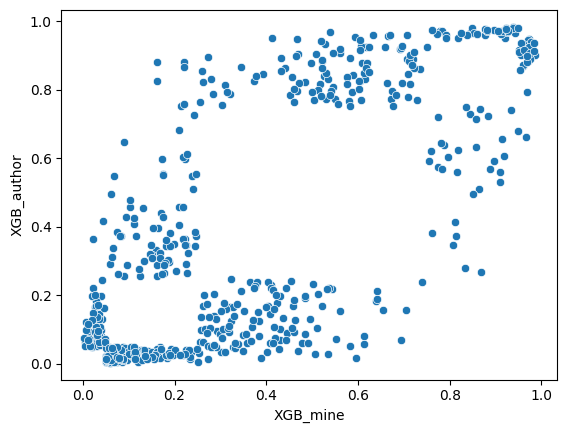

In [ ]:
sns.scatterplot(data= false_points_xgb, x= 'XGB_mine', y= 'XGB_author')

In [ ]:
abs(false_points_xgb['XGB_mine'] - false_points_xgb['XGB_author']).max()

0.7210775519371033

In [ ]:
abs(false_points_xgb['XGB_mine'] - false_points_xgb['XGB_author']).min()

0.003293555986881254

In [ ]:
true_disagreement_xgb = false_points_xgb[abs(false_points_xgb['XGB_mine'] - false_points_xgb['XGB_author']) > 0.3]
true_disagreement_xgb

,Source_Name,XGB_class_mine,XGB_mine,XGB_class_author,XGB_author,Match
203,4FGL J0341.9+3153c,Likely AGN,0.241743,Ambiguous,0.7279,False
260,4FGL J0441.8+2600c,Ambiguous,0.430805,Likely AGN,0.0694,False
293,4FGL J0512.8+5821,Ambiguous,0.348803,Highly Likely AGN,0.0376,False
364,4FGL J0600.7+2012c,Ambiguous,0.418201,Likely AGN,0.0755,False
379,4FGL J0610.9+2040c,Likely Pulsar,0.807684,Ambiguous,0.3472,False
...,...,...,...,...,...,...
1972,4FGL J1954.8+2543c,Likely AGN,0.221098,Likely Pulsar,0.8666,False
1985,4FGL J2004.9+3421,Ambiguous,0.497631,Likely Pulsar,0.8792,False
2063,4FGL J2054.2+6904,Highly Likely Pulsar,0.966236,Ambiguous,0.6615,False
2145,4FGL J2208.4+6443e,Ambiguous,0.518818,Likely Pulsar,0.9435,False


RF_SMOTE Comparison

In [ ]:
rf_smote_compare = pd.merge(
    df_pred[['Source_Name', 'RF_SMOTE_class', 'RF_SMOTE']],
    df_author[['Source_Name', 'RF_SMOTE_class', 'RF_SMOTE']],
    on='Source_Name',
    suffixes=('_mine', '_author')
)
rf_smote_compare.head()

,Source_Name,RF_SMOTE_class_mine,RF_SMOTE_mine,RF_SMOTE_class_author,RF_SMOTE_author
0,4FGL J0000.3-7355,Highly Likely AGN,0.020443,Highly Likely AGN,0.0410
1,4FGL J0000.5+0743,Highly Likely AGN,0.019410,Highly Likely AGN,0.0043
2,4FGL J0000.7+2530,Highly Likely AGN,0.015336,Highly Likely AGN,0.0150
3,4FGL J0001.6+3503,Ambiguous,0.301472,Ambiguous,0.2632
4,4FGL J0003.3+2511,Highly Likely AGN,0.018116,Likely AGN,0.0640


In [ ]:
rf_smote_compare['Match'] = (
    rf_smote_compare['RF_SMOTE_class_mine'] == rf_smote_compare['RF_SMOTE_class_author']
    )
rf_smote_compare.head()

,Source_Name,RF_SMOTE_class_mine,RF_SMOTE_mine,RF_SMOTE_class_author,RF_SMOTE_author,Match
0,4FGL J0000.3-7355,Highly Likely AGN,0.020443,Highly Likely AGN,0.0410,True
1,4FGL J0000.5+0743,Highly Likely AGN,0.019410,Highly Likely AGN,0.0043,True
2,4FGL J0000.7+2530,Highly Likely AGN,0.015336,Highly Likely AGN,0.0150,True
3,4FGL J0001.6+3503,Ambiguous,0.301472,Ambiguous,0.2632,True
4,4FGL J0003.3+2511,Highly Likely AGN,0.018116,Likely AGN,0.0640,False


In [ ]:
print(f'Exact match: {rf_smote_compare['Match'].sum()}')
print(f'Total: {len(rf_smote_compare)}')
print(f'% of match: {rf_smote_compare['Match'].sum() / len(rf_smote_compare) * 100:.2f}%')

Exact match: 1828
Total: 2251
% of match: 81.21%


In [ ]:
cross_tab_rf_smote = pd.crosstab(
    rf_smote_compare['RF_SMOTE_class_mine'],
    rf_smote_compare['RF_SMOTE_class_author']
)
cross_tab_rf_smote

RF_SMOTE_class_author,Ambiguous,Highly Likely AGN,Highly Likely Pulsar,Likely AGN,Likely Pulsar
RF_SMOTE_class_mine,,,,,
Ambiguous,476,0,0,58,103
Highly Likely AGN,0,653,0,76,0
Highly Likely Pulsar,0,0,93,0,11
Likely AGN,52,24,0,263,0
Likely Pulsar,35,0,64,0,343


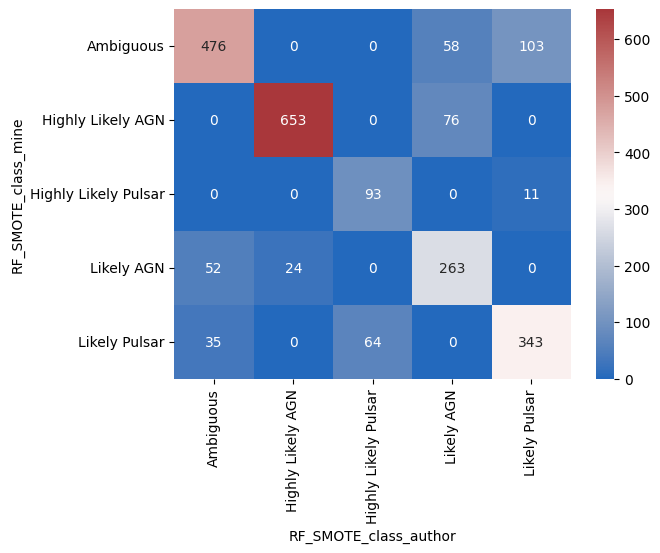

In [ ]:
sns.heatmap(cross_tab_rf_smote, cmap= 'vlag', annot= True, fmt= 'd')
plt.show()

Conclusions from heatmap:
- The diagonal elements shows the alignments between mine & author's model.
- The off-diagonal elements shows the misalignment between mine & author's model.

Since almost 82% of the data, I'll focus on the misaligned data.
- Case-I: My model's ambiguous vs author's pulsar:
    - 103 sources were classified as Pulsar(likely+Highly likely) candidates by author which are identified as ambiguous by model.
- Case-II: My model's Pulsar vs Author's ambiguous:
    - 35 sources were classified as Pulsar candidates, which author's model has classified as ambiguous.
- Case-III: Class Mismatch: My model's Pulsar/AGN identified as other by author's model:
    - From the heatmap, I can see that there is no class mismatch or class mislabeled between my model & author's.

<Axes: xlabel='RF_SMOTE_mine', ylabel='RF_SMOTE_author'>

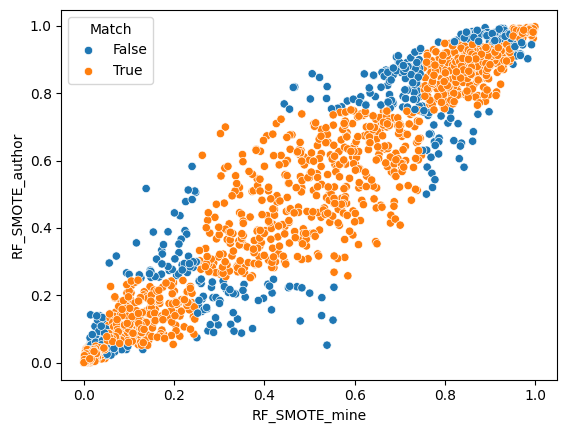

In [ ]:
sns.scatterplot(data= rf_smote_compare, x= 'RF_SMOTE_mine', y= 'RF_SMOTE_author', hue= 'Match')

- From the above figure, I can say that both the models are strongly positively correlated & learning & predicting in similar way.
- It has much tighter spread than XGB, but slightly more spread than RF(though not that much).

- From the figure, I see that bottom region(AGN region) is highly dense. It means that in the AGN region, my model & author's model are mostly aligned.
- Same goes for the upper right region(Pulsar region) as well.
- The false points that are showing in the bottom left & upper right is because of the threshold probability separating (likely & highly likely) AGNs and (likely & highly likely) pulsars.
- The middle region (ambiguous region) has comparatively less false/mismatched points that true/matched points. All these mismatched points in this region are either in the upper part or in lower part. It means these points are the sources where my model predicted ambiguous, but author's model predicted Pulsar(upper middle region) or where my model predicted ambiguous, but author's model predicted AGN, but such cases are comparatively small.

In [ ]:
false_points_rf_smote = rf_smote_compare[rf_smote_compare['Match'] == False]
false_points_rf_smote

,Source_Name,RF_SMOTE_class_mine,RF_SMOTE_mine,RF_SMOTE_class_author,RF_SMOTE_author,Match
4,4FGL J0003.3+2511,Highly Likely AGN,0.018116,Likely AGN,0.0640,False
6,4FGL J0004.0+5715,Ambiguous,0.259546,Likely AGN,0.2352,False
12,4FGL J0007.4-0322,Highly Likely AGN,0.041439,Likely AGN,0.1305,False
21,4FGL J0011.5+4822,Highly Likely AGN,0.039670,Likely AGN,0.0836,False
23,4FGL J0017.4+6506,Ambiguous,0.285932,Likely AGN,0.1934,False
...,...,...,...,...,...,...
2183,4FGL J2247.5+5812c,Ambiguous,0.300284,Likely AGN,0.1764,False
2192,4FGL J2301.8+6235c,Ambiguous,0.658454,Likely Pulsar,0.8174,False
2197,4FGL J2304.0+5406e,Likely Pulsar,0.842265,Ambiguous,0.5802,False
2201,4FGL J2312.4+8253,Likely AGN,0.056028,Ambiguous,0.2961,False


<Axes: xlabel='RF_SMOTE_mine', ylabel='RF_SMOTE_author'>

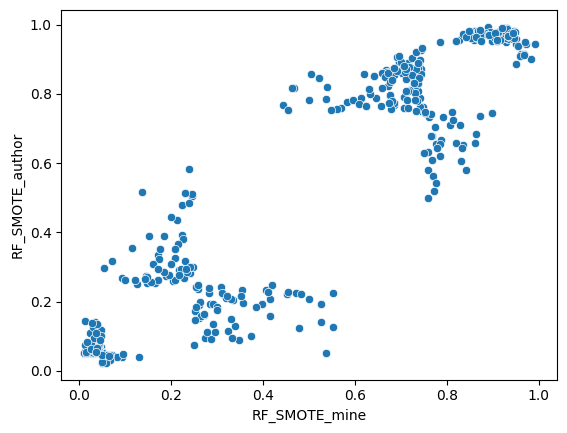

In [ ]:
sns.scatterplot(data= false_points_rf_smote, x= 'RF_SMOTE_mine', y= 'RF_SMOTE_author')

In [ ]:
abs(false_points_rf_smote['RF_SMOTE_mine'] - false_points_rf_smote['RF_SMOTE_author']).max()

0.4861272271537096

In [ ]:
abs(false_points_rf_smote['RF_SMOTE_mine'] - false_points_rf_smote['RF_SMOTE_author']).min()

0.0033322482309746937

In [ ]:
true_disagreement_rf_smote = false_points_rf_smote[abs(false_points_rf_smote['RF_SMOTE_mine'] - false_points_rf_smote['RF_SMOTE_author']) > 0.3]
true_disagreement_rf_smote

,Source_Name,RF_SMOTE_class_mine,RF_SMOTE_mine,RF_SMOTE_class_author,RF_SMOTE_author,Match
449,4FGL J0705.0+1331,Likely AGN,0.239578,Ambiguous,0.5825,False
593,4FGL J0902.5-4727,Ambiguous,0.526692,Likely AGN,0.1400,False
634,4FGL J0940.5-5253,Ambiguous,0.505783,Likely Pulsar,0.8573,False
753,4FGL J1122.4-6237,Ambiguous,0.538627,Likely AGN,0.0525,False
1218,4FGL J1628.6-4553,Ambiguous,0.551947,Likely AGN,0.1267,False
1267,4FGL J1646.7-2154,Ambiguous,0.467093,Likely Pulsar,0.8180,False
1303,4FGL J1658.3-4637c,Ambiguous,0.553982,Likely AGN,0.2242,False
1429,4FGL J1729.7-4242,Ambiguous,0.443767,Likely Pulsar,0.7679,False
1447,4FGL J1733.5-2950,Ambiguous,0.527235,Likely AGN,0.1934,False
1626,4FGL J1808.4-3522,Ambiguous,0.522139,Likely Pulsar,0.8464,False


- From the heatmap as well as from the above table, I can see that there is no sources which has been misclassified as compared with author's result.

XGB_SMOTE Comparison

In [ ]:
xgb_smote_compare = pd.merge(
    df_pred[['Source_Name', 'XGB_SMOTE_class', 'XGB_SMOTE']],
    df_author[['Source_Name', 'XGB_SMOTE_class', 'XGB_SMOTE']],
    on='Source_Name',
    suffixes=('_mine', '_author')
)
xgb_smote_compare.head()

,Source_Name,XGB_SMOTE_class_mine,XGB_SMOTE_mine,XGB_SMOTE_class_author,XGB_SMOTE_author
0,4FGL J0000.3-7355,Highly Likely AGN,0.000233,Highly Likely AGN,0.0001
1,4FGL J0000.5+0743,Highly Likely AGN,0.000606,Highly Likely AGN,0.0000
2,4FGL J0000.7+2530,Highly Likely AGN,0.000211,Highly Likely AGN,0.0001
3,4FGL J0001.6+3503,Ambiguous,0.570655,Ambiguous,0.5293
4,4FGL J0003.3+2511,Highly Likely AGN,0.000187,Highly Likely AGN,0.0059


In [ ]:
xgb_smote_compare['Match'] = (
    xgb_smote_compare['XGB_SMOTE_class_mine'] == xgb_smote_compare['XGB_SMOTE_class_author']
    )
xgb_smote_compare.head()

,Source_Name,XGB_SMOTE_class_mine,XGB_SMOTE_mine,XGB_SMOTE_class_author,XGB_SMOTE_author,Match
0,4FGL J0000.3-7355,Highly Likely AGN,0.000233,Highly Likely AGN,0.0001,True
1,4FGL J0000.5+0743,Highly Likely AGN,0.000606,Highly Likely AGN,0.0000,True
2,4FGL J0000.7+2530,Highly Likely AGN,0.000211,Highly Likely AGN,0.0001,True
3,4FGL J0001.6+3503,Ambiguous,0.570655,Ambiguous,0.5293,True
4,4FGL J0003.3+2511,Highly Likely AGN,0.000187,Highly Likely AGN,0.0059,True


In [ ]:
print(f'Exact match: {xgb_smote_compare['Match'].sum()}')
print(f'Total: {len(xgb_smote_compare)}')
print(f'% of match: {xgb_smote_compare['Match'].sum() / len(xgb_smote_compare) * 100:.2f}%')

Exact match: 1487
Total: 2251
% of match: 66.06%


In [ ]:
cross_tab_xgb_smote = pd.crosstab(
    xgb_smote_compare['XGB_SMOTE_class_mine'],
    xgb_smote_compare['XGB_SMOTE_class_author']
)
cross_tab_xgb_smote

XGB_SMOTE_class_author,Ambiguous,Highly Likely AGN,Highly Likely Pulsar,Likely AGN,Likely Pulsar
XGB_SMOTE_class_mine,,,,,
Ambiguous,122,47,33,64,72
Highly Likely AGN,46,991,2,67,9
Highly Likely Pulsar,30,0,226,5,72
Likely AGN,44,71,4,60,19
Likely Pulsar,73,11,67,28,88


<Axes: xlabel='XGB_SMOTE_class_author', ylabel='XGB_SMOTE_class_mine'>

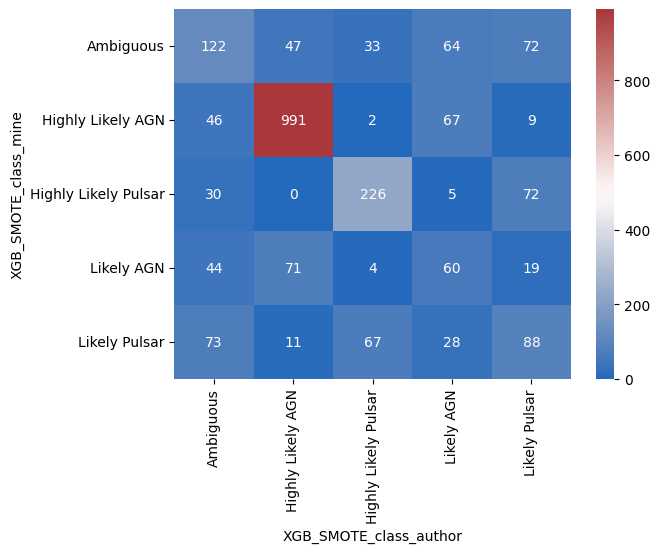

In [ ]:
sns.heatmap(cross_tab_xgb_smote, cmap= 'vlag', annot= True, fmt= 'd')

Conclusions from heatmap:
- The diagonal elements shows the alignments between mine & author's model.
- The off-diagonal elements shows the misalignment between mine & author's model.

66% of data are matching perfectly with author's result. So, I'll focus on mismatched data points here:
- Case-I: My model's ambiguous vs author's pulsar:
    - 105 sources were classified as Pulsar(likely+Highly likely) candidates by author which are identified as ambiguous by model.
- Case-II: My model's Pulsar vs Author's ambiguous:
    - 103 sources were classified as Pulsar candidates, which author's model has classified as ambiguous.
- Case-III: Class Mismatch: My model's Pulsar/AGN identified as other by author's model:
    - From the heatmap, I can see that there is some class mismatch or class mislabeled between my model & author's.
        - 23 sources labeled as likely AGN by my model -> 4 (highly likely pulsar) + 19 (likely pulsar) by author's model
        - 11 sources labeled as highly likely AGN by my model -> 2 (highly likely pulsar) + 9 (likely pulsar) by author's model
        - 39 sources labeled as likely Pulsar by my model -> 11 (highly likely AGN) + 28 (likely AGN) by author's model
        - 5 sources labeled as highly likely Pulsar by my model -> 0 (highly likely AGN) + 5 (likely AGN) by author's model
    - In total, the predictions from mine & author's model contradicts each other in 78 sources.

<Axes: xlabel='XGB_SMOTE_mine', ylabel='XGB_SMOTE_author'>

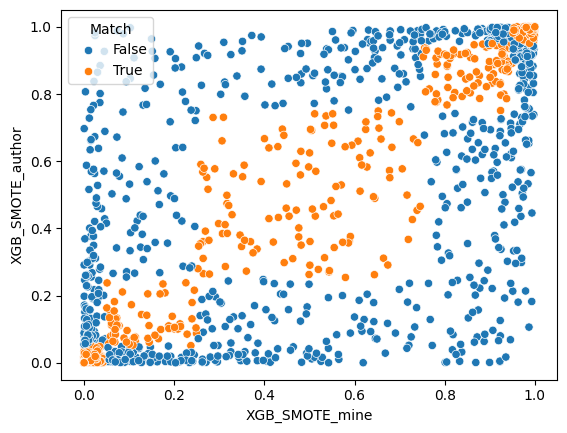

In [ ]:
sns.scatterplot(data= xgb_smote_compare, x= 'XGB_SMOTE_mine', y= 'XGB_SMOTE_author', hue= 'Match')

- From the above figure, I can say that both the models are have widely distributed distribution, hence I can say that these two models didn't learn from the data in the similar way.
- Since the misagreed points are spread across the plot, I can say that the cause of contradiction is not probability threshold, instead it's the way the model's learned during training. It seems that my model & author's model learned in a opposite way during the training.

In [ ]:
false_points_xgb_smote = xgb_smote_compare[xgb_smote_compare['Match'] == False]
false_points_xgb_smote

,Source_Name,XGB_SMOTE_class_mine,XGB_SMOTE_mine,XGB_SMOTE_class_author,XGB_SMOTE_author,Match
6,4FGL J0004.0+5715,Likely AGN,0.219681,Ambiguous,0.2874,False
9,4FGL J0005.6+6746c,Likely AGN,0.122367,Ambiguous,0.5837,False
13,4FGL J0008.4+6926,Likely AGN,0.191262,Highly Likely AGN,0.0076,False
23,4FGL J0017.4+6506,Ambiguous,0.493773,Highly Likely AGN,0.0284,False
38,4FGL J0031.0-2327,Likely Pulsar,0.764771,Highly Likely Pulsar,0.9581,False
...,...,...,...,...,...,...
2239,4FGL J2350.7+6738c,Highly Likely AGN,0.005520,Ambiguous,0.5877,False
2240,4FGL J2351.3+3913,Likely AGN,0.069531,Highly Likely AGN,0.0027,False
2244,4FGL J2355.5-6614,Highly Likely AGN,0.007351,Ambiguous,0.2990,False
2247,4FGL J2357.8+6839,Highly Likely AGN,0.024580,Highly Likely Pulsar,0.9821,False


<Axes: xlabel='XGB_SMOTE_mine', ylabel='XGB_SMOTE_author'>

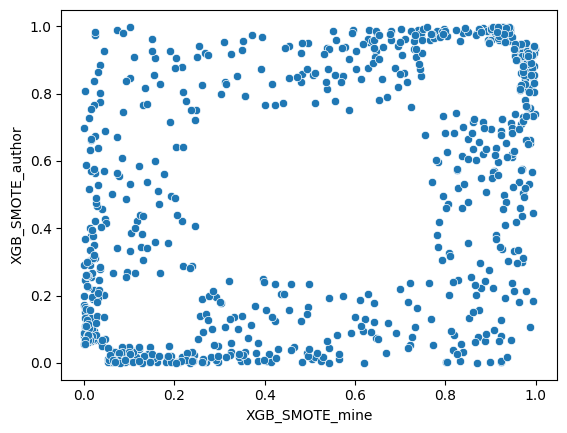

In [ ]:
sns.scatterplot(data= false_points_xgb_smote, x= 'XGB_SMOTE_mine', y= 'XGB_SMOTE_author')

In [ ]:
abs(false_points_xgb_smote['XGB_SMOTE_mine'] - false_points_xgb_smote['XGB_SMOTE_author']).max()

0.9575200298339128

In [ ]:
abs(false_points_xgb_smote['XGB_SMOTE_mine'] - false_points_xgb_smote['XGB_SMOTE_author']).min()

0.005320175743103062

In [ ]:
true_disagreement_xgb_smote = false_points_xgb_smote[abs(false_points_xgb_smote['XGB_SMOTE_mine'] - false_points_xgb_smote['XGB_SMOTE_author']) > 0.3]
true_disagreement_xgb_smote

,Source_Name,XGB_SMOTE_class_mine,XGB_SMOTE_mine,XGB_SMOTE_class_author,XGB_SMOTE_author,Match
9,4FGL J0005.6+6746c,Likely AGN,0.122367,Ambiguous,0.5837,False
23,4FGL J0017.4+6506,Ambiguous,0.493773,Highly Likely AGN,0.0284,False
98,4FGL J0136.4+6911,Ambiguous,0.416565,Likely Pulsar,0.8295,False
104,4FGL J0140.4+5114,Ambiguous,0.590776,Likely AGN,0.0884,False
106,4FGL J0142.5+6650,Ambiguous,0.480936,Likely Pulsar,0.8334,False
...,...,...,...,...,...,...
2180,4FGL J2241.4-8327,Ambiguous,0.445291,Likely Pulsar,0.9351,False
2189,4FGL J2256.5+6212c,Likely AGN,0.202983,Likely Pulsar,0.9053,False
2239,4FGL J2350.7+6738c,Highly Likely AGN,0.005520,Ambiguous,0.5877,False
2247,4FGL J2357.8+6839,Highly Likely AGN,0.024580,Highly Likely Pulsar,0.9821,False


- From the heatmap & the distribution, I can say that my model & author's model learned mostly opposite way.
- Also, I would like to point it out that since this comparison is based on completely unknown data, i.e., we don't have the correct label for each source, I can't say if my model or author's model is predicting with higher accuracy.
- All I can compare with the author's result is the training model accuracies.

Sources predicted as "Pulsar": common in my model & author's prediction

In [ ]:
pulsar_classes = ['Likely Pulsar', 'Highly Likely Pulsar']

In [ ]:
pulsar_cross_tab_rf = cross_tab_rf.loc[pulsar_classes, pulsar_classes]
pulsar_cross_tab_rf

RF_class_author,Likely Pulsar,Highly Likely Pulsar
RF_class_mine,,
Likely Pulsar,49,8
Highly Likely Pulsar,9,24


<Axes: xlabel='RF_class_author', ylabel='RF_class_mine'>

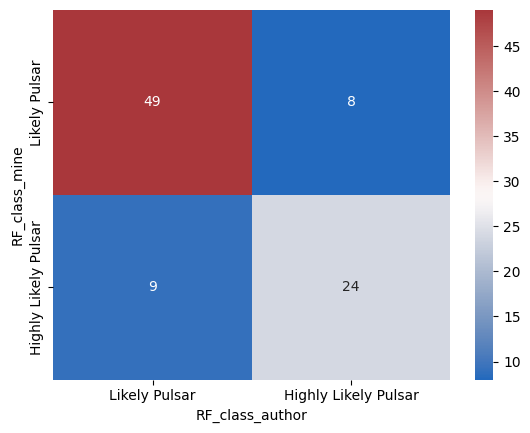

In [ ]:
sns.heatmap(pulsar_cross_tab_rf, annot=True, fmt='d', cmap='vlag')

In [ ]:
pulsar_cross_tab_rf_smote = cross_tab_rf_smote.loc[pulsar_classes, pulsar_classes]
pulsar_cross_tab_rf_smote

RF_SMOTE_class_author,Likely Pulsar,Highly Likely Pulsar
RF_SMOTE_class_mine,,
Likely Pulsar,343,64
Highly Likely Pulsar,11,93


<Axes: xlabel='RF_SMOTE_class_author', ylabel='RF_SMOTE_class_mine'>

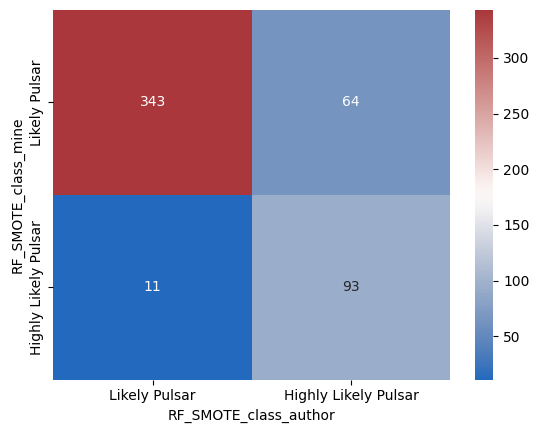

In [ ]:
sns.heatmap(pulsar_cross_tab_rf_smote, annot=True, fmt='d', cmap='vlag')

In [ ]:
pulsar_cross_tab_xgb = cross_tab_xgb.loc[pulsar_classes, pulsar_classes]
pulsar_cross_tab_xgb

XGB_class_author,Likely Pulsar,Highly Likely Pulsar
XGB_class_mine,,
Likely Pulsar,55,32
Highly Likely Pulsar,27,28


<Axes: xlabel='XGB_class_author', ylabel='XGB_class_mine'>

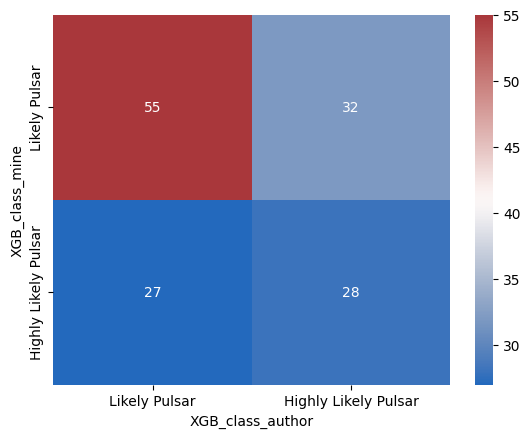

In [ ]:
sns.heatmap(pulsar_cross_tab_xgb, annot=True, fmt='d', cmap='vlag')

In [ ]:
pulsar_cross_tab_xgb_smote = cross_tab_xgb_smote.loc[pulsar_classes, pulsar_classes]
pulsar_cross_tab_xgb_smote

XGB_SMOTE_class_author,Likely Pulsar,Highly Likely Pulsar
XGB_SMOTE_class_mine,,
Likely Pulsar,88,67
Highly Likely Pulsar,72,226


<Axes: xlabel='XGB_SMOTE_class_author', ylabel='XGB_SMOTE_class_mine'>

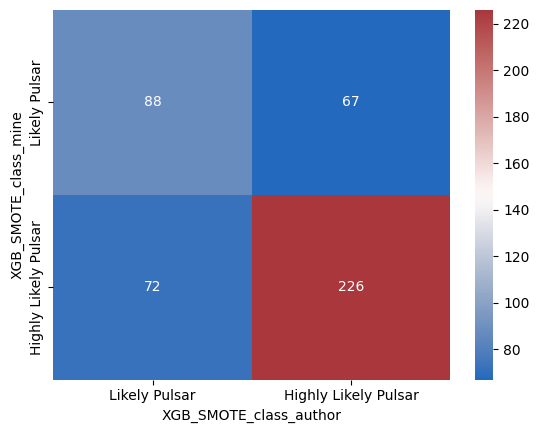

In [ ]:
sns.heatmap(pulsar_cross_tab_xgb_smote, annot=True, fmt='d', cmap='vlag')

psrqpy is the Python package for interacting with the ATNF Pulsar Catalogue.

In [ ]:
!pip install psrqpy

In [ ]:
from psrqpy import QueryATNF

In [ ]:
query = QueryATNF(params=['Name', 'GL', 'GB'])
df_atnf = query.pandas

In [ ]:
df_atnf.head()

,GL,GB,NAME
0,117.326628,-0.073821,J0002+6216
1,108.172136,-42.984988,J0006+1834
2,119.659601,10.463079,J0007+7303
3,106.228269,-53.407050,J0011+08
4,117.230523,-7.911120,J0012+5431


In [ ]:
df_atnf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4351 entries, 0 to 4350
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   GL      4277 non-null   float64
 1   GB      4277 non-null   float64
 2   NAME    4351 non-null   object 
dtypes: float64(2), object(1)
memory usage: 102.1+ KB


In [ ]:
df_atnf.dropna(inplace= True)

In [ ]:
rf_compare.head()

,Source_Name,RF_class_mine,RF_mine,RF_class_author,RF_author,Match
0,4FGL J0000.3-7355,Highly Likely AGN,0.001072,Highly Likely AGN,0.0030,True
1,4FGL J0000.5+0743,Highly Likely AGN,0.002244,Highly Likely AGN,0.0009,True
2,4FGL J0000.7+2530,Highly Likely AGN,0.019128,Highly Likely AGN,0.0184,True
3,4FGL J0001.6+3503,Highly Likely AGN,0.046731,Likely AGN,0.0763,False
4,4FGL J0003.3+2511,Highly Likely AGN,0.003602,Highly Likely AGN,0.0132,True


In [ ]:
df_pred.head()

,Source_Name,GLAT,GLON,RF,XGB,RF_SMOTE,XGB_SMOTE,RF_class,XGB_class,RF_SMOTE_class,XGB_SMOTE_class
0,4FGL J0000.3-7355,-42.729538,307.708984,0.001072,0.001007,0.020443,0.000233,Highly Likely AGN,Highly Likely AGN,Highly Likely AGN,Highly Likely AGN
1,4FGL J0000.5+0743,-53.029457,101.656479,0.002244,0.001603,0.019410,0.000606,Highly Likely AGN,Highly Likely AGN,Highly Likely AGN,Highly Likely AGN
2,4FGL J0000.7+2530,-35.959175,108.775070,0.019128,0.000782,0.015336,0.000211,Highly Likely AGN,Highly Likely AGN,Highly Likely AGN,Highly Likely AGN
3,4FGL J0001.6+3503,-26.710260,111.538116,0.046731,0.017177,0.301472,0.570655,Highly Likely AGN,Highly Likely AGN,Ambiguous,Ambiguous
4,4FGL J0003.3+2511,-36.411484,109.381638,0.003602,0.008735,0.018116,0.000187,Highly Likely AGN,Highly Likely AGN,Highly Likely AGN,Highly Likely AGN


In [ ]:
rf_compare.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2251 entries, 0 to 2250
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Source_Name      2251 non-null   object 
 1   RF_class_mine    2251 non-null   object 
 2   RF_mine          2251 non-null   float64
 3   RF_class_author  2251 non-null   object 
 4   RF_author        2251 non-null   float64
 5   Match            2251 non-null   bool   
dtypes: bool(1), float64(2), object(3)
memory usage: 90.3+ KB


In [ ]:
rf_smote_compare.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2251 entries, 0 to 2250
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Source_Name            2251 non-null   object 
 1   RF_SMOTE_class_mine    2251 non-null   object 
 2   RF_SMOTE_mine          2251 non-null   float64
 3   RF_SMOTE_class_author  2251 non-null   object 
 4   RF_SMOTE_author        2251 non-null   float64
 5   Match                  2251 non-null   bool   
dtypes: bool(1), float64(2), object(3)
memory usage: 90.3+ KB


In [ ]:
xgb_compare.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2251 entries, 0 to 2250
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Source_Name       2251 non-null   object 
 1   XGB_class_mine    2251 non-null   object 
 2   XGB_mine          2251 non-null   float32
 3   XGB_class_author  2251 non-null   object 
 4   XGB_author        2251 non-null   float64
 5   Match             2251 non-null   bool   
dtypes: bool(1), float32(1), float64(1), object(3)
memory usage: 81.5+ KB


In [ ]:
xgb_smote_compare.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2251 entries, 0 to 2250
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Source_Name             2251 non-null   object 
 1   XGB_SMOTE_class_mine    2251 non-null   object 
 2   XGB_SMOTE_mine          2251 non-null   float32
 3   XGB_SMOTE_class_author  2251 non-null   object 
 4   XGB_SMOTE_author        2251 non-null   float64
 5   Match                   2251 non-null   bool   
dtypes: bool(1), float32(1), float64(1), object(3)
memory usage: 81.5+ KB


In [ ]:
df_pred.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2423 entries, 0 to 2422
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Source_Name      2423 non-null   object 
 1   GLAT             2423 non-null   float64
 2   GLON             2423 non-null   float64
 3   RF               2423 non-null   float64
 4   XGB              2423 non-null   float32
 5   RF_SMOTE         2423 non-null   float64
 6   XGB_SMOTE        2423 non-null   float32
 7   RF_class         2423 non-null   object 
 8   XGB_class        2423 non-null   object 
 9   RF_SMOTE_class   2423 non-null   object 
 10  XGB_SMOTE_class  2423 non-null   object 
dtypes: float32(2), float64(4), object(5)
memory usage: 189.4+ KB


For comparing with ATNF catalog, I need location data of each source. That's why I am merging the location data(GLON & GLAT) to the dataframe.

In [ ]:
rf_compare = pd.merge(rf_compare, df_pred[['Source_Name', 'GLAT', 'GLON']], on= 'Source_Name')
rf_compare.head()

,Source_Name,RF_class_mine,RF_mine,RF_class_author,RF_author,Match,GLAT,GLON
0,4FGL J0000.3-7355,Highly Likely AGN,0.001072,Highly Likely AGN,0.0030,True,-42.729538,307.708984
1,4FGL J0000.5+0743,Highly Likely AGN,0.002244,Highly Likely AGN,0.0009,True,-53.029457,101.656479
2,4FGL J0000.7+2530,Highly Likely AGN,0.019128,Highly Likely AGN,0.0184,True,-35.959175,108.775070
3,4FGL J0001.6+3503,Highly Likely AGN,0.046731,Likely AGN,0.0763,False,-26.710260,111.538116
4,4FGL J0003.3+2511,Highly Likely AGN,0.003602,Highly Likely AGN,0.0132,True,-36.411484,109.381638


In [ ]:
rf_compare.columns

Index(['Source_Name', 'RF_class_mine', 'RF_mine', 'RF_class_author',
       'RF_author', 'Match', 'GLAT', 'GLON'],
      dtype='object')

In [ ]:
rf_compare = rf_compare[['Source_Name', 'GLAT', 'GLON', 'RF_class_mine', 'RF_mine', 'RF_class_author', 'RF_author', 'Match']]
rf_compare.head()

,Source_Name,GLAT,GLON,RF_class_mine,RF_mine,RF_class_author,RF_author,Match
0,4FGL J0000.3-7355,-42.729538,307.708984,Highly Likely AGN,0.001072,Highly Likely AGN,0.0030,True
1,4FGL J0000.5+0743,-53.029457,101.656479,Highly Likely AGN,0.002244,Highly Likely AGN,0.0009,True
2,4FGL J0000.7+2530,-35.959175,108.775070,Highly Likely AGN,0.019128,Highly Likely AGN,0.0184,True
3,4FGL J0001.6+3503,-26.710260,111.538116,Highly Likely AGN,0.046731,Likely AGN,0.0763,False
4,4FGL J0003.3+2511,-36.411484,109.381638,Highly Likely AGN,0.003602,Highly Likely AGN,0.0132,True


RF-SMOTE

In [ ]:
rf_smote_compare = pd.merge(rf_smote_compare, df_pred[['Source_Name', 'GLAT', 'GLON']], on= 'Source_Name')
rf_smote_compare.head()

,Source_Name,RF_SMOTE_class_mine,RF_SMOTE_mine,RF_SMOTE_class_author,RF_SMOTE_author,Match,GLAT,GLON
0,4FGL J0000.3-7355,Highly Likely AGN,0.020443,Highly Likely AGN,0.0410,True,-42.729538,307.708984
1,4FGL J0000.5+0743,Highly Likely AGN,0.019410,Highly Likely AGN,0.0043,True,-53.029457,101.656479
2,4FGL J0000.7+2530,Highly Likely AGN,0.015336,Highly Likely AGN,0.0150,True,-35.959175,108.775070
3,4FGL J0001.6+3503,Ambiguous,0.301472,Ambiguous,0.2632,True,-26.710260,111.538116
4,4FGL J0003.3+2511,Highly Likely AGN,0.018116,Likely AGN,0.0640,False,-36.411484,109.381638


In [ ]:
rf_smote_compare.columns

Index(['Source_Name', 'RF_SMOTE_class_mine', 'RF_SMOTE_mine',
       'RF_SMOTE_class_author', 'RF_SMOTE_author', 'Match', 'GLAT', 'GLON'],
      dtype='object')

In [ ]:
rf_smote_compare = rf_smote_compare[['Source_Name', 'GLAT', 'GLON', 'RF_SMOTE_class_mine', 'RF_SMOTE_mine', 'RF_SMOTE_class_author', 'RF_SMOTE_author', 'Match']]
rf_smote_compare.head()

,Source_Name,GLAT,GLON,RF_SMOTE_class_mine,RF_SMOTE_mine,RF_SMOTE_class_author,RF_SMOTE_author,Match
0,4FGL J0000.3-7355,-42.729538,307.708984,Highly Likely AGN,0.020443,Highly Likely AGN,0.0410,True
1,4FGL J0000.5+0743,-53.029457,101.656479,Highly Likely AGN,0.019410,Highly Likely AGN,0.0043,True
2,4FGL J0000.7+2530,-35.959175,108.775070,Highly Likely AGN,0.015336,Highly Likely AGN,0.0150,True
3,4FGL J0001.6+3503,-26.710260,111.538116,Ambiguous,0.301472,Ambiguous,0.2632,True
4,4FGL J0003.3+2511,-36.411484,109.381638,Highly Likely AGN,0.018116,Likely AGN,0.0640,False


XGB

In [ ]:
xgb_compare = pd.merge(xgb_compare, df_pred[['Source_Name', 'GLAT', 'GLON']], on= 'Source_Name')
xgb_compare.head()

,Source_Name,XGB_class_mine,XGB_mine,XGB_class_author,XGB_author,Match,GLAT,GLON
0,4FGL J0000.3-7355,Highly Likely AGN,0.001007,Highly Likely AGN,0.0024,True,-42.729538,307.708984
1,4FGL J0000.5+0743,Highly Likely AGN,0.001603,Highly Likely AGN,0.0003,True,-53.029457,101.656479
2,4FGL J0000.7+2530,Highly Likely AGN,0.000782,Highly Likely AGN,0.0083,True,-35.959175,108.775070
3,4FGL J0001.6+3503,Highly Likely AGN,0.017177,Highly Likely AGN,0.0373,True,-26.710260,111.538116
4,4FGL J0003.3+2511,Highly Likely AGN,0.008735,Highly Likely AGN,0.0055,True,-36.411484,109.381638


In [ ]:
xgb_compare.columns

Index(['Source_Name', 'XGB_class_mine', 'XGB_mine', 'XGB_class_author',
       'XGB_author', 'Match', 'GLAT', 'GLON'],
      dtype='object')

In [ ]:
xgb_compare = xgb_compare[['Source_Name', 'GLAT', 'GLON', 'XGB_class_mine', 'XGB_mine', 'XGB_class_author', 'XGB_author', 'Match']]
xgb_compare.head()

,Source_Name,GLAT,GLON,XGB_class_mine,XGB_mine,XGB_class_author,XGB_author,Match
0,4FGL J0000.3-7355,-42.729538,307.708984,Highly Likely AGN,0.001007,Highly Likely AGN,0.0024,True
1,4FGL J0000.5+0743,-53.029457,101.656479,Highly Likely AGN,0.001603,Highly Likely AGN,0.0003,True
2,4FGL J0000.7+2530,-35.959175,108.775070,Highly Likely AGN,0.000782,Highly Likely AGN,0.0083,True
3,4FGL J0001.6+3503,-26.710260,111.538116,Highly Likely AGN,0.017177,Highly Likely AGN,0.0373,True
4,4FGL J0003.3+2511,-36.411484,109.381638,Highly Likely AGN,0.008735,Highly Likely AGN,0.0055,True


XGB-SMOTE

In [ ]:
xgb_smote_compare = pd.merge(xgb_smote_compare, df_pred[['Source_Name', 'GLAT', 'GLON']], on= 'Source_Name')
xgb_smote_compare.head()

,Source_Name,XGB_SMOTE_class_mine,XGB_SMOTE_mine,XGB_SMOTE_class_author,XGB_SMOTE_author,Match,GLAT,GLON
0,4FGL J0000.3-7355,Highly Likely AGN,0.000233,Highly Likely AGN,0.0001,True,-42.729538,307.708984
1,4FGL J0000.5+0743,Highly Likely AGN,0.000606,Highly Likely AGN,0.0000,True,-53.029457,101.656479
2,4FGL J0000.7+2530,Highly Likely AGN,0.000211,Highly Likely AGN,0.0001,True,-35.959175,108.775070
3,4FGL J0001.6+3503,Ambiguous,0.570655,Ambiguous,0.5293,True,-26.710260,111.538116
4,4FGL J0003.3+2511,Highly Likely AGN,0.000187,Highly Likely AGN,0.0059,True,-36.411484,109.381638


In [ ]:
xgb_smote_compare.columns

Index(['Source_Name', 'XGB_SMOTE_class_mine', 'XGB_SMOTE_mine',
       'XGB_SMOTE_class_author', 'XGB_SMOTE_author', 'Match', 'GLAT', 'GLON'],
      dtype='object')

In [ ]:
xgb_smote_compare = xgb_smote_compare[['Source_Name', 'GLAT', 'GLON', 'XGB_SMOTE_class_mine', 'XGB_SMOTE_mine', 'XGB_SMOTE_class_author', 'XGB_SMOTE_author', 'Match']]
xgb_smote_compare.head()

,Source_Name,GLAT,GLON,XGB_SMOTE_class_mine,XGB_SMOTE_mine,XGB_SMOTE_class_author,XGB_SMOTE_author,Match
0,4FGL J0000.3-7355,-42.729538,307.708984,Highly Likely AGN,0.000233,Highly Likely AGN,0.0001,True
1,4FGL J0000.5+0743,-53.029457,101.656479,Highly Likely AGN,0.000606,Highly Likely AGN,0.0000,True
2,4FGL J0000.7+2530,-35.959175,108.775070,Highly Likely AGN,0.000211,Highly Likely AGN,0.0001,True
3,4FGL J0001.6+3503,-26.710260,111.538116,Ambiguous,0.570655,Ambiguous,0.5293,True
4,4FGL J0003.3+2511,-36.411484,109.381638,Highly Likely AGN,0.000187,Highly Likely AGN,0.0059,True


In [ ]:
df_atnf.head()

,GL,GB,NAME
0,117.326628,-0.073821,J0002+6216
1,108.172136,-42.984988,J0006+1834
2,119.659601,10.463079,J0007+7303
3,106.228269,-53.407050,J0011+08
4,117.230523,-7.911120,J0012+5431


In [ ]:
df_atnf.rename(columns= {'NAME': 'Source_Name', 'GL': 'GLON', 'GB': 'GLAT'}, inplace= True)
df_atnf.head()

,GLON,GLAT,Source_Name
0,117.326628,-0.073821,J0002+6216
1,108.172136,-42.984988,J0006+1834
2,119.659601,10.463079,J0007+7303
3,106.228269,-53.407050,J0011+08
4,117.230523,-7.911120,J0012+5431


**Verification of Pulsar candidates with ATNF catalog**

1. RF

In [ ]:
rf_pulsar = rf_compare[rf_compare['RF_mine'] >= 0.75].copy()

In [ ]:
rf_pulsar['RF_class_mine'].value_counts()

,count
RF_class_mine,
Likely Pulsar,78
Highly Likely Pulsar,33


In [ ]:
rf_pulsar.head()

,Source_Name,GLAT,GLON,RF_class_mine,RF_mine,RF_class_author,RF_author,Match
5,4FGL J0003.6+3059,-30.771994,111.004486,Likely Pulsar,0.948346,Likely Pulsar,0.8972,True
45,4FGL J0039.1+6257,0.121891,121.535309,Highly Likely Pulsar,0.975554,Highly Likely Pulsar,0.9517,True
102,4FGL J0139.5-2228,-78.132126,192.493973,Likely Pulsar,0.754543,Ambiguous,0.6503,False
145,4FGL J0235.3+5650,-3.194749,136.818665,Likely Pulsar,0.818774,Ambiguous,0.5644,False
146,4FGL J0237.8+5238,-6.920497,138.826584,Highly Likely Pulsar,0.996371,Highly Likely Pulsar,0.9660,True


In [ ]:
from astropy.coordinates import SkyCoord
import astropy.units as u

Here, I am Fermi-LAT data & ATNF catalog data into astronomical coordinate so that I can compute angular distances & match sources between catalogs.

In [ ]:
coords_fermi = SkyCoord(
    l=rf_pulsar['GLON'].values * u.degree,
    b=rf_pulsar['GLAT'].values * u.degree,
    frame='galactic'
)

coords_atnf = SkyCoord(
    l=df_atnf['GLON'].values * u.degree,
    b=df_atnf['GLAT'].values * u.degree,
    frame='galactic'
)

Here, I am computing angular separation (d2d).

In [ ]:
idx, d2d, _ = coords_fermi.match_to_catalog_sky(coords_atnf)

Here, I am defining the maximum angular separation between Fermi-LAT source & pulsar source present in ATNF, i.e., if any source lies within this threshold degrees of a known pulsar, I'll consider it a match.

In [ ]:
threshold_val = [0.1, 0.2, 0.3]

Angular separation -- Meaning

0.1° -- high-confidence matches

0.2° -- realistic/standard matching radius

0.3° -- includes uncertain cases

In [ ]:
rf_pulsar[f'angular_distance(in deg)'] = d2d.degree
for val in threshold_val:
    threshold = val * u.degree
    matches = d2d < threshold
    rf_pulsar[f'ATNF_Matched(threshold = {threshold})'] = matches
    print(f'No. of candidates that got confirmed match with ATNF catalog with threshold={threshold}: {len(rf_pulsar[rf_pulsar[f"ATNF_Matched(threshold = {threshold})"] == True])}')

No. of candidates that got confirmed match with ATNF catalog with threshold=0.1 deg: 5
No. of candidates that got confirmed match with ATNF catalog with threshold=0.2 deg: 16
No. of candidates that got confirmed match with ATNF catalog with threshold=0.3 deg: 30


In [ ]:
rf_pulsar.head()

,Source_Name,GLAT,GLON,RF_class_mine,RF_mine,RF_class_author,RF_author,Match,angular_distance(in deg),ATNF_Matched(threshold = 0.1 deg),ATNF_Matched(threshold = 0.2 deg),ATNF_Matched(threshold = 0.3 deg)
5,4FGL J0003.6+3059,-30.771994,111.004486,Likely Pulsar,0.948346,Likely Pulsar,0.8972,True,2.836651,False,False,False
45,4FGL J0039.1+6257,0.121891,121.535309,Highly Likely Pulsar,0.975554,Highly Likely Pulsar,0.9517,True,1.438337,False,False,False
102,4FGL J0139.5-2228,-78.132126,192.493973,Likely Pulsar,0.754543,Ambiguous,0.6503,False,3.492497,False,False,False
145,4FGL J0235.3+5650,-3.194749,136.818665,Likely Pulsar,0.818774,Ambiguous,0.5644,False,2.852162,False,False,False
146,4FGL J0237.8+5238,-6.920497,138.826584,Highly Likely Pulsar,0.996371,Highly Likely Pulsar,0.9660,True,3.504127,False,False,False


In [ ]:
for val in threshold_val:
    threshold = val * u.degree
    display(rf_pulsar[f'ATNF_Matched(threshold = {threshold})'].value_counts())

,count
ATNF_Matched(threshold = 0.1 deg),
False,106
True,5


,count
ATNF_Matched(threshold = 0.2 deg),
False,95
True,16


,count
ATNF_Matched(threshold = 0.3 deg),
False,81
True,30


Predicted as Pulsar by my model & author's model & got a confirmed match from ATNF catalog.

Threshold=0.1

Confirmed Pulsar with threshold=0.1 degree

In [ ]:
rf_confirmed_pulsar_1 = rf_pulsar[(rf_pulsar['RF_mine'] >= 0.75) & (rf_pulsar['RF_author'] >= 0.75) & (rf_pulsar['ATNF_Matched(threshold = 0.1 deg)'] == True)].copy()
rf_confirmed_pulsar_1.head()

,Source_Name,GLAT,GLON,RF_class_mine,RF_mine,RF_class_author,RF_author,Match,angular_distance(in deg),ATNF_Matched(threshold = 0.1 deg),ATNF_Matched(threshold = 0.2 deg),ATNF_Matched(threshold = 0.3 deg)
1244,4FGL J1638.4-4715c,-0.216139,337.516327,Likely Pulsar,0.761941,Likely Pulsar,0.8017,True,0.076855,True,True,True
1372,4FGL J1717.5-5804,-11.504704,332.603302,Highly Likely Pulsar,0.958793,Highly Likely Pulsar,0.9631,True,0.069945,True,True,True
1831,4FGL J1857.1+0056,-0.849268,34.430248,Likely Pulsar,0.821722,Likely Pulsar,0.9453,True,0.046111,True,True,True
1884,4FGL J1908.7+0812,-0.077989,42.199318,Likely Pulsar,0.833711,Likely Pulsar,0.9199,True,0.021096,True,True,True
1937,4FGL J1929.0+1729,-0.088364,52.716537,Likely Pulsar,0.805789,Likely Pulsar,0.9198,True,0.028305,True,True,True


In [ ]:
print(f'No. of sources predicted as Pulsar by my model & author\'s model & got a confirmed match from ATNF catalog: {len(rf_confirmed_pulsar_1)}')

No. of sources predicted as Pulsar by my model & author's model & got a confirmed match from ATNF catalog: 5


In [ ]:
rf_pulsar[((rf_pulsar['RF_mine'] < 0.75) | (rf_pulsar['RF_author'] < 0.75)) & (rf_pulsar['ATNF_Matched(threshold = 0.1 deg)'] == True)]

,Source_Name,GLAT,GLON,RF_class_mine,RF_mine,RF_class_author,RF_author,Match,angular_distance(in deg),ATNF_Matched(threshold = 0.1 deg),ATNF_Matched(threshold = 0.2 deg),ATNF_Matched(threshold = 0.3 deg)


So, here I see that there are no candidates which were not predicted as Pulsar by mine or author's model, that are confirmed pulsar candidates in ATNF catalog.

Probable/Yet to be identified Pulsar with threshold=0.1 degree:

Note: There are two possible scenarios:
- source in this list is an actual pulsar that is yet to be cataloged
- it's a False Positive

In [ ]:
rf_probable_pulsar_1 = rf_pulsar[(rf_pulsar['RF_mine'] >= 0.75) & (rf_pulsar['RF_author'] >= 0.75) & (rf_pulsar['ATNF_Matched(threshold = 0.1 deg)'] == False)].copy()
rf_probable_pulsar_1.head()

,Source_Name,GLAT,GLON,RF_class_mine,RF_mine,RF_class_author,RF_author,Match,angular_distance(in deg),ATNF_Matched(threshold = 0.1 deg),ATNF_Matched(threshold = 0.2 deg),ATNF_Matched(threshold = 0.3 deg)
5,4FGL J0003.6+3059,-30.771994,111.004486,Likely Pulsar,0.948346,Likely Pulsar,0.8972,True,2.836651,False,False,False
45,4FGL J0039.1+6257,0.121891,121.535309,Highly Likely Pulsar,0.975554,Highly Likely Pulsar,0.9517,True,1.438337,False,False,False
146,4FGL J0237.8+5238,-6.920497,138.826584,Highly Likely Pulsar,0.996371,Highly Likely Pulsar,0.9660,True,3.504127,False,False,False
202,4FGL J0340.4+5302,-1.821867,146.792206,Highly Likely Pulsar,0.953670,Likely Pulsar,0.8719,False,0.453048,False,False,False
235,4FGL J0414.7-4300,-46.221390,247.902130,Likely Pulsar,0.939826,Likely Pulsar,0.8580,True,1.261679,False,False,False


In [ ]:
print(f'No. of Probable Pulsar Candidates from my model & author\'s model, which are not confirmed by ATNF catalog: {len(rf_probable_pulsar_1)}')

No. of Probable Pulsar Candidates from my model & author's model, which are not confirmed by ATNF catalog: 85


Threshold=0.2

In [ ]:
rf_confirmed_pulsar_2 = rf_pulsar[(rf_pulsar['RF_mine'] >= 0.75) & (rf_pulsar['RF_author'] >= 0.75) & (rf_pulsar['ATNF_Matched(threshold = 0.2 deg)'] == True)].copy()
rf_confirmed_pulsar_2.head()

,Source_Name,GLAT,GLON,RF_class_mine,RF_mine,RF_class_author,RF_author,Match,angular_distance(in deg),ATNF_Matched(threshold = 0.1 deg),ATNF_Matched(threshold = 0.2 deg),ATNF_Matched(threshold = 0.3 deg)
744,4FGL J1112.2-6055,-0.331574,291.169891,Likely Pulsar,0.805426,Highly Likely Pulsar,0.9696,False,0.140651,False,True,True
1239,4FGL J1636.9-4710c,0.032425,337.414368,Likely Pulsar,0.895231,Highly Likely Pulsar,0.9676,False,0.185694,False,True,True
1244,4FGL J1638.4-4715c,-0.216139,337.516327,Likely Pulsar,0.761941,Likely Pulsar,0.8017,True,0.076855,True,True,True
1372,4FGL J1717.5-5804,-11.504704,332.603302,Highly Likely Pulsar,0.958793,Highly Likely Pulsar,0.9631,True,0.069945,True,True,True
1585,4FGL J1759.7-2354,-0.167941,5.945407,Likely Pulsar,0.775915,Likely Pulsar,0.8272,True,0.157001,False,True,True


In [ ]:
print(f'No. of sources predicted as Pulsar by my model & author\'s model & got a confirmed match from ATNF catalog: {len(rf_confirmed_pulsar_2)}')

No. of sources predicted as Pulsar by my model & author's model & got a confirmed match from ATNF catalog: 14


In [ ]:
rf_pulsar[((rf_pulsar['RF_mine'] < 0.75) | (rf_pulsar['RF_author'] < 0.75)) & (rf_pulsar['ATNF_Matched(threshold = 0.2 deg)'] == True)]

,Source_Name,GLAT,GLON,RF_class_mine,RF_mine,RF_class_author,RF_author,Match,angular_distance(in deg),ATNF_Matched(threshold = 0.1 deg),ATNF_Matched(threshold = 0.2 deg),ATNF_Matched(threshold = 0.3 deg)
1249,4FGL J1639.8-4642c,-0.024206,338.076080,Likely Pulsar,0.781734,Ambiguous,0.7397,False,0.194678,False,True,True
1908,4FGL J1914.7+1012c,-0.456265,44.664631,Likely Pulsar,0.793392,Ambiguous,0.6223,False,0.198900,False,True,True


So, here I see that there are 2 candidates which are predicted as Pulsar by candidate & got confirmed match in the catalog, but were predicted as ambiguous by author's model

In [ ]:
rf_probable_pulsar_2 = rf_pulsar[(rf_pulsar['RF_mine'] >= 0.75) & (rf_pulsar['RF_author'] >= 0.75) & (rf_pulsar['ATNF_Matched(threshold = 0.2 deg)'] == False)].copy()
rf_probable_pulsar_2.head()

,Source_Name,GLAT,GLON,RF_class_mine,RF_mine,RF_class_author,RF_author,Match,angular_distance(in deg),ATNF_Matched(threshold = 0.1 deg),ATNF_Matched(threshold = 0.2 deg),ATNF_Matched(threshold = 0.3 deg)
5,4FGL J0003.6+3059,-30.771994,111.004486,Likely Pulsar,0.948346,Likely Pulsar,0.8972,True,2.836651,False,False,False
45,4FGL J0039.1+6257,0.121891,121.535309,Highly Likely Pulsar,0.975554,Highly Likely Pulsar,0.9517,True,1.438337,False,False,False
146,4FGL J0237.8+5238,-6.920497,138.826584,Highly Likely Pulsar,0.996371,Highly Likely Pulsar,0.9660,True,3.504127,False,False,False
202,4FGL J0340.4+5302,-1.821867,146.792206,Highly Likely Pulsar,0.953670,Likely Pulsar,0.8719,False,0.453048,False,False,False
235,4FGL J0414.7-4300,-46.221390,247.902130,Likely Pulsar,0.939826,Likely Pulsar,0.8580,True,1.261679,False,False,False


In [ ]:
print(f'No. of Probable Pulsar Candidates from my model & author\'s model, which are not confirmed by ATNF catalog: {len(rf_probable_pulsar_2)}')

No. of Probable Pulsar Candidates from my model & author's model, which are not confirmed by ATNF catalog: 76


Threshold=0.3

In [ ]:
rf_confirmed_pulsar_3 = rf_pulsar[(rf_pulsar['RF_mine'] >= 0.75) & (rf_pulsar['RF_author'] >= 0.75) & (rf_pulsar['ATNF_Matched(threshold = 0.3 deg)'] == True)].copy()
rf_confirmed_pulsar_3.head()

,Source_Name,GLAT,GLON,RF_class_mine,RF_mine,RF_class_author,RF_author,Match,angular_distance(in deg),ATNF_Matched(threshold = 0.1 deg),ATNF_Matched(threshold = 0.2 deg),ATNF_Matched(threshold = 0.3 deg)
744,4FGL J1112.2-6055,-0.331574,291.169891,Likely Pulsar,0.805426,Highly Likely Pulsar,0.9696,False,0.140651,False,True,True
886,4FGL J1317.5-6316,-0.555196,305.859161,Highly Likely Pulsar,0.971812,Highly Likely Pulsar,0.9852,True,0.232136,False,False,True
1231,4FGL J1634.0-4742c,0.031737,336.691742,Likely Pulsar,0.847773,Highly Likely Pulsar,0.9830,False,0.246852,False,False,True
1239,4FGL J1636.9-4710c,0.032425,337.414368,Likely Pulsar,0.895231,Highly Likely Pulsar,0.9676,False,0.185694,False,True,True
1244,4FGL J1638.4-4715c,-0.216139,337.516327,Likely Pulsar,0.761941,Likely Pulsar,0.8017,True,0.076855,True,True,True


In [ ]:
print(f'No. of sources predicted as Pulsar by my model & author\'s model & got a confirmed match from ATNF catalog: {len(rf_confirmed_pulsar_3)}')

No. of sources predicted as Pulsar by my model & author's model & got a confirmed match from ATNF catalog: 24


In [ ]:
rf_pulsar[((rf_pulsar['RF_mine'] < 0.75) | (rf_pulsar['RF_author'] < 0.75)) & (rf_pulsar['ATNF_Matched(threshold = 0.3 deg)'] == True)]

,Source_Name,GLAT,GLON,RF_class_mine,RF_mine,RF_class_author,RF_author,Match,angular_distance(in deg),ATNF_Matched(threshold = 0.1 deg),ATNF_Matched(threshold = 0.2 deg),ATNF_Matched(threshold = 0.3 deg)
1249,4FGL J1639.8-4642c,-0.024206,338.076080,Likely Pulsar,0.781734,Ambiguous,0.7397,False,0.194678,False,True,True
1489,4FGL J1742.0-3020,-0.068418,358.398590,Likely Pulsar,0.761325,Ambiguous,0.5219,False,0.204802,False,False,True
1752,4FGL J1837.9-0620,0.097144,25.745773,Likely Pulsar,0.807315,Ambiguous,0.6882,False,0.241724,False,False,True
1759,4FGL J1838.7-0601,0.064298,26.132442,Likely Pulsar,0.764271,Ambiguous,0.5823,False,0.201413,False,False,True
1908,4FGL J1914.7+1012c,-0.456265,44.664631,Likely Pulsar,0.793392,Ambiguous,0.6223,False,0.198900,False,True,True
1964,4FGL J1948.9+3414,4.243934,69.510429,Likely Pulsar,0.750224,Ambiguous,0.6236,False,0.213818,False,False,True


So, here I see that there are 6 candidates which are predicted as Pulsar by candidate & got confirmed match in the catalog, but were predicted as ambiguous by author's model

In [ ]:
rf_probable_pulsar_3 = rf_pulsar[(rf_pulsar['RF_mine'] >= 0.75) & (rf_pulsar['RF_author'] >= 0.75) & (rf_pulsar['ATNF_Matched(threshold = 0.3 deg)'] == False)].copy()
rf_probable_pulsar_3.head()

,Source_Name,GLAT,GLON,RF_class_mine,RF_mine,RF_class_author,RF_author,Match,angular_distance(in deg),ATNF_Matched(threshold = 0.1 deg),ATNF_Matched(threshold = 0.2 deg),ATNF_Matched(threshold = 0.3 deg)
5,4FGL J0003.6+3059,-30.771994,111.004486,Likely Pulsar,0.948346,Likely Pulsar,0.8972,True,2.836651,False,False,False
45,4FGL J0039.1+6257,0.121891,121.535309,Highly Likely Pulsar,0.975554,Highly Likely Pulsar,0.9517,True,1.438337,False,False,False
146,4FGL J0237.8+5238,-6.920497,138.826584,Highly Likely Pulsar,0.996371,Highly Likely Pulsar,0.9660,True,3.504127,False,False,False
202,4FGL J0340.4+5302,-1.821867,146.792206,Highly Likely Pulsar,0.953670,Likely Pulsar,0.8719,False,0.453048,False,False,False
235,4FGL J0414.7-4300,-46.221390,247.902130,Likely Pulsar,0.939826,Likely Pulsar,0.8580,True,1.261679,False,False,False


In [ ]:
print(f'No. of Probable Pulsar Candidates from my model & author\'s model, which are not confirmed by ATNF catalog: {len(rf_probable_pulsar_3)}')

No. of Probable Pulsar Candidates from my model & author's model, which are not confirmed by ATNF catalog: 66


In [ ]:
print(f'No. candidates which are probable Pulsars with threshold=0.1 & got confirmed when threshold increased to 0.2: {len(set(rf_probable_pulsar_1.index) & set(rf_confirmed_pulsar_2.index))}')
print(f'No. candidates which are probable Pulsars with threshold=0.1 & got confirmed when threshold increased to 0.3: {len(set(rf_probable_pulsar_1.index) & set(rf_confirmed_pulsar_3.index))}')
print(f'No. candidates which are probable Pulsars with threshold=0.2 & got confirmed when threshold increased to 0.3: {len(set(rf_probable_pulsar_2.index) & set(rf_confirmed_pulsar_3.index))}')

No. candidates which are probable Pulsars with threshold=0.1 & got confirmed when threshold increased to 0.2: 9
No. candidates which are probable Pulsars with threshold=0.1 & got confirmed when threshold increased to 0.3: 19
No. candidates which are probable Pulsars with threshold=0.2 & got confirmed when threshold increased to 0.3: 10


All the above steps are repeated for RF-SMOTE, XGB & XGB-SMOTE.

2. RF-SMOTE

In [ ]:
rf_smote_pulsar = rf_smote_compare[rf_smote_compare['RF_SMOTE_mine'] >= 0.75].copy()

In [ ]:
rf_smote_pulsar['RF_SMOTE_class_mine'].value_counts()

,count
RF_SMOTE_class_mine,
Likely Pulsar,442
Highly Likely Pulsar,104


In [ ]:
rf_smote_pulsar.head()

,Source_Name,GLAT,GLON,RF_SMOTE_class_mine,RF_SMOTE_mine,RF_SMOTE_class_author,RF_SMOTE_author,Match
5,4FGL J0003.6+3059,-30.771994,111.004486,Highly Likely Pulsar,0.994759,Highly Likely Pulsar,0.9809,True
45,4FGL J0039.1+6257,0.121891,121.535309,Highly Likely Pulsar,0.998377,Highly Likely Pulsar,0.9952,True
53,4FGL J0048.6-6347,-53.334110,303.442963,Highly Likely Pulsar,0.960848,Likely Pulsar,0.9163,False
55,4FGL J0052.1+6444,1.870363,123.010391,Likely Pulsar,0.914451,Likely Pulsar,0.8032,True
118,4FGL J0158.5+6058,-0.838926,130.979065,Likely Pulsar,0.772625,Likely Pulsar,0.8629,True


In [ ]:
coords_fermi = SkyCoord(
    l=rf_smote_pulsar['GLON'].values * u.degree,
    b=rf_smote_pulsar['GLAT'].values * u.degree,
    frame='galactic'
)

coords_atnf = SkyCoord(
    l=df_atnf['GLON'].values * u.degree,
    b=df_atnf['GLAT'].values * u.degree,
    frame='galactic'
)

In [ ]:
idx, d2d, _ = coords_fermi.match_to_catalog_sky(coords_atnf)

In [ ]:
rf_smote_pulsar[f'angular_distance(in deg)'] = d2d.degree
for val in threshold_val:
    threshold = val * u.degree
    matches = d2d < threshold
    rf_smote_pulsar[f'ATNF_Matched(threshold = {threshold})'] = matches
    print(f'No. of candidates that got confirmed match with ATNF catalog with threshold={threshold}: {len(rf_smote_pulsar[rf_smote_pulsar[f"ATNF_Matched(threshold = {threshold})"] == True])}')

No. of candidates that got confirmed match with ATNF catalog with threshold=0.1 deg: 19
No. of candidates that got confirmed match with ATNF catalog with threshold=0.2 deg: 74
No. of candidates that got confirmed match with ATNF catalog with threshold=0.3 deg: 133


In [ ]:
rf_smote_pulsar.head()

,Source_Name,GLAT,GLON,RF_SMOTE_class_mine,RF_SMOTE_mine,RF_SMOTE_class_author,RF_SMOTE_author,Match,angular_distance(in deg),ATNF_Matched(threshold = 0.1 deg),ATNF_Matched(threshold = 0.2 deg),ATNF_Matched(threshold = 0.3 deg)
5,4FGL J0003.6+3059,-30.771994,111.004486,Highly Likely Pulsar,0.994759,Highly Likely Pulsar,0.9809,True,2.836651,False,False,False
45,4FGL J0039.1+6257,0.121891,121.535309,Highly Likely Pulsar,0.998377,Highly Likely Pulsar,0.9952,True,1.438337,False,False,False
53,4FGL J0048.6-6347,-53.334110,303.442963,Highly Likely Pulsar,0.960848,Likely Pulsar,0.9163,False,1.486241,False,False,False
55,4FGL J0052.1+6444,1.870363,123.010391,Likely Pulsar,0.914451,Likely Pulsar,0.8032,True,1.272310,False,False,False
118,4FGL J0158.5+6058,-0.838926,130.979065,Likely Pulsar,0.772625,Likely Pulsar,0.8629,True,1.229722,False,False,False


In [ ]:
for val in threshold_val:
    threshold = val * u.degree
    display(rf_smote_pulsar[f'ATNF_Matched(threshold = {threshold})'].value_counts())

,count
ATNF_Matched(threshold = 0.1 deg),
False,527
True,19


,count
ATNF_Matched(threshold = 0.2 deg),
False,472
True,74


,count
ATNF_Matched(threshold = 0.3 deg),
False,413
True,133


Predicted as Pulsar by my model & author's model & got a confirmed match from ATNF catalog.

Threshold=0.1

In [ ]:
rf_smote_confirmed_pulsar_1 = rf_smote_pulsar[(rf_smote_pulsar['RF_SMOTE_mine'] >= 0.75) & (rf_smote_pulsar['RF_SMOTE_author'] >= 0.75) & (rf_smote_pulsar['ATNF_Matched(threshold = 0.1 deg)'] == True)].copy()
rf_smote_confirmed_pulsar_1.head()

,Source_Name,GLAT,GLON,RF_SMOTE_class_mine,RF_SMOTE_mine,RF_SMOTE_class_author,RF_SMOTE_author,Match,angular_distance(in deg),ATNF_Matched(threshold = 0.1 deg),ATNF_Matched(threshold = 0.2 deg),ATNF_Matched(threshold = 0.3 deg)
268,4FGL J0447.2+2446,-13.053450,175.915466,Likely Pulsar,0.863886,Likely Pulsar,0.9469,True,0.032076,True,True,True
927,4FGL J1351.6-6142,0.340083,310.000702,Likely Pulsar,0.935512,Highly Likely Pulsar,0.9830,False,0.049358,True,True,True
1018,4FGL J1444.9-5939,0.114394,316.828613,Likely Pulsar,0.930611,Highly Likely Pulsar,0.9914,False,0.040775,True,True,True
1244,4FGL J1638.4-4715c,-0.216139,337.516327,Likely Pulsar,0.900456,Likely Pulsar,0.9359,True,0.076855,True,True,True
1266,4FGL J1646.5-4406,0.804785,340.815521,Likely Pulsar,0.845731,Likely Pulsar,0.8002,True,0.023500,True,True,True


In [ ]:
print(f'No. of sources predicted as Pulsar by my model & author\'s model & got a confirmed match from ATNF catalog: {len(rf_smote_confirmed_pulsar_1)}')

No. of sources predicted as Pulsar by my model & author's model & got a confirmed match from ATNF catalog: 18


In [ ]:
rf_smote_pulsar[((rf_smote_pulsar['RF_SMOTE_mine'] < 0.75) | (rf_smote_pulsar['RF_SMOTE_author'] < 0.75)) & (rf_smote_pulsar['ATNF_Matched(threshold = 0.1 deg)'] == True)]

,Source_Name,GLAT,GLON,RF_SMOTE_class_mine,RF_SMOTE_mine,RF_SMOTE_class_author,RF_SMOTE_author,Match,angular_distance(in deg),ATNF_Matched(threshold = 0.1 deg),ATNF_Matched(threshold = 0.2 deg),ATNF_Matched(threshold = 0.3 deg)
546,4FGL J0838.4-3952,0.866596,259.668762,Likely Pulsar,0.831747,Ambiguous,0.6055,False,0.087422,True,True,True


So, here I see that there is one candidate which is predicted as Pulsar by my model,& got confirmed pulsar candidates in ATNF catalog, which was predicted as ambiguous by author's model.

In [ ]:
rf_smote_probable_pulsar_1 = rf_smote_pulsar[(rf_smote_pulsar['RF_SMOTE_mine'] >= 0.75) & (rf_smote_pulsar['RF_SMOTE_author'] >= 0.75) & (rf_smote_pulsar['ATNF_Matched(threshold = 0.1 deg)'] == False)].copy()
rf_smote_probable_pulsar_1.head()

,Source_Name,GLAT,GLON,RF_SMOTE_class_mine,RF_SMOTE_mine,RF_SMOTE_class_author,RF_SMOTE_author,Match,angular_distance(in deg),ATNF_Matched(threshold = 0.1 deg),ATNF_Matched(threshold = 0.2 deg),ATNF_Matched(threshold = 0.3 deg)
5,4FGL J0003.6+3059,-30.771994,111.004486,Highly Likely Pulsar,0.994759,Highly Likely Pulsar,0.9809,True,2.836651,False,False,False
45,4FGL J0039.1+6257,0.121891,121.535309,Highly Likely Pulsar,0.998377,Highly Likely Pulsar,0.9952,True,1.438337,False,False,False
53,4FGL J0048.6-6347,-53.334110,303.442963,Highly Likely Pulsar,0.960848,Likely Pulsar,0.9163,False,1.486241,False,False,False
55,4FGL J0052.1+6444,1.870363,123.010391,Likely Pulsar,0.914451,Likely Pulsar,0.8032,True,1.272310,False,False,False
118,4FGL J0158.5+6058,-0.838926,130.979065,Likely Pulsar,0.772625,Likely Pulsar,0.8629,True,1.229722,False,False,False


In [ ]:
print(f'No. of Probable Pulsar Candidates from my model & author\'s model, which are not confirmed by ATNF catalog: {len(rf_smote_probable_pulsar_1)}')

No. of Probable Pulsar Candidates from my model & author's model, which are not confirmed by ATNF catalog: 493


Threshold=0.2

In [ ]:
rf_smote_confirmed_pulsar_2 = rf_smote_pulsar[(rf_smote_pulsar['RF_SMOTE_mine'] >= 0.75) & (rf_smote_pulsar['RF_SMOTE_author'] >= 0.75) & (rf_smote_pulsar['ATNF_Matched(threshold = 0.2 deg)'] == True)].copy()
rf_smote_confirmed_pulsar_2.head()

,Source_Name,GLAT,GLON,RF_SMOTE_class_mine,RF_SMOTE_mine,RF_SMOTE_class_author,RF_SMOTE_author,Match,angular_distance(in deg),ATNF_Matched(threshold = 0.1 deg),ATNF_Matched(threshold = 0.2 deg),ATNF_Matched(threshold = 0.3 deg)
268,4FGL J0447.2+2446,-13.053450,175.915466,Likely Pulsar,0.863886,Likely Pulsar,0.9469,True,0.032076,True,True,True
717,4FGL J1054.0-5938,-0.078475,288.587830,Likely Pulsar,0.877547,Likely Pulsar,0.9039,True,0.142384,False,True,True
744,4FGL J1112.2-6055,-0.331574,291.169891,Highly Likely Pulsar,0.965690,Highly Likely Pulsar,0.9895,True,0.140651,False,True,True
750,4FGL J1118.6-6159,-1.059215,292.273804,Likely Pulsar,0.802628,Likely Pulsar,0.8605,True,0.174078,False,True,True
857,4FGL J1244.3-6233,0.306412,302.111725,Likely Pulsar,0.941716,Likely Pulsar,0.9230,True,0.152055,False,True,True


In [ ]:
print(f'No. of sources predicted as Pulsar by my model & author\'s model & got a confirmed match from ATNF catalog: {len(rf_smote_confirmed_pulsar_2)}')

No. of sources predicted as Pulsar by my model & author's model & got a confirmed match from ATNF catalog: 71


In [ ]:
rf_smote_pulsar[((rf_smote_pulsar['RF_SMOTE_mine'] < 0.75) | (rf_smote_pulsar['RF_SMOTE_author'] < 0.75)) & (rf_smote_pulsar['ATNF_Matched(threshold = 0.2 deg)'] == True)]

,Source_Name,GLAT,GLON,RF_SMOTE_class_mine,RF_SMOTE_mine,RF_SMOTE_class_author,RF_SMOTE_author,Match,angular_distance(in deg),ATNF_Matched(threshold = 0.1 deg),ATNF_Matched(threshold = 0.2 deg),ATNF_Matched(threshold = 0.3 deg)
546,4FGL J0838.4-3952,0.866596,259.668762,Likely Pulsar,0.831747,Ambiguous,0.6055,False,0.087422,True,True,True
999,4FGL J1431.5-6627,-5.509307,312.706238,Likely Pulsar,0.785993,Ambiguous,0.6196,False,0.117810,False,True,True
1449,4FGL J1733.9-2220,5.721209,4.217503,Likely Pulsar,0.771099,Ambiguous,0.5620,False,0.189725,False,True,True


So, here I see that there are 3 candidates which are predicted as Pulsar by candidate & got confirmed match in the catalog, but were predicted as ambiguous by author's model.

In [ ]:
rf_smote_probable_pulsar_2 = rf_smote_pulsar[(rf_smote_pulsar['RF_SMOTE_mine'] >= 0.75) & (rf_smote_pulsar['RF_SMOTE_author'] >= 0.75) & (rf_smote_pulsar['ATNF_Matched(threshold = 0.2 deg)'] == False)].copy()
rf_smote_probable_pulsar_2.head()

,Source_Name,GLAT,GLON,RF_SMOTE_class_mine,RF_SMOTE_mine,RF_SMOTE_class_author,RF_SMOTE_author,Match,angular_distance(in deg),ATNF_Matched(threshold = 0.1 deg),ATNF_Matched(threshold = 0.2 deg),ATNF_Matched(threshold = 0.3 deg)
5,4FGL J0003.6+3059,-30.771994,111.004486,Highly Likely Pulsar,0.994759,Highly Likely Pulsar,0.9809,True,2.836651,False,False,False
45,4FGL J0039.1+6257,0.121891,121.535309,Highly Likely Pulsar,0.998377,Highly Likely Pulsar,0.9952,True,1.438337,False,False,False
53,4FGL J0048.6-6347,-53.334110,303.442963,Highly Likely Pulsar,0.960848,Likely Pulsar,0.9163,False,1.486241,False,False,False
55,4FGL J0052.1+6444,1.870363,123.010391,Likely Pulsar,0.914451,Likely Pulsar,0.8032,True,1.272310,False,False,False
118,4FGL J0158.5+6058,-0.838926,130.979065,Likely Pulsar,0.772625,Likely Pulsar,0.8629,True,1.229722,False,False,False


In [ ]:
print(f'No. of Probable Pulsar Candidates from my model & author\'s model, which are not confirmed by ATNF catalog: {len(rf_smote_probable_pulsar_2)}')

No. of Probable Pulsar Candidates from my model & author's model, which are not confirmed by ATNF catalog: 440


Threshold=0.3

In [ ]:
rf_smote_confirmed_pulsar_3 = rf_smote_pulsar[(rf_smote_pulsar['RF_SMOTE_mine'] >= 0.75) & (rf_smote_pulsar['RF_SMOTE_author'] >= 0.75) & (rf_smote_pulsar['ATNF_Matched(threshold = 0.3 deg)'] == True)].copy()
rf_smote_confirmed_pulsar_3.head()

,Source_Name,GLAT,GLON,RF_SMOTE_class_mine,RF_SMOTE_mine,RF_SMOTE_class_author,RF_SMOTE_author,Match,angular_distance(in deg),ATNF_Matched(threshold = 0.1 deg),ATNF_Matched(threshold = 0.2 deg),ATNF_Matched(threshold = 0.3 deg)
268,4FGL J0447.2+2446,-13.053450,175.915466,Likely Pulsar,0.863886,Likely Pulsar,0.9469,True,0.032076,True,True,True
373,4FGL J0609.0+2136c,0.892924,188.987030,Likely Pulsar,0.757258,Likely Pulsar,0.8772,True,0.252484,False,False,True
559,4FGL J0848.8-4328,0.163620,263.694000,Likely Pulsar,0.888819,Likely Pulsar,0.9165,True,0.249779,False,False,True
704,4FGL J1038.8-5848c,-0.243019,286.480225,Likely Pulsar,0.900042,Likely Pulsar,0.9049,True,0.295417,False,False,True
717,4FGL J1054.0-5938,-0.078475,288.587830,Likely Pulsar,0.877547,Likely Pulsar,0.9039,True,0.142384,False,True,True


In [ ]:
print(f'No. of sources predicted as Pulsar by my model & author\'s model & got a confirmed match from ATNF catalog: {len(rf_smote_confirmed_pulsar_3)}')

No. of sources predicted as Pulsar by my model & author's model & got a confirmed match from ATNF catalog: 128


In [ ]:
rf_smote_pulsar[((rf_smote_pulsar['RF_SMOTE_mine'] < 0.75) | (rf_smote_pulsar['RF_SMOTE_author'] < 0.75)) & (rf_smote_pulsar['ATNF_Matched(threshold = 0.3 deg)'] == True)]

,Source_Name,GLAT,GLON,RF_SMOTE_class_mine,RF_SMOTE_mine,RF_SMOTE_class_author,RF_SMOTE_author,Match,angular_distance(in deg),ATNF_Matched(threshold = 0.1 deg),ATNF_Matched(threshold = 0.2 deg),ATNF_Matched(threshold = 0.3 deg)
546,4FGL J0838.4-3952,0.866596,259.668762,Likely Pulsar,0.831747,Ambiguous,0.6055,False,0.087422,True,True,True
999,4FGL J1431.5-6627,-5.509307,312.706238,Likely Pulsar,0.785993,Ambiguous,0.6196,False,0.117810,False,True,True
1054,4FGL J1511.2-5803,-0.062451,320.571136,Likely Pulsar,0.811167,Ambiguous,0.7470,False,0.206365,False,False,True
1449,4FGL J1733.9-2220,5.721209,4.217503,Likely Pulsar,0.771099,Ambiguous,0.5620,False,0.189725,False,True,True
1969,4FGL J1953.5+3841,5.686310,73.836761,Likely Pulsar,0.765258,Ambiguous,0.6785,False,0.205378,False,False,True


So, here I see that there are 5 candidates which are predicted as Pulsar by candidate & got confirmed match in the catalog, but were predicted as ambiguous by author's model

In [ ]:
rf_smote_probable_pulsar_3 = rf_smote_pulsar[(rf_smote_pulsar['RF_SMOTE_mine'] >= 0.75) & (rf_smote_pulsar['RF_SMOTE_author'] >= 0.75) & (rf_smote_pulsar['ATNF_Matched(threshold = 0.3 deg)'] == False)].copy()
rf_smote_probable_pulsar_3.head()

,Source_Name,GLAT,GLON,RF_SMOTE_class_mine,RF_SMOTE_mine,RF_SMOTE_class_author,RF_SMOTE_author,Match,angular_distance(in deg),ATNF_Matched(threshold = 0.1 deg),ATNF_Matched(threshold = 0.2 deg),ATNF_Matched(threshold = 0.3 deg)
5,4FGL J0003.6+3059,-30.771994,111.004486,Highly Likely Pulsar,0.994759,Highly Likely Pulsar,0.9809,True,2.836651,False,False,False
45,4FGL J0039.1+6257,0.121891,121.535309,Highly Likely Pulsar,0.998377,Highly Likely Pulsar,0.9952,True,1.438337,False,False,False
53,4FGL J0048.6-6347,-53.334110,303.442963,Highly Likely Pulsar,0.960848,Likely Pulsar,0.9163,False,1.486241,False,False,False
55,4FGL J0052.1+6444,1.870363,123.010391,Likely Pulsar,0.914451,Likely Pulsar,0.8032,True,1.272310,False,False,False
118,4FGL J0158.5+6058,-0.838926,130.979065,Likely Pulsar,0.772625,Likely Pulsar,0.8629,True,1.229722,False,False,False


In [ ]:
print(f'No. of Probable Pulsar Candidates from my model & author\'s model, which are not confirmed by ATNF catalog: {len(rf_smote_probable_pulsar_3)}')

No. of Probable Pulsar Candidates from my model & author's model, which are not confirmed by ATNF catalog: 383


In [ ]:
print(f'No. candidates which are probable Pulsars with threshold=0.1 & got confirmed when threshold increased to 0.2: {len(set(rf_smote_probable_pulsar_1.index) & set(rf_smote_confirmed_pulsar_2.index))}')
print(f'No. candidates which are probable Pulsars with threshold=0.1 & got confirmed when threshold increased to 0.3: {len(set(rf_smote_probable_pulsar_1.index) & set(rf_smote_confirmed_pulsar_3.index))}')
print(f'No. candidates which are probable Pulsars with threshold=0.2 & got confirmed when threshold increased to 0.3: {len(set(rf_smote_probable_pulsar_2.index) & set(rf_smote_confirmed_pulsar_3.index))}')

No. candidates which are probable Pulsars with threshold=0.1 & got confirmed when threshold increased to 0.2: 53
No. candidates which are probable Pulsars with threshold=0.1 & got confirmed when threshold increased to 0.3: 110
No. candidates which are probable Pulsars with threshold=0.2 & got confirmed when threshold increased to 0.3: 57


3. XGB

In [ ]:
xgb_pulsar = xgb_compare[xgb_compare['XGB_mine'] >= 0.75].copy()

In [ ]:
xgb_pulsar['XGB_class_mine'].value_counts()

,count
XGB_class_mine,
Likely Pulsar,119
Highly Likely Pulsar,56


In [ ]:
xgb_pulsar.head()

,Source_Name,GLAT,GLON,XGB_class_mine,XGB_mine,XGB_class_author,XGB_author,Match
5,4FGL J0003.6+3059,-30.771994,111.004486,Highly Likely Pulsar,0.976624,Highly Likely Pulsar,0.9726,True
45,4FGL J0039.1+6257,0.121891,121.535309,Likely Pulsar,0.933733,Highly Likely Pulsar,0.9766,False
53,4FGL J0048.6-6347,-53.334110,303.442963,Likely Pulsar,0.914006,Ambiguous,0.6576,False
102,4FGL J0139.5-2228,-78.132126,192.493973,Likely Pulsar,0.946746,Likely Pulsar,0.8297,True
145,4FGL J0235.3+5650,-3.194749,136.818665,Likely Pulsar,0.865358,Ambiguous,0.7443,False


In [ ]:
coords_fermi = SkyCoord(
    l=xgb_pulsar['GLON'].values * u.degree,
    b=xgb_pulsar['GLAT'].values * u.degree,
    frame='galactic'
)

coords_atnf = SkyCoord(
    l=df_atnf['GLON'].values * u.degree,
    b=df_atnf['GLAT'].values * u.degree,
    frame='galactic'
)

In [ ]:
idx, d2d, _ = coords_fermi.match_to_catalog_sky(coords_atnf)

In [ ]:
xgb_pulsar['angular_distance(in deg)'] = d2d.degree
for val in threshold_val:
    threshold = val * u.degree
    matches = d2d < threshold
    xgb_pulsar[f'ATNF_Matched(threshold = {threshold})'] = matches
    print(f'No. of candidates that got confirmed match with ATNF catalog with threshold={threshold}: {len(xgb_pulsar[xgb_pulsar[f"ATNF_Matched(threshold = {threshold})"] == True])}')

No. of candidates that got confirmed match with ATNF catalog with threshold=0.1 deg: 7
No. of candidates that got confirmed match with ATNF catalog with threshold=0.2 deg: 26
No. of candidates that got confirmed match with ATNF catalog with threshold=0.3 deg: 45


In [ ]:
xgb_pulsar.head()

,Source_Name,GLAT,GLON,XGB_class_mine,XGB_mine,XGB_class_author,XGB_author,Match,angular_distance(in deg),ATNF_Matched(threshold = 0.1 deg),ATNF_Matched(threshold = 0.2 deg),ATNF_Matched(threshold = 0.3 deg)
5,4FGL J0003.6+3059,-30.771994,111.004486,Highly Likely Pulsar,0.976624,Highly Likely Pulsar,0.9726,True,2.836651,False,False,False
45,4FGL J0039.1+6257,0.121891,121.535309,Likely Pulsar,0.933733,Highly Likely Pulsar,0.9766,False,1.438337,False,False,False
53,4FGL J0048.6-6347,-53.334110,303.442963,Likely Pulsar,0.914006,Ambiguous,0.6576,False,1.486241,False,False,False
102,4FGL J0139.5-2228,-78.132126,192.493973,Likely Pulsar,0.946746,Likely Pulsar,0.8297,True,3.492497,False,False,False
145,4FGL J0235.3+5650,-3.194749,136.818665,Likely Pulsar,0.865358,Ambiguous,0.7443,False,2.852162,False,False,False


In [ ]:
for val in threshold_val:
    threshold = val * u.degree
    display(xgb_pulsar[f'ATNF_Matched(threshold = {threshold})'].value_counts())

,count
ATNF_Matched(threshold = 0.1 deg),
False,168
True,7


,count
ATNF_Matched(threshold = 0.2 deg),
False,149
True,26


,count
ATNF_Matched(threshold = 0.3 deg),
False,130
True,45


Predicted as Pulsar by my model & author's model & got a confirmed match from ATNF catalog:

Threshold=0.1

In [ ]:
xgb_confirmed_pulsar_1 = xgb_pulsar[(xgb_pulsar['XGB_mine'] >= 0.75) & (xgb_pulsar['XGB_author'] >= 0.75) & (xgb_pulsar['ATNF_Matched(threshold = 0.1 deg)'] == True)].copy()
xgb_confirmed_pulsar_1.head()

,Source_Name,GLAT,GLON,XGB_class_mine,XGB_mine,XGB_class_author,XGB_author,Match,angular_distance(in deg),ATNF_Matched(threshold = 0.1 deg),ATNF_Matched(threshold = 0.2 deg),ATNF_Matched(threshold = 0.3 deg)
927,4FGL J1351.6-6142,0.340083,310.000702,Likely Pulsar,0.818768,Highly Likely Pulsar,0.9511,False,0.049358,True,True,True
1244,4FGL J1638.4-4715c,-0.216139,337.516327,Highly Likely Pulsar,0.974492,Likely Pulsar,0.8898,False,0.076855,True,True,True
1372,4FGL J1717.5-5804,-11.504704,332.603302,Highly Likely Pulsar,0.972454,Highly Likely Pulsar,0.9753,True,0.069945,True,True,True
1831,4FGL J1857.1+0056,-0.849268,34.430248,Likely Pulsar,0.762041,Highly Likely Pulsar,0.9742,False,0.046111,True,True,True
1884,4FGL J1908.7+0812,-0.077989,42.199318,Likely Pulsar,0.926520,Highly Likely Pulsar,0.9711,False,0.021096,True,True,True


In [ ]:
print(f'No. of sources predicted as Pulsar by my model & author\'s model & got a confirmed match from ATNF catalog: {len(xgb_confirmed_pulsar_1)}')

No. of sources predicted as Pulsar by my model & author's model & got a confirmed match from ATNF catalog: 6


In [ ]:
xgb_pulsar[((xgb_pulsar['XGB_mine'] < 0.75) | (xgb_pulsar['XGB_author'] < 0.75)) & (xgb_pulsar['ATNF_Matched(threshold = 0.1 deg)'] == True)]

,Source_Name,GLAT,GLON,XGB_class_mine,XGB_mine,XGB_class_author,XGB_author,Match,angular_distance(in deg),ATNF_Matched(threshold = 0.1 deg),ATNF_Matched(threshold = 0.2 deg),ATNF_Matched(threshold = 0.3 deg)
1266,4FGL J1646.5-4406,0.804785,340.815521,Likely Pulsar,0.774792,Ambiguous,0.5758,False,0.0235,True,True,True


So, here I see that there is one candidate which was predicted as Pulsar by mine model & got confirmed pulsar candidates in ATNF catalog, but was predicted as ambiguous by author's model.

In [ ]:
xgb_probable_pulsar_1 = xgb_pulsar[(xgb_pulsar['XGB_mine'] >= 0.75) & (xgb_pulsar['XGB_author'] >= 0.75) & (xgb_pulsar['ATNF_Matched(threshold = 0.1 deg)'] == False)].copy()
xgb_probable_pulsar_1.head()

,Source_Name,GLAT,GLON,XGB_class_mine,XGB_mine,XGB_class_author,XGB_author,Match,angular_distance(in deg),ATNF_Matched(threshold = 0.1 deg),ATNF_Matched(threshold = 0.2 deg),ATNF_Matched(threshold = 0.3 deg)
5,4FGL J0003.6+3059,-30.771994,111.004486,Highly Likely Pulsar,0.976624,Highly Likely Pulsar,0.9726,True,2.836651,False,False,False
45,4FGL J0039.1+6257,0.121891,121.535309,Likely Pulsar,0.933733,Highly Likely Pulsar,0.9766,False,1.438337,False,False,False
102,4FGL J0139.5-2228,-78.132126,192.493973,Likely Pulsar,0.946746,Likely Pulsar,0.8297,True,3.492497,False,False,False
146,4FGL J0237.8+5238,-6.920497,138.826584,Highly Likely Pulsar,0.953492,Highly Likely Pulsar,0.9623,True,3.504127,False,False,False
202,4FGL J0340.4+5302,-1.821867,146.792206,Highly Likely Pulsar,0.985084,Highly Likely Pulsar,0.9664,True,0.453048,False,False,False


In [ ]:
print(f'No. of Probable Pulsar Candidates from my model & author\'s model, which are not confirmed by ATNF catalog: {len(xgb_probable_pulsar_1)}')

No. of Probable Pulsar Candidates from my model & author's model, which are not confirmed by ATNF catalog: 136


Threshold=0.2

In [ ]:
xgb_confirmed_pulsar_2 = xgb_pulsar[(xgb_pulsar['XGB_mine'] >= 0.75) & (xgb_pulsar['XGB_author'] >= 0.75) & (xgb_pulsar['ATNF_Matched(threshold = 0.2 deg)'] == True)].copy()
xgb_confirmed_pulsar_2.head()

,Source_Name,GLAT,GLON,XGB_class_mine,XGB_mine,XGB_class_author,XGB_author,Match,angular_distance(in deg),ATNF_Matched(threshold = 0.1 deg),ATNF_Matched(threshold = 0.2 deg),ATNF_Matched(threshold = 0.3 deg)
744,4FGL J1112.2-6055,-0.331574,291.169891,Likely Pulsar,0.792848,Highly Likely Pulsar,0.9590,False,0.140651,False,True,True
927,4FGL J1351.6-6142,0.340083,310.000702,Likely Pulsar,0.818768,Highly Likely Pulsar,0.9511,False,0.049358,True,True,True
973,4FGL J1416.7-5023,10.213114,316.554260,Likely Pulsar,0.896771,Likely Pulsar,0.8356,True,0.165294,False,True,True
1095,4FGL J1534.7-5842,-2.290099,322.793518,Likely Pulsar,0.792489,Likely Pulsar,0.8879,True,0.116174,False,True,True
1202,4FGL J1624.1-4941c,-0.154213,334.123474,Likely Pulsar,0.844953,Highly Likely Pulsar,0.9664,False,0.134613,False,True,True


In [ ]:
print(f'No. of sources predicted as Pulsar by my model & author\'s model & got a confirmed match from ATNF catalog: {len(xgb_confirmed_pulsar_2)}')

No. of sources predicted as Pulsar by my model & author's model & got a confirmed match from ATNF catalog: 22


In [ ]:
xgb_pulsar[((xgb_pulsar['XGB_mine'] < 0.75) | (xgb_pulsar['XGB_author'] < 0.75)) & (xgb_pulsar['ATNF_Matched(threshold = 0.2 deg)'] == True)]

,Source_Name,GLAT,GLON,XGB_class_mine,XGB_mine,XGB_class_author,XGB_author,Match,angular_distance(in deg),ATNF_Matched(threshold = 0.1 deg),ATNF_Matched(threshold = 0.2 deg),ATNF_Matched(threshold = 0.3 deg)
1266,4FGL J1646.5-4406,0.804785,340.815521,Likely Pulsar,0.774792,Ambiguous,0.5758,False,0.023500,True,True,True
1496,4FGL J1743.4-3123,-0.874276,357.660736,Likely Pulsar,0.760099,Ambiguous,0.6225,False,0.186322,False,True,True
1585,4FGL J1759.7-2354,-0.167941,5.945407,Likely Pulsar,0.857408,Ambiguous,0.7142,False,0.157001,False,True,True
1776,4FGL J1845.8-0236c,0.057059,29.973238,Likely Pulsar,0.896537,Ambiguous,0.5932,False,0.127701,False,True,True


So, here I see that there are 4 candidates which are predicted as Pulsar by candidate & got confirmed match in the catalog, but were predicted as ambiguous by author's model.

In [ ]:
xgb_probable_pulsar_2 = xgb_pulsar[(xgb_pulsar['XGB_mine'] >= 0.75) & (xgb_pulsar['XGB_author'] >= 0.75) & (xgb_pulsar['ATNF_Matched(threshold = 0.2 deg)'] == False)].copy()
xgb_probable_pulsar_2.head()

,Source_Name,GLAT,GLON,XGB_class_mine,XGB_mine,XGB_class_author,XGB_author,Match,angular_distance(in deg),ATNF_Matched(threshold = 0.1 deg),ATNF_Matched(threshold = 0.2 deg),ATNF_Matched(threshold = 0.3 deg)
5,4FGL J0003.6+3059,-30.771994,111.004486,Highly Likely Pulsar,0.976624,Highly Likely Pulsar,0.9726,True,2.836651,False,False,False
45,4FGL J0039.1+6257,0.121891,121.535309,Likely Pulsar,0.933733,Highly Likely Pulsar,0.9766,False,1.438337,False,False,False
102,4FGL J0139.5-2228,-78.132126,192.493973,Likely Pulsar,0.946746,Likely Pulsar,0.8297,True,3.492497,False,False,False
146,4FGL J0237.8+5238,-6.920497,138.826584,Highly Likely Pulsar,0.953492,Highly Likely Pulsar,0.9623,True,3.504127,False,False,False
202,4FGL J0340.4+5302,-1.821867,146.792206,Highly Likely Pulsar,0.985084,Highly Likely Pulsar,0.9664,True,0.453048,False,False,False


In [ ]:
print(f'No. of Probable Pulsar Candidates from my model & author\'s model, which are not confirmed by ATNF catalog: {len(xgb_probable_pulsar_2)}')

No. of Probable Pulsar Candidates from my model & author's model, which are not confirmed by ATNF catalog: 120


Threshold=0.3

In [ ]:
xgb_confirmed_pulsar_3 = xgb_pulsar[(xgb_pulsar['XGB_mine'] >= 0.75) & (xgb_pulsar['XGB_author'] >= 0.75) & (xgb_pulsar['ATNF_Matched(threshold = 0.3 deg)'] == True)].copy()
xgb_confirmed_pulsar_3.head()

,Source_Name,GLAT,GLON,XGB_class_mine,XGB_mine,XGB_class_author,XGB_author,Match,angular_distance(in deg),ATNF_Matched(threshold = 0.1 deg),ATNF_Matched(threshold = 0.2 deg),ATNF_Matched(threshold = 0.3 deg)
744,4FGL J1112.2-6055,-0.331574,291.169891,Likely Pulsar,0.792848,Highly Likely Pulsar,0.9590,False,0.140651,False,True,True
884,4FGL J1315.9-6243,0.013988,305.741577,Likely Pulsar,0.908201,Likely Pulsar,0.9175,True,0.207022,False,False,True
886,4FGL J1317.5-6316,-0.555196,305.859161,Highly Likely Pulsar,0.970150,Likely Pulsar,0.9467,False,0.232136,False,False,True
927,4FGL J1351.6-6142,0.340083,310.000702,Likely Pulsar,0.818768,Highly Likely Pulsar,0.9511,False,0.049358,True,True,True
928,4FGL J1353.5-6128,0.515833,310.274597,Likely Pulsar,0.912449,Likely Pulsar,0.9281,True,0.284535,False,False,True


In [ ]:
print(f'No. of sources predicted as Pulsar by my model & author\'s model & got a confirmed match from ATNF catalog: {len(xgb_confirmed_pulsar_3)}')

No. of sources predicted as Pulsar by my model & author's model & got a confirmed match from ATNF catalog: 38


In [ ]:
xgb_pulsar[((xgb_pulsar['XGB_mine'] < 0.75) | (xgb_pulsar['XGB_author'] < 0.75)) & (xgb_pulsar['ATNF_Matched(threshold = 0.3 deg)'] == True)]

,Source_Name,GLAT,GLON,XGB_class_mine,XGB_mine,XGB_class_author,XGB_author,Match,angular_distance(in deg),ATNF_Matched(threshold = 0.1 deg),ATNF_Matched(threshold = 0.2 deg),ATNF_Matched(threshold = 0.3 deg)
1145,4FGL J1557.5-5306c,0.160735,328.757935,Likely Pulsar,0.869043,Ambiguous,0.2677,False,0.278439,False,False,True
1266,4FGL J1646.5-4406,0.804785,340.815521,Likely Pulsar,0.774792,Ambiguous,0.5758,False,0.023500,True,True,True
1496,4FGL J1743.4-3123,-0.874276,357.660736,Likely Pulsar,0.760099,Ambiguous,0.6225,False,0.186322,False,True,True
1585,4FGL J1759.7-2354,-0.167941,5.945407,Likely Pulsar,0.857408,Ambiguous,0.7142,False,0.157001,False,True,True
1759,4FGL J1838.7-0601,0.064298,26.132442,Likely Pulsar,0.908946,Ambiguous,0.5316,False,0.201413,False,False,True
1776,4FGL J1845.8-0236c,0.057059,29.973238,Likely Pulsar,0.896537,Ambiguous,0.5932,False,0.127701,False,True,True
1798,4FGL J1849.4-0117,-0.145768,31.547131,Likely Pulsar,0.833524,Ambiguous,0.2804,False,0.255029,False,False,True


So, here I see that there are 7 candidates which are predicted as Pulsar by candidate & got confirmed match in the catalog, but were predicted as ambiguous by author's model

In [ ]:
xgb_probable_pulsar_3 = xgb_pulsar[(xgb_pulsar['XGB_mine'] >= 0.75) & (xgb_pulsar['XGB_author'] >= 0.75) & (xgb_pulsar['ATNF_Matched(threshold = 0.3 deg)'] == False)].copy()
xgb_probable_pulsar_3.head()

,Source_Name,GLAT,GLON,XGB_class_mine,XGB_mine,XGB_class_author,XGB_author,Match,angular_distance(in deg),ATNF_Matched(threshold = 0.1 deg),ATNF_Matched(threshold = 0.2 deg),ATNF_Matched(threshold = 0.3 deg)
5,4FGL J0003.6+3059,-30.771994,111.004486,Highly Likely Pulsar,0.976624,Highly Likely Pulsar,0.9726,True,2.836651,False,False,False
45,4FGL J0039.1+6257,0.121891,121.535309,Likely Pulsar,0.933733,Highly Likely Pulsar,0.9766,False,1.438337,False,False,False
102,4FGL J0139.5-2228,-78.132126,192.493973,Likely Pulsar,0.946746,Likely Pulsar,0.8297,True,3.492497,False,False,False
146,4FGL J0237.8+5238,-6.920497,138.826584,Highly Likely Pulsar,0.953492,Highly Likely Pulsar,0.9623,True,3.504127,False,False,False
202,4FGL J0340.4+5302,-1.821867,146.792206,Highly Likely Pulsar,0.985084,Highly Likely Pulsar,0.9664,True,0.453048,False,False,False


In [ ]:
print(f'No. of Probable Pulsar Candidates from my model & author\'s model, which are not confirmed by ATNF catalog: {len(xgb_probable_pulsar_3)}')

No. of Probable Pulsar Candidates from my model & author's model, which are not confirmed by ATNF catalog: 104


In [ ]:
print(f'No. candidates which are probable Pulsars with threshold=0.1 & got confirmed when threshold increased to 0.2: {len(set(xgb_probable_pulsar_1.index) & set(xgb_confirmed_pulsar_2.index))}')
print(f'No. candidates which are probable Pulsars with threshold=0.1 & got confirmed when threshold increased to 0.3: {len(set(xgb_probable_pulsar_1.index) & set(xgb_confirmed_pulsar_3.index))}')
print(f'No. candidates which are probable Pulsars with threshold=0.2 & got confirmed when threshold increased to 0.3: {len(set(xgb_probable_pulsar_2.index) & set(xgb_confirmed_pulsar_3.index))}')

No. candidates which are probable Pulsars with threshold=0.1 & got confirmed when threshold increased to 0.2: 16
No. candidates which are probable Pulsars with threshold=0.1 & got confirmed when threshold increased to 0.3: 32
No. candidates which are probable Pulsars with threshold=0.2 & got confirmed when threshold increased to 0.3: 16


4. XGB-SMOTE

In [ ]:
xgb_smote_pulsar = xgb_smote_compare[xgb_smote_compare['XGB_SMOTE_mine'] >= 0.75].copy()

In [ ]:
xgb_smote_pulsar['XGB_SMOTE_class_mine'].value_counts()

,count
XGB_SMOTE_class_mine,
Highly Likely Pulsar,333
Likely Pulsar,267


In [ ]:
xgb_smote_pulsar.head()

,Source_Name,GLAT,GLON,XGB_SMOTE_class_mine,XGB_SMOTE_mine,XGB_SMOTE_class_author,XGB_SMOTE_author,Match
5,4FGL J0003.6+3059,-30.771994,111.004486,Highly Likely Pulsar,0.999321,Highly Likely Pulsar,0.9999,True
38,4FGL J0031.0-2327,-84.105675,70.318275,Likely Pulsar,0.764771,Highly Likely Pulsar,0.9581,False
45,4FGL J0039.1+6257,0.121891,121.535309,Highly Likely Pulsar,0.998679,Highly Likely Pulsar,0.9999,True
53,4FGL J0048.6-6347,-53.334110,303.442963,Highly Likely Pulsar,0.972888,Highly Likely Pulsar,0.9786,True
55,4FGL J0052.1+6444,1.870363,123.010391,Likely Pulsar,0.940921,Likely Pulsar,0.8666,True


In [ ]:
coords_fermi = SkyCoord(
    l=xgb_smote_pulsar['GLON'].values * u.degree,
    b=xgb_smote_pulsar['GLAT'].values * u.degree,
    frame='galactic'
)

coords_atnf = SkyCoord(
    l=df_atnf['GLON'].values * u.degree,
    b=df_atnf['GLAT'].values * u.degree,
    frame='galactic'
)

In [ ]:
idx, d2d, _ = coords_fermi.match_to_catalog_sky(coords_atnf)

In [ ]:
xgb_smote_pulsar['angular_distance(in deg)'] = d2d.degree
for val in threshold_val:
    threshold = val * u.degree
    matches = d2d < threshold
    xgb_smote_pulsar[f'ATNF_Matched(threshold = {threshold})'] = matches
    print(f'No. of candidates that got confirmed match with ATNF catalog with threshold={threshold}: {len(xgb_smote_pulsar[xgb_smote_pulsar[f"ATNF_Matched(threshold = {threshold})"] == True])}')

No. of candidates that got confirmed match with ATNF catalog with threshold=0.1 deg: 23
No. of candidates that got confirmed match with ATNF catalog with threshold=0.2 deg: 78
No. of candidates that got confirmed match with ATNF catalog with threshold=0.3 deg: 147


In [ ]:
xgb_smote_pulsar.head()

,Source_Name,GLAT,GLON,XGB_SMOTE_class_mine,XGB_SMOTE_mine,XGB_SMOTE_class_author,XGB_SMOTE_author,Match,angular_distance(in deg),ATNF_Matched(threshold = 0.1 deg),ATNF_Matched(threshold = 0.2 deg),ATNF_Matched(threshold = 0.3 deg)
5,4FGL J0003.6+3059,-30.771994,111.004486,Highly Likely Pulsar,0.999321,Highly Likely Pulsar,0.9999,True,2.836651,False,False,False
38,4FGL J0031.0-2327,-84.105675,70.318275,Likely Pulsar,0.764771,Highly Likely Pulsar,0.9581,False,2.260237,False,False,False
45,4FGL J0039.1+6257,0.121891,121.535309,Highly Likely Pulsar,0.998679,Highly Likely Pulsar,0.9999,True,1.438337,False,False,False
53,4FGL J0048.6-6347,-53.334110,303.442963,Highly Likely Pulsar,0.972888,Highly Likely Pulsar,0.9786,True,1.486241,False,False,False
55,4FGL J0052.1+6444,1.870363,123.010391,Likely Pulsar,0.940921,Likely Pulsar,0.8666,True,1.272310,False,False,False


In [ ]:
for val in threshold_val:
    threshold = val * u.degree
    display(xgb_smote_pulsar[f'ATNF_Matched(threshold = {threshold})'].value_counts())

,count
ATNF_Matched(threshold = 0.1 deg),
False,577
True,23


,count
ATNF_Matched(threshold = 0.2 deg),
False,522
True,78


,count
ATNF_Matched(threshold = 0.3 deg),
False,453
True,147


Predicted as Pulsar by my model & author's model & got a confirmed match from ATNF catalog:

Threshold=0.1

In [ ]:
xgb_smote_confirmed_pulsar_1 = xgb_smote_pulsar[(xgb_smote_pulsar['XGB_SMOTE_mine'] >= 0.75) & (xgb_smote_pulsar['XGB_SMOTE_author'] >= 0.75) & (xgb_smote_pulsar['ATNF_Matched(threshold = 0.1 deg)'] == True)].copy()
xgb_smote_confirmed_pulsar_1.head()

,Source_Name,GLAT,GLON,XGB_SMOTE_class_mine,XGB_SMOTE_mine,XGB_SMOTE_class_author,XGB_SMOTE_author,Match,angular_distance(in deg),ATNF_Matched(threshold = 0.1 deg),ATNF_Matched(threshold = 0.2 deg),ATNF_Matched(threshold = 0.3 deg)
268,4FGL J0447.2+2446,-13.053450,175.915466,Likely Pulsar,0.783316,Likely Pulsar,0.8891,True,0.032076,True,True,True
689,4FGL J1020.4-5508,1.600418,282.445557,Likely Pulsar,0.899653,Highly Likely Pulsar,0.9852,False,0.023970,True,True,True
927,4FGL J1351.6-6142,0.340083,310.000702,Highly Likely Pulsar,0.976145,Likely Pulsar,0.8423,False,0.049358,True,True,True
1244,4FGL J1638.4-4715c,-0.216139,337.516327,Highly Likely Pulsar,0.998163,Highly Likely Pulsar,0.9965,True,0.076855,True,True,True
1266,4FGL J1646.5-4406,0.804785,340.815521,Highly Likely Pulsar,0.987188,Likely Pulsar,0.7560,False,0.023500,True,True,True


In [ ]:
print(f'No. of sources predicted as Pulsar by my model & author\'s model & got a confirmed match from ATNF catalog: {len(xgb_smote_confirmed_pulsar_1)}')

No. of sources predicted as Pulsar by my model & author's model & got a confirmed match from ATNF catalog: 16


In [ ]:
xgb_smote_pulsar[((xgb_smote_pulsar['XGB_SMOTE_mine'] < 0.75) | (xgb_smote_pulsar['XGB_SMOTE_author'] < 0.75)) & (xgb_smote_pulsar['ATNF_Matched(threshold = 0.1 deg)'] == True)]

,Source_Name,GLAT,GLON,XGB_SMOTE_class_mine,XGB_SMOTE_mine,XGB_SMOTE_class_author,XGB_SMOTE_author,Match,angular_distance(in deg),ATNF_Matched(threshold = 0.1 deg),ATNF_Matched(threshold = 0.2 deg),ATNF_Matched(threshold = 0.3 deg)
958,4FGL J1408.1-6010,1.296451,312.335815,Likely Pulsar,0.947619,Ambiguous,0.6103,False,0.014935,True,True,True
1018,4FGL J1444.9-5939,0.114394,316.828613,Likely Pulsar,0.805150,Ambiguous,0.4735,False,0.040775,True,True,True
1189,4FGL J1620.8-5035c,-0.416408,333.113800,Likely Pulsar,0.933717,Ambiguous,0.4777,False,0.079242,True,True,True
1347,4FGL J1709.4-4339c,-2.159463,343.741089,Likely Pulsar,0.923135,Likely AGN,0.1259,False,0.048269,True,True,True
1800,4FGL J1850.2-0201,-0.668883,30.998489,Likely Pulsar,0.917012,Ambiguous,0.5585,False,0.077927,True,True,True
1807,4FGL J1852.6+0203,0.668387,34.904140,Likely Pulsar,0.919934,Ambiguous,0.3430,False,0.095327,True,True,True
1896,4FGL J1912.0+0927,-0.225786,43.694992,Likely Pulsar,0.908930,Ambiguous,0.6189,False,0.041371,True,True,True


So, here I see that there are 7 candidates which are predicted as Pulsar by my model & got confirmed as pulsar candidates from ATNF catalog, which was predicted as ambiguous by author's model.

In [ ]:
xgb_smote_probable_pulsar_1 = xgb_smote_pulsar[(xgb_smote_pulsar['XGB_SMOTE_mine'] >= 0.75) & (xgb_smote_pulsar['XGB_SMOTE_author'] >= 0.75) & (xgb_smote_pulsar['ATNF_Matched(threshold = 0.1 deg)'] == False)].copy()
xgb_smote_probable_pulsar_1.head()

,Source_Name,GLAT,GLON,XGB_SMOTE_class_mine,XGB_SMOTE_mine,XGB_SMOTE_class_author,XGB_SMOTE_author,Match,angular_distance(in deg),ATNF_Matched(threshold = 0.1 deg),ATNF_Matched(threshold = 0.2 deg),ATNF_Matched(threshold = 0.3 deg)
5,4FGL J0003.6+3059,-30.771994,111.004486,Highly Likely Pulsar,0.999321,Highly Likely Pulsar,0.9999,True,2.836651,False,False,False
38,4FGL J0031.0-2327,-84.105675,70.318275,Likely Pulsar,0.764771,Highly Likely Pulsar,0.9581,False,2.260237,False,False,False
45,4FGL J0039.1+6257,0.121891,121.535309,Highly Likely Pulsar,0.998679,Highly Likely Pulsar,0.9999,True,1.438337,False,False,False
53,4FGL J0048.6-6347,-53.334110,303.442963,Highly Likely Pulsar,0.972888,Highly Likely Pulsar,0.9786,True,1.486241,False,False,False
55,4FGL J0052.1+6444,1.870363,123.010391,Likely Pulsar,0.940921,Likely Pulsar,0.8666,True,1.272310,False,False,False


In [ ]:
print(f'No. of Probable Pulsar Candidates from my model & author\'s model, which are not confirmed by ATNF catalog: {len(xgb_smote_probable_pulsar_1)}')

No. of Probable Pulsar Candidates from my model & author's model, which are not confirmed by ATNF catalog: 437


Threshold=0.2

In [ ]:
xgb_smote_confirmed_pulsar_2 = xgb_smote_pulsar[(xgb_smote_pulsar['XGB_SMOTE_mine'] >= 0.75) & (xgb_smote_pulsar['XGB_SMOTE_author'] >= 0.75) & (xgb_smote_pulsar['ATNF_Matched(threshold = 0.2 deg)'] == True)].copy()
xgb_smote_confirmed_pulsar_2.head()

,Source_Name,GLAT,GLON,XGB_SMOTE_class_mine,XGB_SMOTE_mine,XGB_SMOTE_class_author,XGB_SMOTE_author,Match,angular_distance(in deg),ATNF_Matched(threshold = 0.1 deg),ATNF_Matched(threshold = 0.2 deg),ATNF_Matched(threshold = 0.3 deg)
268,4FGL J0447.2+2446,-13.053450,175.915466,Likely Pulsar,0.783316,Likely Pulsar,0.8891,True,0.032076,True,True,True
681,4FGL J1016.2-5729c,-0.682806,283.253479,Highly Likely Pulsar,0.996018,Likely Pulsar,0.8044,False,0.195638,False,True,True
689,4FGL J1020.4-5508,1.600418,282.445557,Likely Pulsar,0.899653,Highly Likely Pulsar,0.9852,False,0.023970,True,True,True
717,4FGL J1054.0-5938,-0.078475,288.587830,Likely Pulsar,0.940471,Highly Likely Pulsar,0.9819,False,0.142384,False,True,True
744,4FGL J1112.2-6055,-0.331574,291.169891,Highly Likely Pulsar,0.996603,Highly Likely Pulsar,0.9994,True,0.140651,False,True,True


In [ ]:
print(f'No. of sources predicted as Pulsar by my model & author\'s model & got a confirmed match from ATNF catalog: {len(xgb_smote_confirmed_pulsar_2)}')

No. of sources predicted as Pulsar by my model & author's model & got a confirmed match from ATNF catalog: 62


In [ ]:
xgb_smote_pulsar[((xgb_smote_pulsar['XGB_SMOTE_mine'] < 0.75) | (xgb_smote_pulsar['XGB_SMOTE_author'] < 0.75)) & (xgb_smote_pulsar['ATNF_Matched(threshold = 0.2 deg)'] == True)]

,Source_Name,GLAT,GLON,XGB_SMOTE_class_mine,XGB_SMOTE_mine,XGB_SMOTE_class_author,XGB_SMOTE_author,Match,angular_distance(in deg),ATNF_Matched(threshold = 0.1 deg),ATNF_Matched(threshold = 0.2 deg),ATNF_Matched(threshold = 0.3 deg)
958,4FGL J1408.1-6010,1.296451,312.335815,Likely Pulsar,0.947619,Ambiguous,0.6103,False,0.014935,True,True,True
1018,4FGL J1444.9-5939,0.114394,316.828613,Likely Pulsar,0.805150,Ambiguous,0.4735,False,0.040775,True,True,True
1176,4FGL J1616.6-5009,0.372657,332.936798,Likely Pulsar,0.781379,Ambiguous,0.3794,False,0.138395,False,True,True
1189,4FGL J1620.8-5035c,-0.416408,333.113800,Likely Pulsar,0.933717,Ambiguous,0.4777,False,0.079242,True,True,True
1219,4FGL J1629.3-4822c,0.154459,335.655762,Likely Pulsar,0.932887,Likely AGN,0.1927,False,0.169426,False,True,True
1249,4FGL J1639.8-4642c,-0.024206,338.076080,Likely Pulsar,0.912081,Ambiguous,0.6379,False,0.194678,False,True,True
1347,4FGL J1709.4-4339c,-2.159463,343.741089,Likely Pulsar,0.923135,Likely AGN,0.1259,False,0.048269,True,True,True
1488,4FGL J1741.6-2730,1.492740,0.755794,Likely Pulsar,0.925053,Ambiguous,0.7260,False,0.149293,False,True,True
1675,4FGL J1817.2-1946c,-1.709718,11.517154,Likely Pulsar,0.935590,Highly Likely AGN,0.0171,False,0.140280,False,True,True
1691,4FGL J1819.3-0935,2.655610,20.743124,Highly Likely Pulsar,0.984836,Ambiguous,0.5327,False,0.193244,False,True,True


In [ ]:
len(xgb_smote_pulsar[((xgb_smote_pulsar['XGB_SMOTE_mine'] < 0.75) | (xgb_smote_pulsar['XGB_SMOTE_author'] < 0.75)) & (xgb_smote_pulsar['ATNF_Matched(threshold = 0.2 deg)'] == True)])

16

So, here I see that there are 16 candidates which are predicted as Pulsar by candidate & got confirmed match in the catalog, but were predicted as ambiguous/AGN by author's model.

In [ ]:
xgb_smote_probable_pulsar_2 = xgb_smote_pulsar[(xgb_smote_pulsar['XGB_SMOTE_mine'] >= 0.75) & (xgb_smote_pulsar['XGB_SMOTE_author'] >= 0.75) & (xgb_smote_pulsar['ATNF_Matched(threshold = 0.2 deg)'] == False)].copy()
xgb_smote_probable_pulsar_2.head()

,Source_Name,GLAT,GLON,XGB_SMOTE_class_mine,XGB_SMOTE_mine,XGB_SMOTE_class_author,XGB_SMOTE_author,Match,angular_distance(in deg),ATNF_Matched(threshold = 0.1 deg),ATNF_Matched(threshold = 0.2 deg),ATNF_Matched(threshold = 0.3 deg)
5,4FGL J0003.6+3059,-30.771994,111.004486,Highly Likely Pulsar,0.999321,Highly Likely Pulsar,0.9999,True,2.836651,False,False,False
38,4FGL J0031.0-2327,-84.105675,70.318275,Likely Pulsar,0.764771,Highly Likely Pulsar,0.9581,False,2.260237,False,False,False
45,4FGL J0039.1+6257,0.121891,121.535309,Highly Likely Pulsar,0.998679,Highly Likely Pulsar,0.9999,True,1.438337,False,False,False
53,4FGL J0048.6-6347,-53.334110,303.442963,Highly Likely Pulsar,0.972888,Highly Likely Pulsar,0.9786,True,1.486241,False,False,False
55,4FGL J0052.1+6444,1.870363,123.010391,Likely Pulsar,0.940921,Likely Pulsar,0.8666,True,1.272310,False,False,False


In [ ]:
print(f'No. of Probable Pulsar Candidates from my model & author\'s model, which are not confirmed by ATNF catalog: {len(xgb_smote_probable_pulsar_2)}')

No. of Probable Pulsar Candidates from my model & author's model, which are not confirmed by ATNF catalog: 391


Threshold=0.3

In [ ]:
xgb_smote_confirmed_pulsar_3 = xgb_smote_pulsar[(xgb_smote_pulsar['XGB_SMOTE_mine'] >= 0.75) & (xgb_smote_pulsar['XGB_SMOTE_author'] >= 0.75) & (xgb_smote_pulsar['ATNF_Matched(threshold = 0.3 deg)'] == True)].copy()
xgb_smote_confirmed_pulsar_3.head()

,Source_Name,GLAT,GLON,XGB_SMOTE_class_mine,XGB_SMOTE_mine,XGB_SMOTE_class_author,XGB_SMOTE_author,Match,angular_distance(in deg),ATNF_Matched(threshold = 0.1 deg),ATNF_Matched(threshold = 0.2 deg),ATNF_Matched(threshold = 0.3 deg)
268,4FGL J0447.2+2446,-13.053450,175.915466,Likely Pulsar,0.783316,Likely Pulsar,0.8891,True,0.032076,True,True,True
559,4FGL J0848.8-4328,0.163620,263.694000,Likely Pulsar,0.781667,Likely Pulsar,0.7759,True,0.249779,False,False,True
681,4FGL J1016.2-5729c,-0.682806,283.253479,Highly Likely Pulsar,0.996018,Likely Pulsar,0.8044,False,0.195638,False,True,True
689,4FGL J1020.4-5508,1.600418,282.445557,Likely Pulsar,0.899653,Highly Likely Pulsar,0.9852,False,0.023970,True,True,True
704,4FGL J1038.8-5848c,-0.243019,286.480225,Likely Pulsar,0.942730,Highly Likely Pulsar,0.9854,False,0.295417,False,False,True


In [ ]:
print(f'No. of sources predicted as Pulsar by my model & author\'s model & got a confirmed match from ATNF catalog: {len(xgb_smote_confirmed_pulsar_3)}')

No. of sources predicted as Pulsar by my model & author's model & got a confirmed match from ATNF catalog: 112


In [ ]:
xgb_smote_pulsar[((xgb_smote_pulsar['XGB_SMOTE_mine'] < 0.75) | (xgb_smote_pulsar['XGB_SMOTE_author'] < 0.75)) & (xgb_smote_pulsar['ATNF_Matched(threshold = 0.3 deg)'] == True)]

,Source_Name,GLAT,GLON,XGB_SMOTE_class_mine,XGB_SMOTE_mine,XGB_SMOTE_class_author,XGB_SMOTE_author,Match,angular_distance(in deg),ATNF_Matched(threshold = 0.1 deg),ATNF_Matched(threshold = 0.2 deg),ATNF_Matched(threshold = 0.3 deg)
883,4FGL J1315.7-6220c,0.392787,305.746887,Highly Likely Pulsar,0.986540,Ambiguous,0.6528,False,0.225309,False,False,True
958,4FGL J1408.1-6010,1.296451,312.335815,Likely Pulsar,0.947619,Ambiguous,0.6103,False,0.014935,True,True,True
1018,4FGL J1444.9-5939,0.114394,316.828613,Likely Pulsar,0.805150,Ambiguous,0.4735,False,0.040775,True,True,True
1054,4FGL J1511.2-5803,-0.062451,320.571136,Likely Pulsar,0.947301,Ambiguous,0.6221,False,0.206365,False,False,True
1176,4FGL J1616.6-5009,0.372657,332.936798,Likely Pulsar,0.781379,Ambiguous,0.3794,False,0.138395,False,True,True
1179,4FGL J1618.0-5119,-0.631299,332.279846,Likely Pulsar,0.808195,Ambiguous,0.3266,False,0.298951,False,False,True
1189,4FGL J1620.8-5035c,-0.416408,333.113800,Likely Pulsar,0.933717,Ambiguous,0.4777,False,0.079242,True,True,True
1200,4FGL J1623.0-4624,2.284367,336.319916,Likely Pulsar,0.945740,Likely AGN,0.0686,False,0.290246,False,False,True
1219,4FGL J1629.3-4822c,0.154459,335.655762,Likely Pulsar,0.932887,Likely AGN,0.1927,False,0.169426,False,True,True
1249,4FGL J1639.8-4642c,-0.024206,338.076080,Likely Pulsar,0.912081,Ambiguous,0.6379,False,0.194678,False,True,True


In [ ]:
len(xgb_smote_pulsar[((xgb_smote_pulsar['XGB_SMOTE_mine'] < 0.75) | (xgb_smote_pulsar['XGB_SMOTE_author'] < 0.75)) & (xgb_smote_pulsar['ATNF_Matched(threshold = 0.3 deg)'] == True)])

35

So, here I see that there are 35 candidates which are predicted as Pulsar by candidate & got confirmed match in the catalog, but were predicted as ambiguous/AGN by author's model.

In [ ]:
xgb_smote_probable_pulsar_3 = xgb_smote_pulsar[(xgb_smote_pulsar['XGB_SMOTE_mine'] >= 0.75) & (xgb_smote_pulsar['XGB_SMOTE_author'] >= 0.75) & (xgb_smote_pulsar['ATNF_Matched(threshold = 0.3 deg)'] == False)].copy()
xgb_smote_probable_pulsar_3.head()

,Source_Name,GLAT,GLON,XGB_SMOTE_class_mine,XGB_SMOTE_mine,XGB_SMOTE_class_author,XGB_SMOTE_author,Match,angular_distance(in deg),ATNF_Matched(threshold = 0.1 deg),ATNF_Matched(threshold = 0.2 deg),ATNF_Matched(threshold = 0.3 deg)
5,4FGL J0003.6+3059,-30.771994,111.004486,Highly Likely Pulsar,0.999321,Highly Likely Pulsar,0.9999,True,2.836651,False,False,False
38,4FGL J0031.0-2327,-84.105675,70.318275,Likely Pulsar,0.764771,Highly Likely Pulsar,0.9581,False,2.260237,False,False,False
45,4FGL J0039.1+6257,0.121891,121.535309,Highly Likely Pulsar,0.998679,Highly Likely Pulsar,0.9999,True,1.438337,False,False,False
53,4FGL J0048.6-6347,-53.334110,303.442963,Highly Likely Pulsar,0.972888,Highly Likely Pulsar,0.9786,True,1.486241,False,False,False
55,4FGL J0052.1+6444,1.870363,123.010391,Likely Pulsar,0.940921,Likely Pulsar,0.8666,True,1.272310,False,False,False


In [ ]:
print(f'No. of Probable Pulsar Candidates from my model & author\'s model, which are not confirmed by ATNF catalog: {len(xgb_smote_probable_pulsar_3)}')

No. of Probable Pulsar Candidates from my model & author's model, which are not confirmed by ATNF catalog: 341


In [ ]:
print(f'No. candidates which are probable Pulsars with threshold=0.1 & got confirmed when threshold increased to 0.2: {len(set(xgb_smote_probable_pulsar_1.index) & set(xgb_smote_confirmed_pulsar_2.index))}')
print(f'No. candidates which are probable Pulsars with threshold=0.1 & got confirmed when threshold increased to 0.3: {len(set(xgb_smote_probable_pulsar_1.index) & set(xgb_smote_confirmed_pulsar_3.index))}')
print(f'No. candidates which are probable Pulsars with threshold=0.2 & got confirmed when threshold increased to 0.3: {len(set(xgb_smote_probable_pulsar_2.index) & set(xgb_smote_confirmed_pulsar_3.index))}')

No. candidates which are probable Pulsars with threshold=0.1 & got confirmed when threshold increased to 0.2: 46
No. candidates which are probable Pulsars with threshold=0.1 & got confirmed when threshold increased to 0.3: 96
No. candidates which are probable Pulsars with threshold=0.2 & got confirmed when threshold increased to 0.3: 50


Summary of verification with ATNF catalog

In [ ]:
summary = {
    'threshold': [0.1, 0.2, 0.3],

    'RF_confirmed': [
        len(rf_confirmed_pulsar_1),
        len(rf_confirmed_pulsar_2),
        len(rf_confirmed_pulsar_3)
    ],

    'RF_probable': [
        len(rf_probable_pulsar_1),
        len(rf_probable_pulsar_2),
        len(rf_probable_pulsar_3)
    ],

    'RF_SMOTE_confirmed': [
        len(rf_smote_confirmed_pulsar_1),
        len(rf_smote_confirmed_pulsar_2),
        len(rf_smote_confirmed_pulsar_3)
    ],

    'RF_SMOTE_probable': [
        len(rf_smote_probable_pulsar_1),
        len(rf_smote_probable_pulsar_2),
        len(rf_smote_probable_pulsar_3)
    ],

    'XGB_confirmed': [
        len(xgb_confirmed_pulsar_1),
        len(xgb_confirmed_pulsar_2),
        len(xgb_confirmed_pulsar_3)
    ],

    'XGB_probable': [
        len(xgb_probable_pulsar_1),
        len(xgb_probable_pulsar_2),
        len(xgb_probable_pulsar_3)
    ],

    'XGB_SMOTE_confirmed': [
        len(xgb_smote_confirmed_pulsar_1),
        len(xgb_smote_confirmed_pulsar_2),
        len(xgb_smote_confirmed_pulsar_3)
    ],

    'XGB_SMOTE_probable': [
        len(xgb_smote_probable_pulsar_1),
        len(xgb_smote_probable_pulsar_2),
        len(xgb_smote_probable_pulsar_3)
    ]
}

df_summary = pd.DataFrame(summary)
df_summary.set_index('threshold', inplace=True)
df_summary

,RF_confirmed,RF_probable,RF_SMOTE_confirmed,RF_SMOTE_probable,XGB_confirmed,XGB_probable,XGB_SMOTE_confirmed,XGB_SMOTE_probable
threshold,,,,,,,,
0.1,5,85,18,493,6,136,16,437
0.2,14,76,71,440,22,120,62,391
0.3,24,66,128,383,38,104,112,341


- From the above dataframe, I can see that increasing the threshold from 0.1 degree to 0.3 degree increases the number of confirmed pulsar matches with the ATNF catalog.
- Many unmatched/probable sources become matched at higher thresholds.
- The number of confirmed pulsar candidates increases when going from RF to RF-SMOTE & also from XGB to XGB-SMOTE.

In [ ]:
df_summary.columns

Index(['RF_confirmed', 'RF_probable', 'RF_SMOTE_confirmed',
       'RF_SMOTE_probable', 'XGB_confirmed', 'XGB_probable',
       'XGB_SMOTE_confirmed', 'XGB_SMOTE_probable'],
      dtype='object')

In [ ]:
confirmed_sources = df_summary[['RF_confirmed', 'RF_SMOTE_confirmed','XGB_confirmed','XGB_SMOTE_confirmed']]
probable_sources = df_summary[['RF_probable', 'RF_SMOTE_probable','XGB_probable','XGB_SMOTE_probable']]

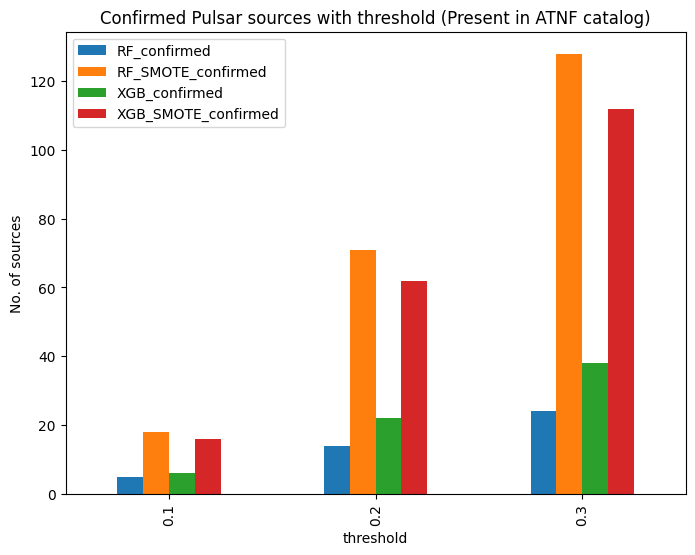

In [ ]:
confirmed_sources.plot(kind='bar', figsize=(8,6))
plt.ylabel('No. of sources')
plt.title('Confirmed Pulsar sources with threshold (Present in ATNF catalog)')
plt.show()

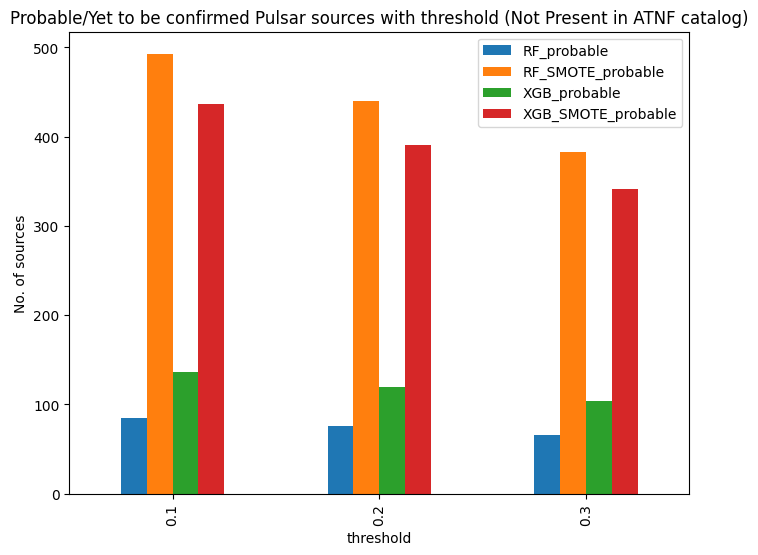

In [ ]:
probable_sources.plot(kind='bar', figsize=(8,6))
plt.ylabel('No. of sources')
plt.title('Probable/Yet to be confirmed Pulsar sources with threshold (Not Present in ATNF catalog)')
plt.show()